# AI-Driven Bayesian Template for Hubbard's AIE in engineering decisions under uncertainty
### 2026/2027 Symposium Tutorial — Kirtis Christensen

## Open in Google Colab

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/KirtisChristensen/AIE---Bayesian-Template-Tutorial/blob/main/Publish/SE-ATN-2026/llm_bayesian_reliability_tool_symposium-tutorial-2026.ipynb)

**Using Hubbard's Applied Information Economics (AIE) + Large Language Models**

---

## How to Use This Notebook

Run cells **top to bottom**. Each section corresponds to one AIE step.  
At each `## YOUR TURN` block, substitute your own problem description or data.

**What you will produce by the end:**
- A structured JSON decomposition of your reliability problem
- Value of Information (VoI) ranking of your measurements
- A calibrated Bayesian model with prior → likelihood → posterior
- A Monte Carlo simulation and decision recommendation

---

---
## Section 1 — Environment Setup

Run this cell once to install required packages.

### Option 1 — Google Colab (Recommended for Workshop)

**Do these steps before running any cells:**

1. **Open this notebook in Colab** — use the facilitator’s link, or upload via *File → Upload notebook* at colab.research.google.com
2. **Add your API key as a Colab Secret:**
   - Click the **key icon** in the left sidebar → *Secrets* tab → *Add new secret*
   - Name: `OPENAI_API_KEY` | Value: your key (starts with `sk-`)
   - Toggle **Notebook access** ON
3. **Runtime → Run all** — packages install automatically (~2–3 min), then the notebook runs end to end

> No OpenAI key? The facilitator may provide a temporary workshop key — add it the same way.  
> No internet? Uncomment `Section4_Step2_Use_Offline_Fallback()` to run without any API key.

### Option 2 — Local Install

See `QUICKSTART.md` for conda / pip options, or run `install_before_tutorial.ps1` (Windows).

In [12]:
# ── SECTION 1 — ONE-CLICK SETUP ──────────────────────────────────────────────
# Runs all Section 1 setup cells automatically so you can proceed manually
# through Sections 2–10 at your own pace.
#
# HOW TO USE:
#   • Colab  : Click the button — cells execute via the notebook API.
#   • VS Code: Click the button — setup runs by reading this .ipynb file.
#   • Fallback: Right-click the "Section 2" markdown cell below → "Run All Cells Above".
#
# The API check cell is intentionally SKIPPED here (it requires a live key).
# Run it manually in Section 1 when you are ready to test your LLM connection.
# ─────────────────────────────────────────────────────────────────────────────
import ipywidgets as _sw
from IPython.display import display as _sd, clear_output as _sclr

_setup_btn = _sw.Button(
    description='▶  Run All Section 1 Setup',
    button_style='primary',
    icon='play',
    layout=_sw.Layout(width='270px', height='42px'),
)
_setup_out = _sw.Output()

# First-line markers that identify each setup cell to execute.
# The API-check call cell ("# Options checks") is deliberately omitted.
_SETUP_MARKERS = [
    '# Install required packages',
    '# Core imports',
    '# -- LLM CONFIGURATION',
    '#REUSABLE DATA STRUCTURES AND FUNCTIONS GO HERE',
    '#WORKFLOW CODE FOR EACH SECTION GOES HERE',
]

def _on_setup_click(_b):
    _b.disabled = True
    _b.description = '⏳  Running setup...'
    _b.button_style = 'warning'
    with _setup_out:
        _sclr()
        from IPython import get_ipython as _gip
        _ip = _gip()

        # ── Path 1: Google Colab — use Javascript to execute cells above ──────
        try:
            from IPython.display import Javascript as _JS
            _sd(_JS(
                'var cs=Jupyter.notebook.get_cells();'
                'for(var i=0;i<cs.length;i++){'
                '  var t=cs[i].get_text();'
                '  if(t.indexOf("Section 2")>-1&&t.indexOf("Background")>-1) break;'
                '  if(t.indexOf("# Options checks")===0) continue;'   # skip API check
                '  cs[i].execute();'
                '}'
            ))
            print('✓ Setup dispatched via Colab notebook API.')
            print('  Cells are executing above — wait for outputs, then scroll to Section 2.')
            _b.description = '✓  Setup dispatched (Colab)'
            _b.button_style = 'success'
            return
        except Exception:
            pass  # Not Colab — fall through

        # ── Path 2: VS Code / local Jupyter — parse .ipynb, run_cell each ─────
        import json as _j, os as _o

        # Locate the notebook file; VS Code stores it in __main__.__vsc_ipynb_file__
        _nb_file = None
        try:
            import __main__ as _m
            _nb_file = getattr(_m, '__vsc_ipynb_file__', None)
        except Exception:
            pass

        if not _nb_file:
            # Search the working directory for .ipynb files as fallback
            for _f in sorted(_o.listdir('.')):
                if _f.endswith('.ipynb'):
                    _nb_file = _f
                    break

        if not _nb_file:
            print('⚠  Cannot auto-locate the notebook file.')
            print('   Use VS Code: right-click the Section 2 header cell →')
            print('   "Run All Cells Above" to complete setup manually.')
            _b.description = '⚠  Use "Run All Cells Above"'
            _b.button_style = 'warning'
            _b.disabled = False
            return

        print(f'Notebook: {_o.path.basename(_nb_file)}')
        with open(_nb_file, encoding='utf-8') as _fh:
            _nb_data = _j.load(_fh)

        _n = 0
        for _cell in _nb_data.get('cells', []):
            if _cell.get('cell_type') != 'code':
                continue
            _src = ''.join(_cell.get('source', []))
            if any(_src.strip().startswith(_mk) for _mk in _SETUP_MARKERS):
                _label = _src.splitlines()[0][:60].strip()
                print(f'  [{_n + 1}] {_label}...')
                _ip.run_cell(_src)
                _n += 1

        if _n > 0:
            print(f'\n✓ All setup complete — {_n} cells executed.')
            _b.description = f'✓  Setup complete ({_n} cells)'
            _b.button_style = 'success'
        else:
            print('⚠  No matching setup cells found in the notebook file.')
            print('   Marker strings may not match. Run setup cells manually.')
            _b.description = '⚠  No cells matched'
            _b.button_style = 'warning'
            _b.disabled = False

_setup_btn.on_click(_on_setup_click)
_sd(_sw.VBox([_setup_btn, _setup_out]))


In [13]:
# Install required packages (safe to re-run)
# Uses uv when available (required for uv-managed .venv); falls back to pip (Colab etc.)
import subprocess, sys, shutil, os, importlib.util

packages = [
    "numpy", "scipy", "pandas", "matplotlib", "seaborn",
    "networkx",       # DAG visualization
    "openai",         # LLM API (OpenAI-compatible; swap for any provider)
    "pymc",           # Bayesian inference
    "arviz",          # Posterior diagnostics
    "ipywidgets",     # Interactive sliders
]

# Only install packages that are actually missing
missing = [pkg for pkg in packages if importlib.util.find_spec(pkg) is None]
if missing:
    print(f'Installing missing packages: {missing}')
    uv_candidates = [
        shutil.which('uv'),
        os.path.join(os.path.expanduser('~'), '.local', 'bin', 'uv.exe'),
        os.path.join(os.path.expanduser('~'), '.local', 'bin', 'uv'),
    ]
    uv_exe = next((p for p in uv_candidates if p and os.path.isfile(p)), None)
    if uv_exe:
        subprocess.check_call([uv_exe, 'pip', 'install', '--python', sys.executable] + missing)
    else:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install'] + missing)
else:
    print('All packages already installed — skipping.')

print('All packages ready.')

All packages already installed — skipping.
All packages ready.


In [14]:
# Core imports
import os, json, textwrap
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import pymc as pm
import arviz as az
import ipywidgets as widgets
from IPython.display import display, Markdown, JSON

# Plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

print(f"PyMC version: {pm.__version__}")
print(f"ArviZ version: {az.__version__}")
print("Environment ready.")

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
c:\Users\Admin\Documents\AIE - Bayesian Template Generated from Problem Description\.venv\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


PyMC version: 5.28.5
ArviZ version: 0.23.4
Environment ready.


### Configure Your Runtime LLM Options

This tutorial supports two provider paths:
- OpenAI cloud using `OPENAI_API_KEY` (or facilitator-provided `WORKSHOP_OPENAI_API_KEY`)
- Ollama local endpoint at `OLLAMA_BASE_URL` (no cloud API key required)

Run order in this section:
1. Configure provider and client.
2. Optionally run API connection check.
3. Run runtime preflight diagnosis before parser call.

In [15]:
# -- LLM CONFIGURATION ---------------------------------------------------------
# This notebook uses an OpenAI-compatible provider API endpoint.
# Supported here: OpenAI cloud and Ollama local endpoint.

# -- COLAB SECRETS (Google Colab only) ----------------------------------------
# If running on Colab: click the key icon in the left sidebar -> Secrets tab,
# add OPENAI_API_KEY (and optionally WORKSHOP_OPENAI_API_KEY), toggle Notebook
# access ON. This block loads them into os.environ automatically.
# Silently skipped when running locally (ImportError on google.colab).
try:
    from google.colab import userdata as _colab_ud
    # Catch errors per-key so one missing/inaccessible secret does not abort
    # the rest. Common cause of silent failure: Notebook access toggle is OFF
    # for that specific secret in this notebook.
    _colab_loaded = []
    _colab_skipped = []
    for _k in ("OPENAI_API_KEY", "WORKSHOP_OPENAI_API_KEY", "LLM_PROVIDER", "LLM_MODEL"):
        try:
            _v = _colab_ud.get(_k)
            if _v:
                os.environ[_k] = _v
                _colab_loaded.append(_k)
        except Exception:
            _colab_skipped.append(_k)  # Secret absent or Notebook access OFF
    if _colab_loaded:
        print(f"Colab Secrets loaded into os.environ: {_colab_loaded}")
    if _colab_skipped:
        print(f"Colab Secrets not found / access OFF (skipped): {_colab_skipped}")
    if not _colab_loaded and not _colab_skipped:
        print("Colab Secrets: no keys processed.")
except ImportError:
    pass  # Not running on Colab — os.environ or direct assignment used below.


from openai import OpenAI

PROVIDER = os.environ.get("LLM_PROVIDER", "openai").lower()  # "openai" or "ollama"

openai_personal_key = os.environ.get("OPENAI_API_KEY", "").strip()
workshop_key = os.environ.get("WORKSHOP_OPENAI_API_KEY", "").strip()

if PROVIDER == "openai":
    API_KEY = openai_personal_key or workshop_key or "YOUR_KEY_HERE"
    BASE_URL = "https://api.openai.com/v1"
    MODEL = os.environ.get("LLM_MODEL", "gpt-4o-mini")
    if openai_personal_key:
        key_source = "OPENAI_API_KEY"
    elif workshop_key:
        key_source = "WORKSHOP_OPENAI_API_KEY"
    else:
        key_source = "placeholder — set OPENAI_API_KEY in Colab Secrets"
elif PROVIDER == "ollama":
    API_KEY = os.environ.get("OLLAMA_API_KEY", "ollama")
    BASE_URL = os.environ.get("OLLAMA_BASE_URL", "http://localhost:11434/v1")
    MODEL = os.environ.get("LLM_MODEL", "llama3.1")
    key_source = "local (no cloud key required)"
else:
    raise ValueError("Unsupported PROVIDER. Use 'openai' or 'ollama'.")

# -- DIRECT-KEY OVERRIDE (optional quick demo path) -----------------------------
# API_KEY = "sk-PASTE-YOUR-OPENAI-KEY-HERE"

client = OpenAI(api_key=API_KEY, base_url=BASE_URL)

print(f"Provider : {PROVIDER}")
print(f"Model    : {MODEL} @ {BASE_URL}")
print(f"Key src  : {key_source}")
print(f"API_KEY  : length={len(API_KEY)}, starts with {API_KEY[:4]!r}")

def _optional_api_connection_check() -> None:
    # -- OPTIONAL API CONNECTION CHECK ------------------------------------------
    # Run this cell to verify provider connectivity before the parser call.
    # Raises ValueError if the key is still a placeholder so the problem is
    # caught here rather than inside the LLM parser further downstream.

    print(f"Provider: {PROVIDER}  |  Model: {MODEL}")
    print(f"Key length: {len(API_KEY)}  |  starts with: {API_KEY[:4]!r}")

    if PROVIDER == "openai":
        if (not API_KEY) or API_KEY.strip() in ("", "YOUR_KEY_HERE") or API_KEY.strip().startswith("YOUR_"):
            raise ValueError(
                "OpenAI key is still a placeholder.\n"
                "Fix: re-run the config cell above after confirming your Colab Secret "
                "OPENAI_API_KEY has Notebook access toggled ON.\n"
                "The config cell output will show 'Colab Secrets loaded: [OPENAI_API_KEY]' "
                "when the secret is accessible."
            )

    if PROVIDER == "ollama":
        print("Ollama path selected: make sure Ollama is running and model is pulled locally.")
        print("Example: ollama pull llama3.1")

    try:
        test_response = client.chat.completions.create(
            model=MODEL,
            messages=[{"role": "user", "content": "Reply with exactly: API connection ok"}],
            temperature=0,
            max_tokens=10,
        )
        print(test_response.choices[0].message.content)
        print(f"API check passed for provider={PROVIDER}, model={MODEL}.")
    except Exception as error:
        print(f"API check failed for provider={PROVIDER}, model={MODEL}: {type(error).__name__}: {error}")
        raise

def _optional_runtime_preflight_check() -> None:
    # -- RUNTIME PREFLIGHT CHECK ------------------------------------------------
    # Diagnose which execution paths are available before the parser call.

    runtime_modes = []

    openai_key = os.environ.get("OPENAI_API_KEY", "").strip()
    workshop_key = os.environ.get("WORKSHOP_OPENAI_API_KEY", "").strip()
    ollama_base_url = os.environ.get("OLLAMA_BASE_URL", "http://localhost:11434/v1")

    has_personal_key = bool(openai_key) and (not openai_key.startswith("YOUR"))
    has_workshop_key = bool(workshop_key) and (not workshop_key.startswith("YOUR"))
    ollama_selected = PROVIDER == "ollama"

    if has_personal_key:
        runtime_modes.append("✓ OpenAI (personal API key detected)")
    else:
        runtime_modes.append("✗ OpenAI personal key not detected")

    if has_workshop_key:
        runtime_modes.append("✓ Workshop temporary key detected")
    else:
        runtime_modes.append("✗ Workshop temporary key not detected")

    if ollama_selected:
        runtime_modes.append(f"✓ Ollama local mode selected ({ollama_base_url})")
    else:
        runtime_modes.append("- Ollama local mode not selected")

    runtime_modes.append("✓ Offline fallback (OFFLINE_JSON always available)")

    if (PROVIDER == "openai" and (has_personal_key or has_workshop_key)) or ollama_selected:
        print("Status: LLM parser is ready to run.")
    else:
        print("Status: No live provider credential detected. Use OFFLINE_JSON fallback.")

    print()

    display(Markdown("## Runtime Preflight Diagnosis"))

    for mode in runtime_modes:
        display(Markdown(f"- {mode}"))


Provider : openai
Model    : gpt-4o-mini @ https://api.openai.com/v1
Key src  : OPENAI_API_KEY
API_KEY  : length=164, starts with 'sk-p'


In [16]:
# Options checks
_optional_api_connection_check()
_optional_runtime_preflight_check()

Provider: openai  |  Model: gpt-4o-mini
Key length: 164  |  starts with: 'sk-p'
API connection ok
API check passed for provider=openai, model=gpt-4o-mini.
Status: LLM parser is ready to run.



## Runtime Preflight Diagnosis

- ✓ OpenAI (personal API key detected)

- ✗ Workshop temporary key not detected

- - Ollama local mode not selected

- ✓ Offline fallback (OFFLINE_JSON always available)

### Define Reusable data structures and functions

In [17]:
#REUSABLE DATA STRUCTURES AND FUNCTIONS GO HERE

# ── CANONICAL BAYESIAN MODEL JSON SCHEMA ──────────────────────────────────────
# Increment A Deliverable #1: Define the contract for all model JSON.
# All LLM-generated and offline fallback JSON must validate against this schema.

CANONICAL_MODEL_SCHEMA = {
    'required_top_level_keys': [
        'schema_version', 'profile', 'problem_summary', 'decision', 'measurement_nodes',
        'bayesian_update_chain', 'voi_candidates', 'model_notes'
    ],
    # Legacy flat required list for distribution_family-style nodes. Kept for
    # backward compatibility with repair_model_json and any callers that read
    # this key directly. The validator now routes via the split lists below
    # based on each node's `elicitation_method`.
    'measurement_node_required_fields': [
        'name', 'description', 'role', 'distribution_family',
        'distribution_parameters', 'justification', 'data_source', 'depends_on'
    ],
    # Common fields required for every measurement node regardless of method.
    'measurement_node_common_required_fields': [
        'name', 'description', 'role', 'justification', 'data_source', 'depends_on'
    ],
    # Additional fields required when elicitation_method == 'distribution_family'
    # (the default when the key is absent — preserves existing behaviour).
    'measurement_node_distribution_family_required_fields': [
        'distribution_family', 'distribution_parameters'
    ],
    # Additional fields required when elicitation_method == 'bin_probabilities'
    # (Idea 1 SepState-style calibrated elicitation).
    'measurement_node_bin_probabilities_required_fields': [
        'bin_edges_months', 'bin_probs'
    ],
    # Recognized elicitation methods; absent -> 'distribution_family'.
    'valid_elicitation_methods': ['distribution_family', 'bin_probabilities'],
    'valid_roles': [
        'prior', 'likelihood', 'posterior', 'decision_variable', 'cost_node',
        'observed_data',  # LLMs sometimes use this for observed evidence nodes
    ],
    'valid_distribution_families': [
        'Normal', 'Gamma', 'Beta', 'Poisson', 'Exponential',
        'Weibull', 'Lognormal', 'Uniform', 'HalfNormal', 'Binomial',
        'Constant',           # fixed/observed value node
        'TruncatedNormal', 'StudentT', 'Cauchy', 'LogNormal',
        'NegativeBinomial', 'BetaBinomial', 'ZeroInflatedPoisson',
        # Discrete / multi-outcome families used by decision variables and
        # categorical priors. The dynamic builder still only auto-builds the
        # Gamma-Poisson family; these validate so the LLM output is accepted
        # and downstream cells either consume them or fall back as today.
        'Categorical', 'Bernoulli', 'DiscreteUniform', 'Multinomial',
        'Dirichlet', 'MvNormal',
        'derived_from_simulation'
    ],
    'valid_data_sources': [
        'expert_estimate', 'observed_data', 'derived',
        # Enriched sources emitted by the reliability-analyst prompt so the LLM
        # can distinguish text-literal facts from benchmarks and assumptions.
        'text_literal', 'industry_benchmark', 'assumed_default',
    ],
    # Optional top-level keys the reliability-analyst prompt returns to surface
    # assumptions, benchmarks, and SME questions. Absence does not fail validation.
    'optional_top_level_keys': [
        'missing_or_assumed_measures',
        'industry_benchmarks_cited',
        'sme_questions',
    ],
    'valid_profiles': ['reliability']
}

print('✓ Canonical schema frozen and loaded.')

# -- DECISION FRAME --------------------------------------------------------------
# Baseline configuration and reusable scenario library for Section 3.
# Downstream sections continue to read `decision_frame`.
#
# `pm_cycle_months` is the cadence of the *strategic* (planned-intervention)
# decision option in decision_options[0]. It drives the per-cycle exposure
# window in build_default_offline_json and in Section5_Step3_Compute_VoI.
#
# `pm_effectiveness_90ci` is the SME's 90% CI on the fraction of failures that
# PM prevents. The VoI and Monte Carlo sections fit a Beta prior from this CI
# and sample η jointly with λ, creating a meaningful EVPI crossover point.

SCENARIO_LIBRARY = {
    "Pump - Preventive vs Reactive": {
        "problem_description": """
            A centrifugal pump at a water treatment facility has experienced 3 failures
            in 24 months of operation. Each unplanned failure costs $18,000 in repairs
            and lost production. A preventive maintenance (PM) intervention costs $2,200.
            Historical industry data suggests mean time between failures (MTBF) for this
            pump class is 9-14 months under similar conditions, but our data is limited.
            We want to decide whether to implement a 6-month PM schedule or continue
            run-to-failure maintenance for the next 12 months.
        """,
        "decision_options": [
            "Implement 6-month preventive maintenance schedule",
            "Continue run-to-failure (reactive maintenance only)",
        ],
        "objective": "Minimize expected total maintenance cost over 12 months",
        "time_horizon_months": 12,
        "cost_pm_per_intervention_usd": 2200,
        "cost_unplanned_failure_usd": 18000,
        "observed_failures": 3,
        "observation_period_months": 24,
        "industry_mtbf_range_months": [9, 14],
        "pm_cycle_months": 6,
        "pm_effectiveness_90ci": [0.30, 0.70],   # SME 90% CI: PM prevents 30–70% of failures
    },
    "Conveyor - Predictive vs Scheduled": {
        "problem_description": """
            A conveyor gearbox has failed 5 times in the last 18 months. Each unplanned
            failure costs $28,000 in downtime and repairs. A scheduled intervention costs
            $4,500. We need to decide whether to run quarterly predictive maintenance or
            keep a fixed 6-month schedule for the next 12 months.
        """,
        "decision_options": [
            "Quarterly predictive maintenance",
            "Fixed 6-month scheduled maintenance",
        ],
        "objective": "Minimize expected total maintenance cost over 12 months",
        "time_horizon_months": 12,
        "cost_pm_per_intervention_usd": 4500,
        "cost_unplanned_failure_usd": 28000,
        "observed_failures": 5,
        "observation_period_months": 18,
        "industry_mtbf_range_months": [5, 10],
        "pm_cycle_months": 3,
        "pm_effectiveness_90ci": [0.40, 0.80],   # SME 90% CI: predictive PM prevents 40–80%
    },
    "Safety Valve - Inspection Interval": {
        "problem_description": """
            A safety valve has had 0 failures in 36 months. An inspection costs $1,200,
            while a failure event is estimated at $150,000. Decide whether to keep annual
            inspection or move to 18-month inspection over a 36-month horizon.
        """,
        "decision_options": [
            "Annual inspection",
            "18-month inspection",
        ],
        "objective": "Minimize expected total risk-adjusted maintenance cost",
        "time_horizon_months": 36,
        "cost_pm_per_intervention_usd": 1200,
        "cost_unplanned_failure_usd": 150000,
        "observed_failures": 0,
        "observation_period_months": 36,
        "industry_mtbf_range_months": [18, 60],
        "pm_cycle_months": 12,
        "pm_effectiveness_90ci": [0.50, 0.90],   # SME 90% CI: inspections prevent 50–90%
    },
    "Gas Turbine - Wear-Out with Borescope Finding": {
        # Rich scenario used by the Step 4 checkpoint for bin-based LLM
        # elicitation. Contains explicit wear-out signals (TBC spallation,
        # LCF welds, cyclic derate) so the LLM's bin allocations can be
        # meaningfully compared against a flat parroting baseline.
        "problem_description": """
            A Frame 7EA gas turbine on peaking service has accumulated 62,000 fired
            hours and 3,850 starts over 11 years. Historical industry MTBF for this
            class of hot-section unscheduled trips is 9-14 months, but this unit has
            been running under cyclic derate for the last 18 months to accommodate
            grid ramping duty, with roughly 40% more thermal cycles per month than
            its original duty profile. In 24 months of local records we observed 3
            unscheduled failures, all hot-section related: 1 stage-1 nozzle crack,
            1 combustor liner distress, 1 transition piece thermal fatigue. A
            borescope inspection completed six weeks ago found early-stage TBC
            (thermal barrier coating) spallation on multiple stage-1 nozzles and
            low-cycle-fatigue indications on the transition piece welds - findings
            the OEM classifies as end-of-life warning signals. Each unplanned trip
            costs $185,000 in dispatch penalties, forced-outage premium, and
            expedited parts. A planned hot-gas-path inspection with selective nozzle
            replacement costs $42,000. We must decide whether to implement a
            4-month planned inspection cycle or continue current run-to-borescope-
            signal practice for the next 12 months.
        """,
        "decision_options": [
            "Implement 4-month planned hot-gas-path inspection cycle",
            "Continue run-to-borescope-signal (reactive) practice",
        ],
        "objective": "Minimize expected total maintenance cost over 12 months",
        "time_horizon_months": 12,
        "cost_pm_per_intervention_usd": 42000,
        "cost_unplanned_failure_usd": 185000,
        "observed_failures": 3,
        "observation_period_months": 24,
        "industry_mtbf_range_months": [9, 14],
        "pm_cycle_months": 4,
        "pm_effectiveness_90ci": [0.45, 0.80],   # SME 90% CI: hot-gas-path PM prevents 45-80%
    },
}

# Single source of scenario truth used by all downstream sections.
SCENARIO_CONFIG = dict(SCENARIO_LIBRARY["Pump - Preventive vs Reactive"])

# Safe default for non-widget environments.
decision_frame = dict(SCENARIO_CONFIG)

print("Scenario library loaded.")
print(f"Default scenario: Pump - Preventive vs Reactive")
print("Run the next cell to configure parameters interactively.")

# ── SYSTEM PROMPT — Bayesian Model Engineer ────────────────────────────────────
SYSTEM_PROMPT = """
You are an expert Bayesian reliability engineer and statistician.
Given a natural-language reliability problem description, you must:

1. Identify all uncertain quantities (measurement nodes).
2. For each node, specify:
   - name: short identifier (snake_case)
   - description: plain-English explanation of what it represents
   - role: one of ["prior", "likelihood", "posterior", "decision_variable", "cost_node"]
   - distribution_family: e.g. Gamma, Weibull, Beta, Normal, Poisson, Exponential
   - distribution_parameters: dict of parameter names and initial values or ranges
   - justification: WHY this distribution family is correct for this node
   - data_source: "expert_estimate", "observed_data", or "derived"
   - depends_on: list of node names this node depends on (empty list if root node)
3. Identify the key Bayesian update chain as an ordered list of node names.
4. Acting ALSO as an expert Reliability Engineer: based on the asset type
   and failure modes implied by the description, list any measures or
   information that are MISSING but would materially improve this Bayesian
   model (e.g. operating hours, duty cycle, inspection intervals,
   environmental stressors, condition-monitoring signals, wear-out
   indicators, censored survivors). Emit them under the top-level
   `missing_or_assumed_measures` key. For each entry provide:
     - name: short identifier (snake_case)
     - why_needed: one sentence tying it to the Bayesian model
     - suggested_range: [lo, hi] plausible starting values, or null if unclear
     - unit: e.g. "months", "degC", "cycles/month", "fraction"
     - priority: one of "high", "medium", "low"
   Do NOT re-list measures the description already provides. Return an
   empty list if nothing material is missing.
5. Return ONLY valid JSON. No markdown fences, no explanation outside the JSON.

JSON schema:
{
    "schema_version": "string (e.g., 1.0)",
    "profile": "reliability",
  "problem_summary": "string",
  "decision": "string",
  "measurement_nodes": [ { ...node fields... } ],
  "bayesian_update_chain": ["node_name", ...],
  "voi_candidates": ["node_name", ...],
  "model_notes": "string",
  "missing_or_assumed_measures": [
    {"name": "<snake_case>", "why_needed": "<one sentence>",
     "suggested_range": [<lo>, <hi>], "unit": "<...>",
     "priority": "high|medium|low"}
  ]
}
"""

def parse_problem_to_json(problem_text: str) -> dict:
    """Send problem description to LLM and return structured Bayesian JSON."""
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": problem_text}
        ],
        temperature=0.1,   # Low temperature for deterministic structured output
        response_format={"type": "json_object"},
    )
    model_json = json.loads(response.choices[0].message.content)
    # Backward-compatible normalization for older prompts/responses.
    model_json.setdefault("schema_version", "1.0")
    model_json.setdefault("profile", "reliability")
    return model_json

print("LLM parser function defined.")

# ── SYSTEM PROMPT — Bin-Based Elicitation (Idea 1 SepState-style) ────────────
# Ask the LLM to allocate probability mass across an ordered set of MTBF bins
# and justify each allocation. This is the binned-quantile analogue of
# Hubbard's 5-point calibrated elicitation — the LLM acts as a synthetic
# calibrated expert rather than a distribution-family echo. Called by
# parse_problem_to_bins(); output fed into fit_gamma_to_bin_probabilities().

SYSTEM_PROMPT_BINS = """
You are an expert Bayesian reliability engineer acting as a synthetic
calibrated expert. You will be given a natural-language reliability problem
description and a set of ordered MTBF (mean-time-between-failure) bins in
months.

Your task: allocate a probability to each bin representing your belief that
the true underlying MTBF for the asset described falls in that bin. For each
bin, provide a brief one-sentence justification tied to specific evidence in
the problem description (failure regime, wear-out signals, observed data,
industry benchmarks, environmental factors, age, duty cycle, etc.).

Return ONLY valid JSON with this exact structure — no markdown fences, no
extra keys, no commentary outside the JSON:
{
  "reasoning_per_bin": [
    {"bin_index": 0, "bin_range_mo": "<lo>-<hi>", "probability": <p>, "why": "<one sentence>"},
    ...
  ],
  "notes": "<optional overall commentary on your calibration approach>"
}

Rules:
- Emit exactly one entry per bin, in ascending MTBF order (bin_index 0 = shortest MTBF bin).
- Probabilities must be non-negative floats and should sum to approximately 1.0.
- The caller will normalize any residual drift, so a slight offset is fine.
- If evidence is thin, spread mass sensibly rather than committing to a narrow band.
- Do NOT include any text outside the JSON object.
""".strip()


def _build_elicited_model_json(problem_text: str,
                               mtbf_bin_edges_months,
                               bin_probs,
                               bin_reasoning=None,
                               cfg: dict = None,
                               llm_notes: str = '') -> dict:
    """Build a schema-valid model_json with an elicited bin_probabilities prior.

    Grafts the elicited bin node into the procedural offline template so all
    downstream nodes (likelihood, posterior, cost) are present and consistent,
    and updates the posterior_failure_rate Gamma parameters using the
    conjugate update from the fitted elicited prior.

    LLM-independent; parse_problem_to_bins() wraps it after the LLM call.
    Kept separate so the offline path (and unit tests) can exercise the
    same assembly logic without an API call.
    """
    if cfg is None:
        cfg = decision_frame

    import copy as _copy

    edges = [float(e) for e in mtbf_bin_edges_months]
    probs = [float(p) for p in bin_probs]
    if bin_reasoning is None:
        bin_reasoning = [''] * len(probs)

    # Fit Gamma(alpha, beta=rate) on lambda from the elicited bin mass.
    alpha_prior, beta_prior = fit_gamma_to_bin_probabilities(edges, probs)

    # Build a fresh template so downstream nodes match the current scenario.
    model_json = _copy.deepcopy(build_default_offline_json(cfg))

    # Conjugate Gamma-Poisson posterior using the fitted elicited prior.
    obs_failures = int(cfg['observed_failures'])
    obs_months = int(cfg['observation_period_months'])
    alpha_post = alpha_prior + obs_failures
    beta_post = beta_prior + obs_months

    # Replace the family-style prior node with the elicited bin_probabilities node.
    prior_replaced = False
    for i, node in enumerate(model_json['measurement_nodes']):
        if node.get('name') == 'failure_rate_lambda' and node.get('role') == 'prior':
            model_json['measurement_nodes'][i] = {
                'name': 'failure_rate_lambda',
                'description': (
                    'LLM-elicited prior on failure rate lambda via '
                    'binned-quantile probability mass over MTBF bins.'
                ),
                'role': 'prior',
                'elicitation_method': 'bin_probabilities',
                'bin_edges_months': edges,
                'bin_probs': probs,
                'bin_reasoning': bin_reasoning,   # audit trail; not schema-required
                'justification': (
                    f'Elicited via SepState-style prompting: LLM allocated probability '
                    f'mass across MTBF bins based on problem context. '
                    f'KL-min fit yields Gamma(alpha={alpha_prior:.2f}, '
                    f'beta={beta_prior:.2f}) on lambda.'
                ),
                'data_source': 'expert_estimate',   # LLM as synthetic calibrated expert
                'depends_on': [],
            }
            prior_replaced = True
            break
    if not prior_replaced:
        raise ValueError(
            "Could not find a 'failure_rate_lambda' prior node in the offline template."
        )

    # Overwrite the posterior_failure_rate parameters to reflect the elicited prior.
    for node in model_json['measurement_nodes']:
        if node.get('name') == 'posterior_failure_rate' and node.get('role') == 'posterior':
            node['distribution_parameters'] = {
                'alpha': round(alpha_post, 4),
                'beta': round(beta_post, 4),
            }
            node['justification'] = (
                f'Gamma-Poisson conjugacy applied to elicited prior: '
                f'Gamma({alpha_prior:.2f}+{obs_failures}, {beta_prior:.2f}+{obs_months}).'
            )
            break

    # Attach optional LLM overall notes as a suffix to model_notes for audit.
    if llm_notes:
        existing = model_json.get('model_notes', '')
        model_json['model_notes'] = (
            existing + f' | LLM elicitation notes: {llm_notes}'
        ).strip()

    return model_json


def parse_problem_to_bins(problem_text: str,
                          mtbf_bin_edges_months,
                          cfg: dict = None) -> dict:
    """LLM-elicit an MTBF bin probability distribution via SepState-style prompting.

    Sends the problem description + bin edges to the LLM, parses the elicited
    per-bin probabilities and reasoning, then delegates assembly of a
    schema-valid model_json (with the bin_probabilities prior node grafted
    into a procedural template) to _build_elicited_model_json().

    cfg: decision_frame-shaped dict. Defaults to the module-level
    decision_frame if not provided.
    """
    edges = [float(e) for e in mtbf_bin_edges_months]
    n_bins = len(edges) - 1
    if n_bins < 2:
        raise ValueError('Need at least 2 bins (3 edges) for elicitation.')

    # Format bins for the LLM prompt.
    bin_descriptions = [
        f'  bin_index={i}: MTBF in [{edges[i]:.2f}, {edges[i+1]:.2f}) months'
        for i in range(n_bins)
    ]
    bins_text = '\n'.join(bin_descriptions)

    user_content = (
        f'Problem description:\n{problem_text.strip()}\n\n'
        f'MTBF bins (months):\n{bins_text}\n\n'
        f'Allocate a probability to each bin (bin_index 0..{n_bins - 1}) and '
        f'justify each allocation.'
    )

    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {'role': 'system', 'content': SYSTEM_PROMPT_BINS},
            {'role': 'user',   'content': user_content},
        ],
        temperature=0.1,
        response_format={'type': 'json_object'},
    )
    raw = json.loads(response.choices[0].message.content)

    reasoning = raw.get('reasoning_per_bin')
    if not isinstance(reasoning, list) or len(reasoning) != n_bins:
        got = len(reasoning) if isinstance(reasoning, list) else 'non-list'
        raise ValueError(
            f'LLM response must include reasoning_per_bin with exactly {n_bins} '
            f'entries; got {got}. Raw response: {raw!r}'
        )
    # Sort by bin_index in case the LLM reordered entries.
    try:
        reasoning = sorted(reasoning, key=lambda r: int(r.get('bin_index', 0)))
    except Exception:
        pass
    bin_probs = [float(r.get('probability', 0.0)) for r in reasoning]
    bin_reasoning = [str(r.get('why', '')) for r in reasoning]

    return _build_elicited_model_json(
        problem_text=problem_text,
        mtbf_bin_edges_months=edges,
        bin_probs=bin_probs,
        bin_reasoning=bin_reasoning,
        cfg=cfg or decision_frame,
        llm_notes=str(raw.get('notes', '')),
    )


print('✓ Bin-based LLM parser + offline builder defined.')

# ── SCHEMA VALIDATION FUNCTION ────────────────────────────────────────────────
# Increment A Deliverable #3: Validate model JSON before downstream use.
# Step 2 addition: per-node required-field routing via `elicitation_method`,
# plus structural checks for bin_probabilities nodes.

def validate_bayesian_model_json(model_json: dict) -> tuple:
    """
    Validate parsed or offline JSON against canonical schema.
    Returns (is_valid: bool, errors: list[str])

    Per-node required-field checks route on `elicitation_method`
    (default `'distribution_family'` when the key is absent). For nodes
    with `elicitation_method == 'bin_probabilities'` the validator also
    checks the bin structure: edges strictly ascending and positive; probs
    non-negative and length == len(edges) - 1.
    """
    errors = []
    
    # Check top-level keys
    for key in CANONICAL_MODEL_SCHEMA['required_top_level_keys']:
        if key not in model_json:
            errors.append(f'Missing required key: {key}')

    # Check schema metadata
    if 'schema_version' in model_json and not isinstance(model_json['schema_version'], str):
        errors.append('schema_version must be a string, e.g., "1.0"')
    if 'profile' in model_json:
        if model_json['profile'] not in CANONICAL_MODEL_SCHEMA['valid_profiles']:
            errors.append(f'Invalid profile: {model_json["profile"]}')
    
    # Check measurement nodes structure
    if 'measurement_nodes' in model_json:
        nodes = model_json['measurement_nodes']
        if not isinstance(nodes, list):
            errors.append('measurement_nodes must be a list')
        else:
            node_names = set()
            for i, node in enumerate(nodes):
                node_label = node.get('name', '?')

                # Determine elicitation method (default preserves legacy behaviour).
                elicitation_method = node.get('elicitation_method', 'distribution_family')
                method_valid = (
                    elicitation_method in CANONICAL_MODEL_SCHEMA['valid_elicitation_methods']
                )
                if not method_valid:
                    errors.append(
                        f'Node {i} ({node_label}): invalid elicitation_method '
                        f'"{elicitation_method}"'
                    )

                # Assemble and check required fields (skip when method is invalid
                # to avoid noisy cascade errors — the method error is enough).
                if method_valid:
                    required = list(
                        CANONICAL_MODEL_SCHEMA['measurement_node_common_required_fields']
                    )
                    if elicitation_method == 'bin_probabilities':
                        required += CANONICAL_MODEL_SCHEMA[
                            'measurement_node_bin_probabilities_required_fields'
                        ]
                    else:
                        required += CANONICAL_MODEL_SCHEMA[
                            'measurement_node_distribution_family_required_fields'
                        ]
                    for field in required:
                        if field not in node:
                            errors.append(
                                f'Node {i} ({node_label}): missing field {field}'
                            )
                
                # Check uniqueness (always)
                if 'name' in node:
                    if node['name'] in node_names:
                        errors.append(f'Duplicate node name: {node["name"]}')
                    node_names.add(node['name'])
                
                # Check role validity (always)
                if 'role' in node and node['role'] not in CANONICAL_MODEL_SCHEMA['valid_roles']:
                    errors.append(f'Node {i}: invalid role "{node["role"]}"')

                # Method-specific validity — only meaningful when method is known.
                if method_valid and elicitation_method == 'distribution_family':
                    if (
                        'distribution_family' in node
                        and node['distribution_family']
                        not in CANONICAL_MODEL_SCHEMA['valid_distribution_families']
                    ):
                        errors.append(
                            f'Node {i}: unknown distribution "{node["distribution_family"]}"'
                        )

                if method_valid and elicitation_method == 'bin_probabilities':
                    edges = node.get('bin_edges_months')
                    probs = node.get('bin_probs')
                    edges_ok = False
                    if edges is not None:
                        if not isinstance(edges, list) or len(edges) < 3:
                            errors.append(
                                f'Node {i} ({node_label}): bin_edges_months must be a '
                                f'list with >= 3 entries.'
                            )
                        elif any(
                            (not isinstance(e, (int, float))) or float(e) <= 0
                            for e in edges
                        ):
                            errors.append(
                                f'Node {i} ({node_label}): bin_edges_months must be '
                                f'all positive numbers.'
                            )
                        elif any(edges[j + 1] <= edges[j] for j in range(len(edges) - 1)):
                            errors.append(
                                f'Node {i} ({node_label}): bin_edges_months must be '
                                f'strictly ascending.'
                            )
                        else:
                            edges_ok = True
                    if probs is not None and edges_ok:
                        if not isinstance(probs, list) or len(probs) != len(edges) - 1:
                            errors.append(
                                f'Node {i} ({node_label}): bin_probs length must equal '
                                f'len(bin_edges_months)-1 = {len(edges) - 1}.'
                            )
                        elif any(
                            (not isinstance(p, (int, float))) or float(p) < 0
                            for p in probs
                        ):
                            errors.append(
                                f'Node {i} ({node_label}): bin_probs must be all '
                                f'non-negative numbers.'
                            )
    
    return (len(errors) == 0, errors)

print('✓ Schema validator function defined.')

# ── SHARED GAMMA-FROM-MTBF-CI FIT ────────────────────────────────────────────
# Used by both build_default_offline_json (procedural JSON for the offline
# fallback) and the Section 6 Path A calibrated-prior cell so the two routes
# share a single Gamma fit. Returns (alpha, beta_rate) such that the resulting
# Gamma(alpha, beta=rate) has 5th/95th percentiles bracketing the failure-rate
# 90% CI derived from the MTBF 90% CI [mtbf_low, mtbf_high].

def fit_gamma_to_mtbf_ci(mtbf_low: float, mtbf_high: float,
                         x0=(3.0, 30.0)) -> tuple:
    """Fit Gamma(alpha, beta=rate) to a MTBF 90% CI.

    Converts the MTBF range to a failure-rate range (lambda = 1 / MTBF) and
    solves for (alpha, beta) such that the Gamma's 5th and 95th percentiles
    match the lambda 90% CI endpoints.
    """
    from scipy.optimize import minimize
    lam_lo = 1.0 / float(mtbf_high)
    lam_hi = 1.0 / float(mtbf_low)

    def _loss(p):
        a, b = p
        if a <= 0 or b <= 0:
            return 1e10
        p5  = stats.gamma.ppf(0.05, a=a, scale=1.0 / b)
        p95 = stats.gamma.ppf(0.95, a=a, scale=1.0 / b)
        return (p5 - lam_lo) ** 2 + (p95 - lam_hi) ** 2

    res = minimize(_loss, x0=list(x0), method="Nelder-Mead")
    return float(res.x[0]), float(res.x[1])


# ── DATA-DERIVED GAMMA PRIOR FROM TTF OBSERVATIONS ────────────────────────────
# Section 6 Path B converts a vector of observed time-to-failure values
# (months) into a Gamma prior on the per-month failure rate lambda via the
# exponential-conjugate update from a flat prior: n TTFs with total exposure
# T = sum(t) yield Gamma(n, T), whose mean n/T = 1/mean(t) matches the MLE
# rate, and whose alpha=n correctly tightens as data accumulate. The data
# prior then competes with the SME (Path A) and the LLM-parsed JSON prior
# in the Section 7 prior-sensitivity comparison.

def fit_gamma_to_ttf_data(ttfs) -> tuple:
    """Fit a data-derived Gamma prior on lambda from observed TTFs.

    Uses the exponential-likelihood conjugate update from a flat prior:
    given n observed time-to-failures with total exposure T = sum(t), the
    data-only posterior on the per-month failure rate lambda is Gamma(n, T).
    Prior mean is n/T = 1/mean(t) (the empirical MLE rate), and alpha grows
    linearly with sample size so the Gamma correctly narrows as more data
    accumulate. Pedagogically clean for the AIE three-way prior comparison.

    Returns (alpha, beta_rate). Raises ValueError on degenerate input.
    """
    ttfs = np.asarray(list(ttfs), dtype=float)
    if ttfs.size < 1:
        raise ValueError("Need at least 1 TTF observation.")
    if np.any(ttfs <= 0):
        raise ValueError("All TTFs must be positive (months).")
    alpha = float(ttfs.size)
    beta_rate = float(ttfs.sum())
    return alpha, beta_rate


# ── BETA FIT FROM 90% CI ──────────────────────────────────────────────────────
# Fits Beta(alpha, beta) to an SME 90% CI on a bounded (0,1) quantity.
# Used to build a prior on pm_effectiveness from elicited bounds.
# pm_effectiveness = η = fraction of unplanned failures prevented by PM.
# SME elicitation question: "What fraction of expected failures does one PM
# intervention prevent?" → provide 90% CI lower and upper bounds.

def fit_beta_from_ci(ci_low: float, ci_high: float, x0=(2.0, 2.0)) -> tuple:
    """Fit Beta(alpha, beta) to a 90% CI [ci_low, ci_high] on a (0,1) quantity.

    Solves for (a, b) such that the Beta's 5th percentile matches ci_low and
    95th percentile matches ci_high. Used to build a prior on pm_effectiveness
    from SME elicitation. Falls back to Beta(1,1) = Uniform if ci is [0, 0]
    (no effectiveness information — equivalent to current model behaviour).

    Returns (alpha, beta).
    """
    from scipy.optimize import minimize
    lo = float(ci_low)
    hi = float(ci_high)
    if lo <= 0 and hi <= 0:
        return 1.0, 1.0  # Uniform prior — no effectiveness information provided
    lo = max(lo, 1e-4)
    hi = min(hi, 1.0 - 1e-4)
    if lo >= hi:
        mid = max(1e-4, min(1.0 - 1e-4, (lo + hi) / 2.0))
        return float(mid * 50), float((1.0 - mid) * 50)

    def _loss(p):
        a, b = p
        if a <= 0 or b <= 0:
            return 1e10
        p5  = stats.beta.ppf(0.05, a=a, b=b)
        p95 = stats.beta.ppf(0.95, a=a, b=b)
        return (p5 - lo) ** 2 + (p95 - hi) ** 2

    res = minimize(_loss, x0=list(x0), method='Nelder-Mead')
    return float(res.x[0]), float(res.x[1])


# ── BIN-BASED ELICITATION HELPERS (Idea 1 — SepState-style calibration) ─────
# Increment 1 groundwork for LLM binned-quantile elicitation.
#
# Two pure helpers with no LLM dependency:
#   * compute_default_mtbf_bin_edges: scenario-adaptive log-spaced MTBF bins.
#   * fit_gamma_to_bin_probabilities: KL-min fit from an MTBF bin probability
#     mass to a Gamma(alpha, beta=rate) on per-month failure rate lambda.
#
# A later increment will add an LLM caller that fills the bin probabilities;
# Section 7 will then compare this elicited prior against the family-echo and
# TTF-derived priors already produced.
#
# Design decisions locked in Step 1:
#   * 6 bins, log-spaced, adaptive to industry_mtbf_range_months.
#   * Edges span mtbf_lo/3 (very unreliable end) to mtbf_hi*3 (very reliable
#     end). Log spacing matches the roughly-lognormal spread of failure rates
#     encountered in practice.
#   * Fit method: KL-minimization via Nelder-Mead over (log_alpha, log_beta).

def compute_default_mtbf_bin_edges(mtbf_lo: float, mtbf_hi: float,
                                   n_bins: int = 6) -> list:
    """Log-spaced MTBF bin edges spanning mtbf_lo/3 to mtbf_hi*3.

    Returns n_bins+1 edges in ascending MTBF (months). Left tail bin covers
    MTBFs shorter than the industry range (higher failure rates); right tail
    bin covers MTBFs much longer (lower failure rates). Log spacing gives
    balanced resolution across plausible values.
    """
    lo = max(0.5, float(mtbf_lo) / 3.0)
    hi = max(lo * 2.0, float(mtbf_hi) * 3.0)
    edges = np.logspace(np.log10(lo), np.log10(hi), int(n_bins) + 1)
    return [float(e) for e in edges]


def fit_gamma_to_bin_probabilities(bin_edges_months, bin_probs,
                                   x0=None) -> tuple:
    """Fit Gamma(alpha, beta=rate) on lambda from an MTBF bin probability mass.

    bin_edges_months: length N+1, strictly ascending, all positive months.
        Bin i covers MTBF in [bin_edges_months[i], bin_edges_months[i+1]).
    bin_probs: length N, non-negative; will be normalized to sum to 1.

    Minimizes KL(elicited || fitted_bin_probs) using Nelder-Mead over
    (log_alpha, log_beta). Returns (alpha, beta_rate).
    """
    from scipy.optimize import minimize

    edges = np.asarray(bin_edges_months, dtype=float)
    probs = np.asarray(bin_probs, dtype=float)

    if edges.ndim != 1 or edges.size < 3:
        raise ValueError("bin_edges_months must be 1D with at least 3 entries.")
    if not np.all(np.diff(edges) > 0):
        raise ValueError("bin_edges_months must be strictly ascending.")
    if np.any(edges <= 0):
        raise ValueError("All bin_edges_months must be positive (months).")
    if probs.ndim != 1 or probs.size != edges.size - 1:
        raise ValueError(
            f"bin_probs length {probs.size} must equal "
            f"len(bin_edges_months)-1 = {edges.size - 1}."
        )
    if np.any(probs < 0):
        raise ValueError("All bin_probs must be non-negative.")
    total = float(probs.sum())
    if total <= 0:
        raise ValueError("bin_probs must have positive total mass.")
    probs = probs / total

    # MTBF edges -> lambda edges (lambda = 1 / MTBF, descending order).
    lam_edges = 1.0 / edges

    def _fitted_bin_probs(alpha: float, beta: float):
        # P(MTBF in [edges[i], edges[i+1])) == P(lambda in (lam_edges[i+1], lam_edges[i]]).
        scale = 1.0 / beta
        cdf_hi = stats.gamma.cdf(lam_edges[:-1], a=alpha, scale=scale)
        cdf_lo = stats.gamma.cdf(lam_edges[1:], a=alpha, scale=scale)
        return np.clip(cdf_hi - cdf_lo, 1e-12, None)

    def _kl_loss(log_params):
        alpha = float(np.exp(log_params[0]))
        beta = float(np.exp(log_params[1]))
        if not np.isfinite(alpha) or not np.isfinite(beta):
            return 1e10
        fitted = _fitted_bin_probs(alpha, beta)
        p = np.maximum(probs, 1e-12)
        return float(np.sum(p * np.log(p / fitted)))

    if x0 is None:
        mids = 0.5 * (edges[:-1] + edges[1:])
        mtbf_mean_est = float(np.sum(probs * mids))
        if mtbf_mean_est <= 0 or not np.isfinite(mtbf_mean_est):
            mtbf_mean_est = float(np.median(mids))
        lam_mean_est = max(1e-6, 1.0 / mtbf_mean_est)
        alpha0 = 3.0
        beta0 = alpha0 / lam_mean_est
        x0 = (np.log(alpha0), np.log(beta0))

    res = minimize(_kl_loss, x0=list(x0), method="Nelder-Mead",
                   options={"xatol": 1e-5, "fatol": 1e-8, "maxiter": 2000})
    return float(np.exp(res.x[0])), float(np.exp(res.x[1]))


print('✓ Bin-based elicitation helpers defined.')


# ── PROCEDURAL OFFLINE FALLBACK BUILDER ───────────────────────────────────────
# Builds a Gamma-Poisson reliability model JSON for ANY decision_frame-shaped
# config (any scenario in SCENARIO_LIBRARY, edits via Section 3 widgets, or a
# user-supplied my_decision_frame). Used as the offline fallback when the LLM
# is unavailable or returns invalid JSON. Output validates against
# CANONICAL_MODEL_SCHEMA and matches the scenario currently in decision_frame.

def build_default_offline_json(cfg: dict, pm_cycle_months: int = None) -> dict:
    """
    Construct a Gamma-Poisson reliability model JSON derived from `cfg`
    (a decision_frame-shaped dict). All measurement nodes, parameters, and
    cost fields are computed from cfg so the fallback always matches the
    user's currently-selected scenario.

    `pm_cycle_months` may be passed explicitly; if omitted, falls back to
    `cfg["pm_cycle_months"]` and then to a 6-month default.
    """
    horizon       = int(cfg["time_horizon_months"])
    obs_failures  = int(cfg["observed_failures"])
    obs_months    = int(cfg["observation_period_months"])
    mtbf_lo, mtbf_hi = cfg["industry_mtbf_range_months"]
    cost_pm       = cfg["cost_pm_per_intervention_usd"]
    cost_fail     = cfg["cost_unplanned_failure_usd"]
    objective     = cfg.get("objective", "Minimize expected cost over the planning horizon")
    problem_desc  = (cfg.get("problem_description") or "").strip()
    if pm_cycle_months is None:
        pm_cycle_months = int(cfg.get("pm_cycle_months", 6))

    # Fit Gamma(alpha, beta=rate) prior to the MTBF 90% CI via the shared helper.
    alpha_prior, beta_prior = fit_gamma_to_mtbf_ci(mtbf_lo, mtbf_hi)

    # Conjugate Gamma-Poisson posterior.
    alpha_post = alpha_prior + obs_failures
    beta_post  = beta_prior + obs_months

    # PM cadence and resulting planned-intervention count over the horizon.
    pm_cycle = max(1, int(pm_cycle_months))
    n_pm     = max(1, horizon // pm_cycle)

    # First non-empty line of the problem description as a short summary.
    summary_line = next(
        (line.strip() for line in problem_desc.splitlines() if line.strip()),
        "Reliability decision derived from supplied decision_frame.",
    )

    return {
        "schema_version": "1.0",
        "profile": "reliability",
        "problem_summary": summary_line,
        "decision": objective,
        "measurement_nodes": [
            {
                "name": "failure_rate_lambda",
                "description": "True underlying failure rate (events per month)",
                "role": "prior",
                "distribution_family": "Gamma",
                "distribution_parameters": {
                    "alpha": round(alpha_prior, 4),
                    "beta": round(beta_prior, 4),
                },
                "justification": (
                    f"Gamma is the conjugate prior for a Poisson failure process. "
                    f"alpha/beta fit so the 90% CI on lambda matches MTBF range "
                    f"[{mtbf_lo}, {mtbf_hi}] months."
                ),
                "data_source": "expert_estimate",
                "depends_on": [],
            },
            {
                "name": "observed_failures",
                "description": f"Observed failure count: {obs_failures} failures in {obs_months} months",
                "role": "likelihood",
                "distribution_family": "Poisson",
                "distribution_parameters": {"mu": f"failure_rate_lambda * {obs_months}"},
                "justification": "Poisson likelihood for independent count data over a fixed exposure window.",
                "data_source": "observed_data",
                "depends_on": ["failure_rate_lambda"],
            },
            {
                "name": "posterior_failure_rate",
                "description": "Updated belief about lambda after conditioning on observed failures",
                "role": "posterior",
                "distribution_family": "Gamma",
                "distribution_parameters": {
                    "alpha": round(alpha_post, 4),
                    "beta": round(beta_post, 4),
                },
                "justification": (
                    f"Gamma-Poisson conjugacy: posterior Gamma(alpha + k, beta + t) = "
                    f"Gamma({alpha_prior:.2f}+{obs_failures}, {beta_prior:.2f}+{obs_months})."
                ),
                "data_source": "derived",
                "depends_on": ["failure_rate_lambda", "observed_failures"],
            },
            {
                "name": "failures_next_window_pm",
                "description": (
                    f"Predicted failures over a {pm_cycle}-month PM cycle "
                    f"(effective exposure resets at each intervention)"
                ),
                "role": "decision_variable",
                "distribution_family": "Poisson",
                "distribution_parameters": {"mu": f"posterior_failure_rate * {pm_cycle}"},
                "justification": (
                    f"Under a {pm_cycle}-month PM cadence, effective exposure between "
                    f"interventions is {pm_cycle} months."
                ),
                "data_source": "derived",
                "depends_on": ["posterior_failure_rate"],
            },
            {
                "name": "failures_next_horizon_rtf",
                "description": (
                    f"Predicted failures over the full {horizon}-month horizon "
                    f"under run-to-failure"
                ),
                "role": "decision_variable",
                "distribution_family": "Poisson",
                "distribution_parameters": {"mu": f"posterior_failure_rate * {horizon}"},
                "justification": "Full horizon exposure with no preventive interventions.",
                "data_source": "derived",
                "depends_on": ["posterior_failure_rate"],
            },
            {
                "name": "total_cost_pm",
                "description": f"Total cost under PM: {n_pm} planned interventions + unplanned failures",
                "role": "cost_node",
                "distribution_family": "derived_from_simulation",
                "distribution_parameters": {
                    "pm_interventions": n_pm,
                    "cost_pm": cost_pm,
                    "cost_failure": cost_fail,
                },
                "justification": (
                    f"{n_pm} planned PMs x PM cost + expected unplanned failures x failure cost."
                ),
                "data_source": "derived",
                "depends_on": ["failures_next_window_pm"],
            },
            {
                "name": "total_cost_rtf",
                "description": "Total cost under run-to-failure: all costs from unplanned failures",
                "role": "cost_node",
                "distribution_family": "derived_from_simulation",
                "distribution_parameters": {"cost_failure": cost_fail},
                "justification": "No planned interventions; all maintenance cost from unplanned failures.",
                "data_source": "derived",
                "depends_on": ["failures_next_horizon_rtf"],
            },
        ],
        "bayesian_update_chain": [
            "failure_rate_lambda",
            "observed_failures",
            "posterior_failure_rate",
            "failures_next_window_pm",
            "failures_next_horizon_rtf",
            "total_cost_pm",
            "total_cost_rtf",
        ],
        "voi_candidates": ["failure_rate_lambda", "posterior_failure_rate"],
        "model_notes": (
            "Gamma-Poisson conjugate template auto-built from decision_frame. "
            "Posterior is analytical; cost nodes are evaluated by Monte Carlo in Section 9."
        ),
    }

# Seed module-level OFFLINE_JSON for the default scenario so downstream cells
# that reference OFFLINE_JSON (Increment B dynamic builder, DAG visualisation)
# always have a valid fallback available without first calling the workflow
# wrapper. Refreshed by Section4_Step2_Use_Offline_Fallback() when invoked.
OFFLINE_JSON = build_default_offline_json(SCENARIO_CONFIG)
print("✓ Offline fallback builder defined; OFFLINE_JSON seeded for default scenario.")

# ── FIELD-LEVEL REPAIR ────────────────────────────────────────────────────────
# When the LLM returns *mostly* valid JSON with a few missing or near-miss
# fields, repair_model_json patches just those fields from a procedural
# template instead of discarding the entire LLM response. Preserves all valid
# LLM content (node names, descriptions, justifications, extra nodes) and
# returns a list of repair notes so the user sees exactly what was patched.

# Common LLM near-miss values mapped to canonical schema values.
_ROLE_ALIASES = {
    'input': 'prior',
    'evidence': 'likelihood',
    'observation': 'likelihood',
    'observed': 'observed_data',
    'output': 'posterior',
    'decision': 'decision_variable',
    'cost': 'cost_node',
}

# Default fill values for required node fields when neither the LLM nor the
# template provides one (rare, but keeps the schema satisfiable).
_NODE_FIELD_DEFAULTS = {
    'description': '',
    'distribution_parameters': {},
    'justification': '',
    'data_source': 'derived',
    'depends_on': [],
}


def _normalize_family_key(name) -> str:
    """Lowercase + strip separators so 'Log-Normal' and 'lognormal' collide."""
    return str(name).strip().lower().replace('_', '').replace('-', '').replace(' ', '')


def _build_family_alias_table() -> dict:
    """Map normalized family names (including common LLM variants) to canonical."""
    table = {}
    for valid in CANONICAL_MODEL_SCHEMA['valid_distribution_families']:
        table[_normalize_family_key(valid)] = valid
    # Common LLM variants the canonical list doesn't already cover by casing.
    table.update({
        'gaussian': 'Normal',
        'norm': 'Normal',
        'expon': 'Exponential',
        'exp': 'Exponential',
        'pois': 'Poisson',
    })
    return table


_FAMILY_ALIASES = _build_family_alias_table()


# ── PARAMETER-NAME NORMALIZATION ──────────────────────────────────────────────
# Maps LLM-emitted parameter names to canonical PyMC parameter names per
# distribution family. Pure renames go in _PARAM_ALIASES; arithmetic mappings
# (e.g. Gamma scale -> 1/beta) go in _PARAM_TRANSFORMS. Run AFTER family-name
# normalization so the lookup key is canonical.

_PARAM_ALIASES = {
    'Normal': {'mean': 'mu', 'location': 'mu', 'loc': 'mu', 'mu_': 'mu',
               'std_dev': 'sigma', 'stddev': 'sigma', 'std': 'sigma',
               'sd': 'sigma', 'sigma_': 'sigma'},
    'HalfNormal': {'std_dev': 'sigma', 'stddev': 'sigma', 'std': 'sigma',
                   'sd': 'sigma'},
    'TruncatedNormal': {'mean': 'mu', 'std_dev': 'sigma', 'stddev': 'sigma',
                        'std': 'sigma', 'sd': 'sigma'},
    'LogNormal': {'mean': 'mu', 'std_dev': 'sigma', 'stddev': 'sigma',
                  'std': 'sigma', 'sd': 'sigma'},
    'Lognormal': {'mean': 'mu', 'std_dev': 'sigma', 'stddev': 'sigma',
                  'std': 'sigma', 'sd': 'sigma'},
    'StudentT': {'mean': 'mu', 'std_dev': 'sigma', 'df': 'nu', 'dof': 'nu'},
    'Cauchy': {'location': 'alpha', 'loc': 'alpha', 'scale': 'beta'},
    'Poisson': {'lambda': 'mu', 'lam': 'mu', 'rate': 'mu', 'lambda_': 'mu'},
    'Exponential': {'rate': 'lam', 'lambda': 'lam', 'lambda_': 'lam'},
    'Gamma': {'a': 'alpha', 'b': 'beta', 'rate': 'beta', 'k': 'alpha'},
    'Beta': {'a': 'alpha', 'b': 'beta'},
    'Binomial': {'trials': 'n', 'prob': 'p', 'probability': 'p'},
    'Bernoulli': {'prob': 'p', 'probability': 'p'},
    'NegativeBinomial': {'mean': 'mu', 'dispersion': 'alpha'},
    'Weibull': {'shape': 'alpha', 'k': 'alpha', 'scale': 'beta'},
    'Uniform': {'low': 'lower', 'high': 'upper', 'min': 'lower', 'max': 'upper',
                'a': 'lower', 'b': 'upper'},
    'DiscreteUniform': {'low': 'lower', 'high': 'upper', 'min': 'lower',
                        'max': 'upper'},
    'Categorical': {'probs': 'p', 'probabilities': 'p'},
    'Multinomial': {'trials': 'n', 'probs': 'p'},
    'Dirichlet': {'concentration': 'a', 'alpha': 'a'},
}


def _reciprocal(value):
    try:
        v = float(value)
        if v == 0:
            return value
        return 1.0 / v
    except (TypeError, ValueError):
        return value


# Arithmetic transforms: family -> {alias: (canonical_name, transform_fn)}.
_PARAM_TRANSFORMS = {
    'Gamma': {'scale': ('beta', _reciprocal)},
}

_DEGENERATE_SCALE_FAMILIES = {
    'Normal', 'HalfNormal', 'TruncatedNormal', 'LogNormal', 'Lognormal',
    'StudentT',
}
_SIGMA_EPSILON = 1e-6


def _repair_node_parameters(node: dict) -> list:
    """Normalize distribution_parameters to canonical PyMC parameter names.

    Order of operations:
      1. Arithmetic transforms (e.g. Gamma `scale` -> `beta = 1/scale`).
      2. Pure renames (e.g. Normal `std_dev` -> `sigma`, Poisson `lambda` -> `mu`).
      3. Degenerate-scale guard: sigma <= 0 coerced to a small positive
         epsilon so PyMC can still sample.

    Returns a list of human-readable repair notes for surfacing to the user.
    """
    notes_local = []
    family = node.get('distribution_family')
    params = node.get('distribution_parameters')
    if not isinstance(params, dict):
        return notes_local
    if family not in CANONICAL_MODEL_SCHEMA['valid_distribution_families']:
        return notes_local

    node_label = node.get('name', '<unnamed>')

    # 1. Arithmetic transforms (run before renames so `scale` is consumed
    #    before any rename could touch `beta`).
    transforms = _PARAM_TRANSFORMS.get(family, {})
    for alias, (canonical, fn) in transforms.items():
        if alias in params and canonical not in params:
            old_val = params.pop(alias)
            new_val = fn(old_val)
            params[canonical] = new_val
            notes_local.append(
                f"Node `{node_label}`: transformed {family} parameter "
                f"`{alias}={old_val}` -> `{canonical}={new_val}`."
            )

    # 2. Pure-rename aliases.
    aliases = _PARAM_ALIASES.get(family, {})
    for alias, canonical in list(aliases.items()):
        if alias in params and canonical not in params:
            params[canonical] = params.pop(alias)
            notes_local.append(
                f"Node `{node_label}`: renamed {family} parameter "
                f"`{alias}` -> `{canonical}`."
            )

    # 3. Degenerate-scale guard (sigma <= 0 breaks PyMC sampling).
    if family in _DEGENERATE_SCALE_FAMILIES and 'sigma' in params:
        try:
            sigma_val = float(params['sigma'])
            if sigma_val <= 0:
                params['sigma'] = _SIGMA_EPSILON
                notes_local.append(
                    f"Node `{node_label}`: {family} sigma was {sigma_val} "
                    f"(degenerate); coerced to {_SIGMA_EPSILON}. If this node "
                    "represents a fixed value, switch distribution_family to "
                    "'Constant' for cleaner semantics."
                )
        except (TypeError, ValueError):
            pass

    return notes_local


def normalize_model_parameters(model_json: dict) -> list:
    """Apply _repair_node_parameters across all measurement nodes.

    Safe to call on any model_json (parsed LLM, offline fallback, or already
    repaired); skips non-dict nodes and unknown families silently. Returns
    aggregated repair notes from every node touched.
    """
    notes = []
    nodes = model_json.get('measurement_nodes')
    if not isinstance(nodes, list):
        return notes
    for node in nodes:
        if isinstance(node, dict):
            notes.extend(_repair_node_parameters(node))
    return notes


def repair_model_json(llm_json: dict, template_json: dict) -> tuple:
    """
    Patch a partially-valid LLM model JSON using a procedurally-built template.

    Strategy (preserves LLM content; only fills/fixes invalid fields):
      1. Fill missing top-level keys from the template.
      2. Coerce schema_version / profile if invalid.
      3. For each measurement_node missing a required field, fill it from the
         matching template node (by name) or a sensible default.
      4. Map near-miss role values (e.g. 'input' -> 'prior') to canonical roles.
      5. Map distribution_family case/alias variants to canonical names.

    Returns (repaired_json, repair_notes). repair_notes is a list of strings
    suitable for displaying to the user so they see what the LLM got wrong.
    """
    import copy as _copy

    repaired = _copy.deepcopy(llm_json)
    notes = []

    # 1. Top-level keys
    for key in CANONICAL_MODEL_SCHEMA['required_top_level_keys']:
        if key not in repaired:
            repaired[key] = _copy.deepcopy(template_json.get(key))
            notes.append(f"Filled missing top-level key `{key}` from template.")

    # 2. Metadata coercion
    if not isinstance(repaired.get('schema_version'), str):
        repaired['schema_version'] = '1.0'
        notes.append("Coerced `schema_version` to '1.0'.")
    if repaired.get('profile') not in CANONICAL_MODEL_SCHEMA['valid_profiles']:
        old_profile = repaired.get('profile')
        repaired['profile'] = 'reliability'
        notes.append(f"Reset invalid `profile` ({old_profile!r}) to 'reliability'.")

    # 3-5. Node-level repair
    template_by_name = {
        n.get('name'): n
        for n in template_json.get('measurement_nodes', [])
        if isinstance(n, dict) and n.get('name')
    }

    nodes = repaired.get('measurement_nodes')
    if isinstance(nodes, list):
        for i, node in enumerate(nodes):
            if not isinstance(node, dict):
                continue

            node_label = node.get('name', f'<index {i}>')
            template_node = template_by_name.get(node.get('name'))

            # Fill missing required fields
            for field in CANONICAL_MODEL_SCHEMA['measurement_node_required_fields']:
                if field in node:
                    continue
                if template_node is not None and field in template_node:
                    node[field] = _copy.deepcopy(template_node[field])
                    notes.append(f"Node `{node_label}`: filled missing `{field}` from template.")
                elif field in _NODE_FIELD_DEFAULTS:
                    node[field] = _copy.deepcopy(_NODE_FIELD_DEFAULTS[field])
                    notes.append(f"Node `{node_label}`: filled missing `{field}` with default.")
                # If field has no default and no template match (e.g. 'name'),
                # leave it absent so re-validation surfaces it.

            # Role alias mapping
            role = node.get('role')
            if role and role not in CANONICAL_MODEL_SCHEMA['valid_roles']:
                mapped = _ROLE_ALIASES.get(str(role).strip().lower())
                if mapped:
                    node['role'] = mapped
                    notes.append(f"Node `{node_label}`: mapped role `{role}` -> `{mapped}`.")

            # Distribution family alias / casing fix
            family = node.get('distribution_family')
            if family and family not in CANONICAL_MODEL_SCHEMA['valid_distribution_families']:
                mapped = _FAMILY_ALIASES.get(_normalize_family_key(family))
                if mapped:
                    node['distribution_family'] = mapped
                    notes.append(
                        f"Node `{node_label}`: mapped distribution_family `{family}` -> `{mapped}`."
                    )

    return repaired, notes


print('✓ Field-level repair function defined (with parameter-name normalization).')

# ── DYNAMIC-BUILDER PRIMITIVES (Section 7 Increment B) ─────────────────────
# Reused by the Section 7 workflow wrapper to locate a Gamma prior +
# Poisson likelihood pair in parsed JSON or fallback JSON.

def normalize_family(name: str) -> str:
    return str(name or '').strip().lower().replace('_', '').replace('-', '')


def find_gamma_poisson_pair(model_json: dict):
    nodes = model_json.get('measurement_nodes', [])
    prior_nodes_local = [
        n for n in nodes
        if n.get('role') == 'prior' and normalize_family(n.get('distribution_family')) == 'gamma'
    ]
    likelihood_nodes_local = [
        n for n in nodes
        if n.get('role') == 'likelihood' and normalize_family(n.get('distribution_family')) == 'poisson'
    ]
    return prior_nodes_local, likelihood_nodes_local


# ── SECTION 7 PRIOR-SENSITIVITY PRIMITIVES ───────────────────────────────
# Reused by the Cell 11 wrapper that builds the three-way comparison panel.

def summarize_lambda_trace(trace_obj, hdi_prob: float = 0.9) -> dict:
    summary_df = az.summary(trace_obj, var_names=['lambda_rate'], hdi_prob=hdi_prob)
    return {
        'summary_df': summary_df,
        'mean': float(summary_df.loc['lambda_rate', 'mean']),
        'hdi_low': float(summary_df.loc['lambda_rate', 'hdi_5%']),
        'hdi_high': float(summary_df.loc['lambda_rate', 'hdi_95%']),
    }


def classify_prior_sensitivity(pct_spread: float) -> tuple:
    # Thresholds: <10% = low, 10-30% = moderate, >30% = high sensitivity.
    if pct_spread < 10:
        return (
            'LOW',
            'The priors produce similar posteriors. The observed data '
            'dominated the Bayesian update regardless of which prior source '
            'was used (expert CI, LLM family-JSON parse, TTF data, or LLM '
            'binned-quantile elicitation). The decision recommendation is '
            'robust.'
        )
    if pct_spread < 30:
        return (
            'MODERATE',
            'The priors produce noticeably different posteriors. The '
            'decision recommendation may shift depending on which prior is '
            'used. AIE action: invest in better prior elicitation, reconcile '
            'the LLM-parsed prior with the SME, or collect more TTF '
            'observations before committing to a strategy.'
        )
    return (
        'HIGH',
        'The priors produce substantially different posteriors and likely '
        'different decision recommendations. Prior choice is the dominant '
        'driver of the result - the data alone is insufficient to resolve '
        'the uncertainty. AIE action: this is a high-VoI situation. Better '
        'elicitation, additional TTF observations, or a pilot study is '
        'strongly warranted before deciding.'
    )


def gamma_poisson_posterior_params(alpha_prior: float, beta_prior: float,
                                   observed_failures: int, observed_months: int) -> tuple:
    # Conjugate update for Poisson counts with Gamma(alpha, beta=rate) prior.
    alpha_post_local = float(alpha_prior) + int(observed_failures)
    beta_post_local = float(beta_prior) + int(observed_months)
    return alpha_post_local, beta_post_local


# ── SECTION 8 DAG PRIMITIVES ─────────────────────────────────────────────
DAG_ROLE_COLORS = {
    'prior': '#3498db',
    'likelihood': '#e67e22',
    'posterior': '#2ecc71',
    'decision_variable': '#9b59b6',
    'cost_node': '#e74c3c',
}


def build_bayesian_dag_graph(model_json: dict):
    """Build DAG, node labels, and update chain from model JSON."""
    G_local = nx.DiGraph()
    nodes_local = model_json.get('measurement_nodes', [])
    node_names_local = {n['name'] for n in nodes_local if 'name' in n}

    for node in nodes_local:
        name = node.get('name')
        if not name:
            continue
        G_local.add_node(
            name,
            role=node.get('role', 'unknown'),
            label=str(name).replace('_', '\n'),
        )

    for node in nodes_local:
        name = node.get('name')
        if not name:
            continue
        for dep in node.get('depends_on', []):
            if dep in node_names_local:
                G_local.add_edge(dep, name)

    labels_local = {n: G_local.nodes[n].get('label', n) for n in G_local.nodes}
    chain_local = model_json.get('bayesian_update_chain', [])
    return G_local, labels_local, chain_local


def centered_layered_dag_layout(graph: nx.DiGraph,
                                x_spacing: float = 3.6,
                                y_spacing: float = 2.5) -> dict:
    """Centered top-down layered layout with deterministic spacing."""
    if graph.number_of_nodes() == 0:
        return {}

    depth = {}
    for node in nx.topological_sort(graph):
        preds = list(graph.predecessors(node))
        depth[node] = 0 if not preds else max(depth[p] for p in preds) + 1

    layers = {}
    for node, d in depth.items():
        layers.setdefault(d, []).append(node)

    max_depth = max(layers.keys()) if layers else 0
    y_center = max_depth / 2.0

    pos = {}
    for d in sorted(layers.keys()):
        row = sorted(layers[d])
        row_width = (len(row) - 1) * x_spacing
        x_left = -row_width / 2.0
        y = (y_center - d) * y_spacing
        for i, node in enumerate(row):
            pos[node] = (x_left + i * x_spacing, y)

    return pos


# ── SECTION 9 MONTE CARLO PRIMITIVES ───────────────────────────────────
def simulate_strategy_costs(lambda_samples, cfg: dict, seed: int = 99) -> dict:
    """Simulate strategy costs from posterior lambda samples.

    PM effectiveness (η) is sampled jointly with λ from a Beta prior fitted
    to the SME 90% CI in cfg['pm_effectiveness_90ci']. Each simulation draw
    gets its own (λ, η) pair, capturing joint uncertainty. PM reduces expected
    failures by the fraction (1 - η) across the full horizon.

    If 'pm_effectiveness_90ci' is absent or [0, 0], defaults to Beta(1,1)
    (Uniform over [0,1]) which yields mean η ≈ 0.5 — a conservative default
    showing moderate PM benefit. Set to [0, 0] explicitly if you want to model
    PM as providing zero failure reduction (original behaviour).
    """
    lam = np.asarray(lambda_samples, dtype=float)
    if lam.size == 0:
        raise ValueError('lambda_samples is empty. Run Section 7 posterior sampling first.')

    horizon = int(cfg['time_horizon_months'])
    pm_cycle = int(cfg.get('pm_cycle_months', 6))
    n_pm = max(1, horizon // pm_cycle)
    c_pm = float(cfg['cost_pm_per_intervention_usd'])
    c_fail = float(cfg['cost_unplanned_failure_usd'])

    # PM Effectiveness — sample from Beta prior fitted to SME 90% CI.
    # η = fraction of failures prevented by PM over the planning horizon.
    pm_eff_ci = cfg.get('pm_effectiveness_90ci', [0.0, 0.0])
    a_eta, b_eta = fit_beta_from_ci(float(pm_eff_ci[0]), float(pm_eff_ci[1]))
    mean_eta = a_eta / (a_eta + b_eta)

    decision_options = cfg.get('decision_options', ['Strategic option', 'Baseline option'])
    strategic_label = decision_options[0] if len(decision_options) > 0 else 'Strategic option'
    baseline_label = decision_options[1] if len(decision_options) > 1 else 'Baseline option'

    rng_local = np.random.default_rng(seed=seed)
    # Sample η jointly with λ — each draw gets its own effectiveness value
    eta_samples = rng_local.beta(a_eta, b_eta, size=lam.size)

    k_baseline = rng_local.poisson(lam * horizon)
    # PM reduces expected failures by (1 - η) fraction across the full horizon
    k_strategic = rng_local.poisson(lam * horizon * (1 - eta_samples))

    total_cost_baseline = k_baseline * c_fail
    total_cost_strategic = (n_pm * c_pm) + k_strategic * c_fail

    summary_df = pd.DataFrame({
        'Strategy': [baseline_label, strategic_label],
        'Mean Cost ($)': [np.mean(total_cost_baseline), np.mean(total_cost_strategic)],
        'Median ($)': [np.median(total_cost_baseline), np.median(total_cost_strategic)],
        'P10 ($)': [np.percentile(total_cost_baseline, 10), np.percentile(total_cost_strategic, 10)],
        'P90 ($)': [np.percentile(total_cost_baseline, 90), np.percentile(total_cost_strategic, 90)],
        'P(cheaper) %': [
            np.mean(total_cost_baseline < total_cost_strategic) * 100,
            np.mean(total_cost_strategic < total_cost_baseline) * 100,
        ],
    }).set_index('Strategy')

    return {
        'N': int(lam.size),
        'rng': rng_local,
        'HORIZON': horizon,
        'PM_CYCLE': pm_cycle,
        'N_PM': n_pm,
        'C_PM': c_pm,
        'C_FAIL': c_fail,
        'mean_eta': mean_eta,
        'a_eta': a_eta,
        'b_eta': b_eta,
        'baseline_label': baseline_label,
        'strategic_label': strategic_label,
        'k_rtf': k_baseline,
        'k_pm': k_strategic,
        'total_cost_rtf': total_cost_baseline,
        'total_cost_pm': total_cost_strategic,
        'results': summary_df,
    }


def summarize_decision_from_costs(total_cost_baseline, total_cost_strategic) -> dict:
    """Return recommendation stats from baseline vs strategic cost arrays."""
    baseline = np.asarray(total_cost_baseline, dtype=float)
    strategic = np.asarray(total_cost_strategic, dtype=float)
    if baseline.size == 0 or strategic.size == 0:
        raise ValueError('Cost arrays are empty. Run Monte Carlo compute step first.')

    savings_local = baseline - strategic
    mean_savings_local = float(np.mean(savings_local))
    pct_strategic_wins_local = float(np.mean(savings_local > 0) * 100.0)
    return {
        'savings': savings_local,
        'mean_savings': mean_savings_local,
        'pct_strategic_wins': pct_strategic_wins_local,
    }


# ── Increment 1 smoke test — bin-based elicitation fit ─────────────────────
# Sanity-checks the two new helpers on synthetic bin distributions. Prints
# implied-MTBF results so participants can visually confirm the fit makes
# sense before we wire the elicitation call to the LLM in later increments.

def _smoke_test_bin_fit() -> None:
    edges = compute_default_mtbf_bin_edges(9, 14)
    print(f"  Default edges (industry MTBF 9-14 mo): "
          f"[{', '.join(f'{e:.2f}' for e in edges)}]")

    # Case 1: mass concentrated in bins that straddle 9-14 mo (SME range).
    probs = [0.02, 0.08, 0.55, 0.25, 0.08, 0.02]
    a, b = fit_gamma_to_bin_probabilities(edges, probs)
    implied_mtbf = b / a
    print(f"  Case 1 (peaked ~9-14 mo): Gamma(alpha={a:.2f}, beta={b:.2f}) "
          f"-> implied mean MTBF {implied_mtbf:.1f} mo")
    assert 6.0 <= implied_mtbf <= 20.0, \
        f"Case 1 implied MTBF {implied_mtbf:.1f} out of expected 6-20 mo band."

    # Case 2: mass concentrated at short MTBF (unreliable-asset story).
    probs = [0.40, 0.35, 0.15, 0.06, 0.03, 0.01]
    a, b = fit_gamma_to_bin_probabilities(edges, probs)
    implied_mtbf = b / a
    print(f"  Case 2 (peaked short): Gamma(alpha={a:.2f}, beta={b:.2f}) "
          f"-> implied mean MTBF {implied_mtbf:.1f} mo")
    assert implied_mtbf < 12.0, \
        f"Case 2 implied MTBF {implied_mtbf:.1f} should be short (< 12 mo)."

    # Case 3: mass concentrated at long MTBF (very reliable-asset story).
    probs = [0.01, 0.03, 0.06, 0.15, 0.35, 0.40]
    a, b = fit_gamma_to_bin_probabilities(edges, probs)
    implied_mtbf = b / a
    print(f"  Case 3 (peaked long): Gamma(alpha={a:.2f}, beta={b:.2f}) "
          f"-> implied mean MTBF {implied_mtbf:.1f} mo")
    assert implied_mtbf > 15.0, \
        f"Case 3 implied MTBF {implied_mtbf:.1f} should be long (> 15 mo)."

    # Case 4: flat elicited prior (LLM refuses to commit).
    probs = [1.0 / 6.0] * 6
    a, b = fit_gamma_to_bin_probabilities(edges, probs)
    implied_mtbf = b / a
    print(f"  Case 4 (flat prior): Gamma(alpha={a:.2f}, beta={b:.2f}) "
          f"-> implied mean MTBF {implied_mtbf:.1f} mo (low alpha expected = wide)")

    print("✓ Bin-based fit smoke tests passed.")

_smoke_test_bin_fit()


# ── Increment 2 smoke test — bin-based schema validator ────────────────────
# Verifies that the schema/validator changes route required-field checks by
# elicitation_method, produce the expected structural errors for malformed
# bin nodes, and remain fully backward-compatible for existing
# distribution_family nodes.

def _smoke_test_bin_schema() -> None:
    edges = compute_default_mtbf_bin_edges(9, 14)

    def _skel(nodes):
        # Minimal valid model JSON skeleton with just the top-level keys.
        return {
            'schema_version': '1.0',
            'profile': 'reliability',
            'problem_summary': 'test',
            'decision': 'test',
            'measurement_nodes': nodes,
            'bayesian_update_chain': [n['name'] for n in nodes if 'name' in n],
            'voi_candidates': [],
            'model_notes': 'test',
        }

    common = {
        'name': 'failure_rate_lambda_bins',
        'description': 'Elicited bin probs (test fixture).',
        'role': 'prior',
        'justification': 'test',
        'data_source': 'expert_estimate',
        'depends_on': [],
    }

    # Case A: valid bin_probabilities node.
    node_ok = {
        **common,
        'elicitation_method': 'bin_probabilities',
        'bin_edges_months': edges,
        'bin_probs': [0.02, 0.08, 0.55, 0.25, 0.08, 0.02],
    }
    ok, errs = validate_bayesian_model_json(_skel([node_ok]))
    print(f"  Case A (valid bin node): is_valid={ok}, errors={len(errs)}")
    assert ok, f"Case A should pass. Errors: {errs}"

    # Case B: bin_probs length mismatch (5 probs for 6 bins).
    node_bad_len = {**node_ok, 'bin_probs': [0.1, 0.2, 0.3, 0.2, 0.2]}
    ok, errs = validate_bayesian_model_json(_skel([node_bad_len]))
    print(f"  Case B (bad bin_probs length): is_valid={ok}, errors={errs}")
    assert not ok, "Case B should fail."
    assert any('bin_probs length' in e for e in errs), \
        f"Case B error should mention bin_probs length. Got: {errs}"

    # Case C: unknown elicitation_method — validator surfaces exactly that.
    node_bad_method = {
        **common,
        'elicitation_method': 'wishful_thinking',
        'distribution_family': 'Gamma',
        'distribution_parameters': {'alpha': 3.0, 'beta': 30.0},
    }
    ok, errs = validate_bayesian_model_json(_skel([node_bad_method]))
    print(f"  Case C (bad elicitation_method): is_valid={ok}, errors={errs}")
    assert not ok, "Case C should fail."
    assert any('elicitation_method' in e for e in errs), \
        f"Case C error should mention elicitation_method. Got: {errs}"

    # Case D: regression — existing distribution_family node still validates.
    node_family = {
        **common,
        'name': 'failure_rate_lambda_family',
        'distribution_family': 'Gamma',
        'distribution_parameters': {'alpha': 3.0, 'beta': 30.0},
    }
    ok, errs = validate_bayesian_model_json(_skel([node_family]))
    print(f"  Case D (regression: distribution_family node): is_valid={ok}, "
          f"errors={len(errs)}")
    assert ok, f"Case D (regression) should pass. Errors: {errs}"

    # Case E: regression — full offline template still validates end-to-end.
    ok, errs = validate_bayesian_model_json(OFFLINE_JSON)
    print(f"  Case E (regression: full OFFLINE_JSON): is_valid={ok}, "
          f"errors={len(errs)}")
    assert ok, f"Case E (offline JSON regression) should pass. Errors: {errs}"

    print("✓ Bin-based schema validator smoke tests passed.")

_smoke_test_bin_schema()


# ── Increment 3 smoke test — bin-based parser assembly (offline) ───────────
# Exercises the _build_elicited_model_json helper end-to-end with synthetic
# bin_probs (no LLM call). Verifies: schema-valid output, the prior node is
# in bin_probabilities format, bin_probs round-trip, and the
# posterior_failure_rate is correctly derived from the elicited prior via the
# conjugate update. The LLM caller parse_problem_to_bins() is tested
# manually in Section 4 (Checkpoint 3).

def _smoke_test_bin_parser_offline() -> None:
    edges = compute_default_mtbf_bin_edges(9, 14)
    probs = [0.02, 0.08, 0.55, 0.25, 0.08, 0.02]
    reasoning = [
        'Very unreliable range unlikely given historical MTBF.',
        'Below industry range but within plausible tail.',
        'Aligns with industry MTBF 9-14 mo — most likely.',
        'Just above industry range — possible with good maintenance.',
        'Well above industry range — unlikely.',
        'Very reliable range — very unlikely.',
    ]

    model_json = _build_elicited_model_json(
        problem_text=SCENARIO_CONFIG['problem_description'],
        mtbf_bin_edges_months=edges,
        bin_probs=probs,
        bin_reasoning=reasoning,
        cfg=SCENARIO_CONFIG,
        llm_notes='Test fixture — smoke test.',
    )

    ok, errs = validate_bayesian_model_json(model_json)
    print(f"  Elicited model_json validates: is_valid={ok}, errors={len(errs)}")
    assert ok, f"Elicited model_json should validate. Errors: {errs}"

    prior_node = next(
        (n for n in model_json['measurement_nodes']
         if n.get('name') == 'failure_rate_lambda'), None
    )
    assert prior_node is not None, "Elicited prior node missing."
    assert prior_node.get('elicitation_method') == 'bin_probabilities', \
        "Prior node should be elicitation_method='bin_probabilities'."
    assert prior_node.get('bin_probs') == probs, "Bin probs did not round-trip."
    print(f"  Prior node: elicitation_method={prior_node['elicitation_method']}, "
          f"bin_probs len={len(prior_node['bin_probs'])}, "
          f"bin_reasoning len={len(prior_node['bin_reasoning'])}")

    posterior_node = next(
        (n for n in model_json['measurement_nodes']
         if n.get('name') == 'posterior_failure_rate'), None
    )
    assert posterior_node is not None, "Posterior node missing."
    a_post = float(posterior_node['distribution_parameters']['alpha'])
    b_post = float(posterior_node['distribution_parameters']['beta'])
    print(f"  Posterior (derived from elicited prior + observed data): "
          f"Gamma(alpha={a_post:.2f}, beta={b_post:.2f}) "
          f"-> implied MTBF {b_post/a_post:.1f} mo")

    print("✓ Bin-based parser (offline) smoke test passed.")

_smoke_test_bin_parser_offline()

✓ Canonical schema frozen and loaded.
Scenario library loaded.
Default scenario: Pump - Preventive vs Reactive
Run the next cell to configure parameters interactively.
LLM parser function defined.
✓ Bin-based LLM parser + offline builder defined.
✓ Schema validator function defined.
✓ Bin-based elicitation helpers defined.
✓ Offline fallback builder defined; OFFLINE_JSON seeded for default scenario.
✓ Field-level repair function defined (with parameter-name normalization).
  Default edges (industry MTBF 9-14 mo): [3.00, 4.66, 7.23, 11.22, 17.43, 27.05, 42.00]
  Case 1 (peaked ~9-14 mo): Gamma(alpha=7.84, beta=77.14) -> implied mean MTBF 9.8 mo
  Case 2 (peaked short): Gamma(alpha=5.54, beta=29.28) -> implied mean MTBF 5.3 mo
  Case 3 (peaked long): Gamma(alpha=4.05, beta=77.31) -> implied mean MTBF 19.1 mo
  Case 4 (flat prior): Gamma(alpha=2.09, beta=18.08) -> implied mean MTBF 8.7 mo (low alpha expected = wide)
✓ Bin-based fit smoke tests passed.
  Case A (valid bin node): is_valid=T

In [18]:
#REUSABLE DATA STRUCTURES AND FUNCTIONS GO HERE
# ── SCENARIO FIELD EXTRACTOR (Increment 1) ────────────────────────────────
# LLM-extracts SCENARIO_CONFIG scalar fields from a natural-language problem
# description so the Section 3 widget (Increment 2) can populate structured
# fields when a participant pastes a custom problem. Separate from
# parse_problem_to_json (which builds a full Bayesian model_json) so
# extraction can run before the schema/validator/repair pipeline.

SYSTEM_PROMPT_SCENARIO_EXTRACT = """
You extract structured scenario configuration fields from a natural-language
reliability problem description.

Return ONLY valid JSON with this exact structure — no markdown fences, no
extra keys, no commentary outside the JSON:
{
  "decision_options": ["<option A>", "<option B>"],
  "objective": "<one-sentence decision objective>",
  "time_horizon_months": <int>,
  "cost_pm_per_intervention_usd": <int>,
  "cost_unplanned_failure_usd": <int>,
  "observed_failures": <int>,
  "observation_period_months": <int>,
  "industry_mtbf_range_months": [<lo>, <hi>],
  "pm_cycle_months": <int>,
  "pm_effectiveness_90ci": [<lo>, <hi>],
  "confidence_per_field": {
    "decision_options": "<explicit|inferred|assumed_default>",
    "objective": "<...>",
    "time_horizon_months": "<...>",
    "cost_pm_per_intervention_usd": "<...>",
    "cost_unplanned_failure_usd": "<...>",
    "observed_failures": "<...>",
    "observation_period_months": "<...>",
    "industry_mtbf_range_months": "<...>",
    "pm_cycle_months": "<...>",
    "pm_effectiveness_90ci": "<...>"
  },
  "extraction_notes": "<optional 1-2 sentence commentary>",
  "missing_measures_suggested": [
    {"name": "<short label>", "why_needed": "<one sentence>",
     "suggested_range": [<lo>, <hi>], "unit": "<...>",
     "priority": "high|medium|low"}
  ]
}

Rules:
- Emit numeric values as numbers, not strings. Costs are USD integers.
- decision_options: exactly two entries — strategic option first, baseline second.
- industry_mtbf_range_months: [lo, hi] in months with 0 < lo < hi.
- pm_effectiveness_90ci: [lo, hi] each in [0, 1]. If the description offers
  no evidence, use [0.0, 0.0] and tag assumed_default. Do NOT invent a range.
- Tag each field honestly:
    'explicit'        — value appears verbatim (or as a direct paraphrase).
    'inferred'        — derived from context but not stated directly.
    'assumed_default' — no evidence in the text; a benchmark/default was used.
- Acting ALSO as an expert Reliability Engineer, populate
  `missing_measures_suggested` with measures the user should ADD to the
  scenario description before running the model (e.g. operating hours,
  duty cycle, inspection interval, environmental stressors,
  condition-monitoring signals, wear-out indicators). Do NOT re-list
  measures the description already provides. Use suggested_range=null
  when a plausible starting range is unclear. Return an empty list if
  nothing material is missing.
- Do NOT include any text outside the JSON object.
""".strip()


# Safe fallbacks used when the LLM omits a field or returns an invalid value.
_SCENARIO_FIELD_DEFAULTS = {
    'decision_options': ['Option A (strategic)', 'Option B (baseline)'],
    'objective': 'Minimize expected cost over the planning horizon',
    'time_horizon_months': 12,
    'cost_pm_per_intervention_usd': 0,
    'cost_unplanned_failure_usd': 0,
    'observed_failures': 0,
    'observation_period_months': 12,
    'industry_mtbf_range_months': [6.0, 18.0],
    'pm_cycle_months': 6,
    'pm_effectiveness_90ci': [0.0, 0.0],
}

_VALID_CONFIDENCE_TAGS = ('explicit', 'inferred', 'assumed_default')
_VALID_PRIORITY_TAGS = ('high', 'medium', 'low')


def _normalize_suggested_measures(raw) -> list:
    """Coerce an LLM-emitted missing-measure list into a safe, uniform shape.

    Accepts the `missing_or_assumed_measures` key from the Section 4 parser
    prompt and the `missing_measures_suggested` key from the Section 3
    extractor prompt. Silently drops malformed entries and never raises.
    """
    if not isinstance(raw, list):
        return []
    out = []
    for item in raw:
        if not isinstance(item, dict):
            continue
        name = str(item.get('name', '')).strip()
        if not name:
            continue
        why = str(item.get('why_needed', item.get('why', ''))).strip()
        unit = str(item.get('unit', '')).strip()
        priority = str(item.get('priority', 'medium')).strip().lower()
        if priority not in _VALID_PRIORITY_TAGS:
            priority = 'medium'
        sr = item.get('suggested_range')
        rng = None
        if isinstance(sr, (list, tuple)) and len(sr) == 2:
            try:
                rng = [float(sr[0]), float(sr[1])]
            except (TypeError, ValueError):
                rng = None
        out.append({
            'name': name,
            'why_needed': why,
            'suggested_range': rng,
            'unit': unit,
            'priority': priority,
        })
    return out


def _coerce_positive_int(value, default):
    try:
        n = int(round(float(value)))
        if n > 0:
            return n, True
    except (TypeError, ValueError):
        pass
    return default, False


def _coerce_nonneg_int(value, default):
    try:
        n = int(round(float(value)))
        if n >= 0:
            return n, True
    except (TypeError, ValueError):
        pass
    return default, False


def _coerce_mtbf_range(value, default):
    try:
        lo = float(value[0])
        hi = float(value[1])
        if lo > 0 and hi > 0 and lo < hi:
            return [lo, hi], True
    except (TypeError, ValueError, IndexError):
        pass
    return list(default), False


def _coerce_eff_ci(value, default):
    # Clamp each endpoint to [0,1]; swap if the LLM inverted the order.
    try:
        lo = max(0.0, min(1.0, float(value[0])))
        hi = max(0.0, min(1.0, float(value[1])))
        if lo > hi:
            lo, hi = hi, lo
        return [lo, hi], True
    except (TypeError, ValueError, IndexError):
        pass
    return list(default), False


def _coerce_options(value, default):
    if isinstance(value, list) and len(value) >= 2:
        opts = [str(v).strip() for v in value[:2] if str(v).strip()]
        if len(opts) == 2:
            return opts, True
    return list(default), False


def _coerce_str(value, default):
    if value is not None:
        s = str(value).strip()
        if s:
            return s, True
    return default, False


_SCENARIO_FIELD_COERCERS = [
    ('decision_options',             _coerce_options),
    ('objective',                    _coerce_str),
    ('time_horizon_months',          _coerce_positive_int),
    ('cost_pm_per_intervention_usd', _coerce_nonneg_int),
    ('cost_unplanned_failure_usd',   _coerce_nonneg_int),
    ('observed_failures',            _coerce_nonneg_int),
    ('observation_period_months',    _coerce_positive_int),
    ('industry_mtbf_range_months',   _coerce_mtbf_range),
    ('pm_cycle_months',              _coerce_positive_int),
    ('pm_effectiveness_90ci',        _coerce_eff_ci),
]


def _normalize_extracted_fields(raw) -> dict:
    """Clamp/validate an LLM extractor response into SCENARIO_CONFIG-shaped fields.

    Pure function — no LLM dependency. Missing or out-of-range fields fall
    back to _SCENARIO_FIELD_DEFAULTS tagged 'assumed_default'. Returns a
    dict of the same shape as a SCENARIO_LIBRARY entry (minus
    problem_description) plus audit keys:
      _provenance         : {field_name: 'explicit'|'inferred'|'assumed_default'}
      _notes              : optional LLM commentary from extraction_notes.
      _suggested_measures : normalized reliability-engineer suggestions.
    """
    if not isinstance(raw, dict):
        raw = {}
    reported_conf = raw.get('confidence_per_field') or {}
    if not isinstance(reported_conf, dict):
        reported_conf = {}

    fields = {}
    provenance = {}
    for name, coerce in _SCENARIO_FIELD_COERCERS:
        default = _SCENARIO_FIELD_DEFAULTS[name]
        value, was_valid = coerce(raw.get(name), default)
        fields[name] = value
        if not was_valid:
            provenance[name] = 'assumed_default'
        else:
            raw_tag = str(reported_conf.get(name, '')).strip().lower()
            provenance[name] = raw_tag if raw_tag in _VALID_CONFIDENCE_TAGS else 'inferred'

    fields['_provenance'] = provenance
    fields['_notes'] = str(raw.get('extraction_notes', '')).strip()
    fields['_suggested_measures'] = _normalize_suggested_measures(
        raw.get('missing_measures_suggested')
    )
    return fields


def parse_description_to_scenario_fields(problem_text: str) -> dict:
    """LLM-extract SCENARIO_CONFIG scalar fields from a problem description."""
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {'role': 'system', 'content': SYSTEM_PROMPT_SCENARIO_EXTRACT},
            {'role': 'user',   'content': str(problem_text).strip()},
        ],
        temperature=0.1,
        response_format={'type': 'json_object'},
    )
    raw = json.loads(response.choices[0].message.content)
    return _normalize_extracted_fields(raw)


print('✓ Scenario field extractor defined.')


# ── Increment 1 smoke test — scenario field extractor (offline) ──────────
# Exercises _normalize_extracted_fields against synthetic LLM-shaped dicts
# so the extraction pipeline is validated without an API call.

def _smoke_test_scenario_extractor() -> None:
    # Case 1: fully populated LLM response.
    raw_full = {
        'decision_options': ['Implement 6-month PM', 'Continue run-to-failure'],
        'objective': 'Minimize expected cost over 12 months',
        'time_horizon_months': 12,
        'cost_pm_per_intervention_usd': 2200,
        'cost_unplanned_failure_usd': 18000,
        'observed_failures': 3,
        'observation_period_months': 24,
        'industry_mtbf_range_months': [9, 14],
        'pm_cycle_months': 6,
        'pm_effectiveness_90ci': [0.3, 0.7],
        'confidence_per_field': {
            'decision_options': 'explicit',
            'objective': 'inferred',
            'time_horizon_months': 'explicit',
            'cost_pm_per_intervention_usd': 'explicit',
            'cost_unplanned_failure_usd': 'explicit',
            'observed_failures': 'explicit',
            'observation_period_months': 'explicit',
            'industry_mtbf_range_months': 'explicit',
            'pm_cycle_months': 'explicit',
            'pm_effectiveness_90ci': 'inferred',
        },
        'extraction_notes': 'Test fixture.',
    }
    out = _normalize_extracted_fields(raw_full)
    assert out['time_horizon_months'] == 12
    assert out['industry_mtbf_range_months'] == [9.0, 14.0]
    assert out['pm_effectiveness_90ci'] == [0.3, 0.7]
    assert out['_provenance']['decision_options'] == 'explicit'
    assert out['_provenance']['pm_effectiveness_90ci'] == 'inferred'
    n_explicit = sum(1 for v in out['_provenance'].values() if v == 'explicit')
    print(f"  Case 1 (full valid): {n_explicit} fields tagged 'explicit'.")

    # Case 2: partial response — missing fields default with 'assumed_default'.
    raw_partial = {
        'objective': 'Minimize downtime',
        'observed_failures': 5,
    }
    out = _normalize_extracted_fields(raw_partial)
    assert out['objective'] == 'Minimize downtime'
    assert out['observed_failures'] == 5
    assert out['time_horizon_months'] == _SCENARIO_FIELD_DEFAULTS['time_horizon_months']
    assert out['_provenance']['time_horizon_months'] == 'assumed_default'
    assert out['_provenance']['pm_effectiveness_90ci'] == 'assumed_default'
    print("  Case 2 (partial): missing fields defaulted with 'assumed_default'.")

    # Case 3: invalid MTBF (lo >= hi) -> defaulted; inverted eff CI -> swapped.
    raw_bad_ranges = {
        'industry_mtbf_range_months': [20, 10],
        'pm_effectiveness_90ci': [0.9, 0.3],
    }
    out = _normalize_extracted_fields(raw_bad_ranges)
    assert out['industry_mtbf_range_months'] == _SCENARIO_FIELD_DEFAULTS['industry_mtbf_range_months']
    assert out['_provenance']['industry_mtbf_range_months'] == 'assumed_default'
    assert out['pm_effectiveness_90ci'] == [0.3, 0.9]
    print("  Case 3 (invalid ranges): MTBF defaulted; eff CI [0.9,0.3]->[0.3,0.9].")

    # Case 4: out-of-range eff CI -> clamped to [0, 1].
    raw_clamp = {'pm_effectiveness_90ci': [-0.2, 1.5]}
    out = _normalize_extracted_fields(raw_clamp)
    assert out['pm_effectiveness_90ci'] == [0.0, 1.0]
    print("  Case 4 (out-of-range eff CI): clamped to [0.0, 1.0].")

    # Case 5: non-dict input -> all defaults tagged 'assumed_default'.
    out = _normalize_extracted_fields(None)
    for name, default in _SCENARIO_FIELD_DEFAULTS.items():
        assert out[name] == default, f"{name}: expected {default}, got {out[name]}"
        assert out['_provenance'][name] == 'assumed_default'
    assert out['_suggested_measures'] == []
    print(f"  Case 5 (None input): all {len(_SCENARIO_FIELD_DEFAULTS)} fields defaulted.")

    # Case 6: suggested-measures round-trip and normalization.
    raw_with_suggestions = {
        'missing_measures_suggested': [
            {'name': 'operating_hours', 'why_needed': 'exposure driver',
             'suggested_range': [100, 500], 'unit': 'h/mo', 'priority': 'high'},
            {'name': 'ambient_temp', 'why_needed': 'stress',
             'suggested_range': None, 'unit': 'degC', 'priority': 'BOGUS'},
            {'why_needed': 'missing name — dropped'},  # dropped
            'not a dict',                              # dropped
        ],
    }
    out = _normalize_extracted_fields(raw_with_suggestions)
    sm = out['_suggested_measures']
    assert len(sm) == 2, f"Expected 2 valid suggestions, got {len(sm)}"
    assert sm[0]['name'] == 'operating_hours'
    assert sm[0]['suggested_range'] == [100.0, 500.0]
    assert sm[1]['priority'] == 'medium'  # invalid priority coerced
    assert sm[1]['suggested_range'] is None
    print("  Case 6 (suggested measures): 2 valid entries, invalid priority coerced to 'medium'.")

    print('✓ Scenario field extractor smoke tests passed.')


_smoke_test_scenario_extractor()


✓ Scenario field extractor defined.
  Case 1 (full valid): 8 fields tagged 'explicit'.
  Case 2 (partial): missing fields defaulted with 'assumed_default'.
  Case 3 (invalid ranges): MTBF defaulted; eff CI [0.9,0.3]->[0.3,0.9].
  Case 4 (out-of-range eff CI): clamped to [0.0, 1.0].
  Case 5 (None input): all 10 fields defaulted.
  Case 6 (suggested measures): 2 valid entries, invalid priority coerced to 'medium'.
✓ Scenario field extractor smoke tests passed.


In [19]:
# Reusable DAG helper patch (Change 1): if all depends_on lists are empty,
# infer linear DAG edges from bayesian_update_chain.

def build_bayesian_dag_graph(model_json: dict):
    """Build NetworkX DAG from measurement nodes and dependencies.

    Fallback behavior:
    - If no explicit dependencies exist in measurement_nodes,
      infer a linear dependency chain from bayesian_update_chain.
    """
    nodes_local = model_json.get('measurement_nodes', [])
    node_names_local = {
        n.get('name') for n in nodes_local
        if isinstance(n, dict) and n.get('name')
    }

    G_local = nx.DiGraph()
    for node in nodes_local:
        if not isinstance(node, dict):
            continue
        name = node.get('name')
        if not name:
            continue
        G_local.add_node(
            name,
            role=node.get('role', 'unknown'),
            label=str(name).replace('_', '\n'),
        )

    chain_local = model_json.get('bayesian_update_chain', []) or []

    explicit_dep_count = 0
    for node in nodes_local:
        if not isinstance(node, dict):
            continue
        deps = node.get('depends_on', []) or []
        explicit_dep_count += len([
            d for d in deps if isinstance(d, str) and d in node_names_local
        ])

    inferred_parents = {}
    if explicit_dep_count == 0 and len(chain_local) >= 2:
        for parent_name, child_name in zip(chain_local, chain_local[1:]):
            if (
                isinstance(parent_name, str)
                and isinstance(child_name, str)
                and parent_name in node_names_local
                and child_name in node_names_local
                and parent_name != child_name
            ):
                inferred_parents.setdefault(child_name, set()).add(parent_name)

    for node in nodes_local:
        if not isinstance(node, dict):
            continue
        name = node.get('name')
        if not name:
            continue

        deps = node.get('depends_on', []) or []
        if explicit_dep_count == 0:
            deps = sorted(inferred_parents.get(name, set()))

        for dep in deps:
            if dep in node_names_local:
                G_local.add_edge(dep, name)

    labels_local = {n: G_local.nodes[n].get('label', n) for n in G_local.nodes}

    G_local.graph['explicit_dep_count'] = explicit_dep_count
    G_local.graph['deps_inferred_from_chain'] = (
        explicit_dep_count == 0 and len(inferred_parents) > 0
    )

    return G_local, labels_local, chain_local

### Define Workflow Code for each Section and Step

In [20]:

#WORKFLOW CODE FOR EACH SECTION GOES HERE

import copy


# -- DYNAMIC BUILDER: GENERALIZED PRIOR MAP -----------------------------------
# Maps normalized LLM distribution family names to (PyMC class, param list).
# Used by Section7_Step5_Run_Dynamic_Model() to build the prior variable from
# whatever family the LLM chose - not just Gamma. If the LLM picks a family
# NOT in this map, the builder displays an ALERT and falls back to OFFLINE_JSON.
# Extend this dict to add support for additional families.

DYNAMIC_PRIOR_MAP = {
    'gamma':      {'pymc_class': pm.Gamma,       'params': ['alpha', 'beta']},
    'normal':     {'pymc_class': pm.Normal,      'params': ['mu', 'sigma']},
    'halfnormal': {'pymc_class': pm.HalfNormal,  'params': ['sigma']},
    'lognormal':  {'pymc_class': pm.Lognormal,   'params': ['mu', 'sigma']},
    'exponential':{'pymc_class': pm.Exponential, 'params': ['lam']},
    'uniform':    {'pymc_class': pm.Uniform,     'params': ['lower', 'upper']},
}

_DYNAMIC_FAMILIES_DISPLAY = ', '.join(f'`{k}`' for k in DYNAMIC_PRIOR_MAP)
print(f'Dynamic prior map: {len(DYNAMIC_PRIOR_MAP)} supported prior families '
      f'({", ".join(DYNAMIC_PRIOR_MAP)}).')


def find_prior_likelihood_pair(model_json: dict):
    """Find ANY prior node paired with the first Poisson likelihood node.

    Generalizes find_gamma_poisson_pair() to return priors of any family.
    Section7_Step5_Run_Dynamic_Model() then checks DYNAMIC_PRIOR_MAP to
    determine whether the found prior family can actually be built in PyMC.

    Returns (prior_nodes, likelihood_nodes) -- same shape as find_gamma_poisson_pair.
    """
    nodes = model_json.get('measurement_nodes', [])
    prior_nodes_local = [n for n in nodes if n.get('role') == 'prior']
    # Accept both 'likelihood' and 'observed_data' — LLMs frequently use the
    # latter for Poisson count nodes, which is valid per CANONICAL_MODEL_SCHEMA.
    likelihood_nodes_local = [
        n for n in nodes
        if n.get('role') in ('likelihood', 'observed_data')
        and normalize_family(n.get('distribution_family', '')) == 'poisson'
    ]
    return prior_nodes_local, likelihood_nodes_local


def _obs_k_t_from_ttf_or_frame() -> tuple:
    """Resolve observed (k, t) for PyMC likelihoods in Section 7.

    Prefers Path B TTF data (observed_times_to_failure, published by
    Section6_Step4_Compute_Path_B) over the Section 3 aggregate counts
    in decision_frame. This keeps all three Section 7 models consistent
    with the Section 6 plot, where the Expert Posterior and Data Prior
    both use the same TTF evidence.

    Returns (k: int, t: float, source: str).
    """
    ttfs = globals().get('observed_times_to_failure')
    if ttfs is not None and hasattr(ttfs, '__len__') and len(ttfs) > 0:
        k = int(len(ttfs))
        t = float(np.sum(ttfs))
        source = f"Path B TTF data ({k} records, total exposure {t:.1f} mo)"
    else:
        k = int(decision_frame['observed_failures'])
        t = float(decision_frame['observation_period_months'])
        source = f"decision_frame aggregate ({k} failures in {t:.0f} mo)"
    return k, t, source


def Section3_Step1_Interactive_Scenario_Config() -> None:
    # -- INTERACTIVE SCENARIO CONFIGURATION -----------------------------------------
    # Select a default scenario, tweak fields, and apply to SCENARIO_CONFIG.

    def _decision_frame_summary_html(cfg: dict) -> str:
        eff_ci = cfg.get('pm_effectiveness_90ci', [0.0, 0.0])
        return f"""
        <div style='margin-top:8px'>
        <b>Decision Frame Captured:</b>
        <ul>
            <li><b>Decision</b>: {cfg['objective']}</li>
            <li><b>Options</b>: {cfg['decision_options']}</li>
            <li><b>Observed data</b>: {cfg['observed_failures']} failures in {cfg['observation_period_months']} months</li>
            <li><b>Costs</b>: PM=${cfg['cost_pm_per_intervention_usd']:,} | Failure=${cfg['cost_unplanned_failure_usd']:,}</li>
            <li><b>PM cadence</b>: every {cfg.get('pm_cycle_months', 6)} months</li>
            <li><b>PM Effectiveness 90% CI</b>: [{eff_ci[0]:.0%}, {eff_ci[1]:.0%}] failure reduction</li>
        </ul>
        </div>
        """

    def _build_scenario_widgets(initial_config: dict, scenario_library: dict):
        scenario_names = list(scenario_library.keys())

        scenario_dropdown = widgets.Dropdown(
            options=scenario_names,
            value=scenario_names[0],
            description="Scenario:",
            layout=widgets.Layout(width="95%"),
        )
        problem_description = widgets.Textarea(
            value=initial_config["problem_description"].strip(),
            description="Problem:",
            layout=widgets.Layout(width="95%", height="130px"),
            style={"description_width": "120px"},
        )
        option_a = widgets.Text(
            value=initial_config["decision_options"][0],
            description="Option A:",
            layout=widgets.Layout(width="95%"),
            style={"description_width": "120px"},
        )
        option_b = widgets.Text(
            value=initial_config["decision_options"][1],
            description="Option B:",
            layout=widgets.Layout(width="95%"),
            style={"description_width": "120px"},
        )
        objective = widgets.Text(
            value=initial_config["objective"],
            description="Objective:",
            layout=widgets.Layout(width="95%"),
            style={"description_width": "120px"},
        )
        time_horizon = widgets.IntText(
            value=int(initial_config["time_horizon_months"]),
            description="Horizon (mo):",
            style={"description_width": "120px"},
        )
        cost_pm = widgets.IntText(
            value=int(initial_config["cost_pm_per_intervention_usd"]),
            description="PM cost ($):",
            style={"description_width": "120px"},
        )
        cost_fail = widgets.IntText(
            value=int(initial_config["cost_unplanned_failure_usd"]),
            description="Failure cost ($):",
            style={"description_width": "120px"},
        )
        observed_failures = widgets.IntText(
            value=int(initial_config["observed_failures"]),
            description="Observed failures:",
            style={"description_width": "120px"},
        )
        observation_months = widgets.IntText(
            value=int(initial_config["observation_period_months"]),
            description="Obs period (mo):",
            style={"description_width": "120px"},
        )
        mtbf_low = widgets.FloatText(
            value=float(initial_config["industry_mtbf_range_months"][0]),
            description="MTBF low (mo):",
            style={"description_width": "120px"},
        )
        mtbf_high = widgets.FloatText(
            value=float(initial_config["industry_mtbf_range_months"][1]),
            description="MTBF high (mo):",
            style={"description_width": "120px"},
        )
        pm_cycle = widgets.IntText(
            value=int(initial_config.get("pm_cycle_months", 6)),
            description="PM cycle (mo):",
            style={"description_width": "120px"},
        )
        _eff_ci_default = initial_config.get("pm_effectiveness_90ci", [0.0, 0.0])
        pm_eff_low = widgets.FloatText(
            value=float(_eff_ci_default[0]),
            description="PM Eff LB:",
            style={"description_width": "120px"},
        )
        pm_eff_high = widgets.FloatText(
            value=float(_eff_ci_default[1]),
            description="PM Eff UB:",
            style={"description_width": "120px"},
        )
        apply_button = widgets.Button(description="Apply To SCENARIO_CONFIG", button_style="success")
        reset_button = widgets.Button(description="Reset To Selected Default", button_style="warning")
        status_html = widgets.HTML(value="")
        summary_html = widgets.HTML(value="")

        fields = {
            "problem_description": problem_description,
            "option_a": option_a,
            "option_b": option_b,
            "objective": objective,
            "time_horizon_months": time_horizon,
            "cost_pm_per_intervention_usd": cost_pm,
            "cost_unplanned_failure_usd": cost_fail,
            "observed_failures": observed_failures,
            "observation_period_months": observation_months,
            "industry_mtbf_low": mtbf_low,
            "industry_mtbf_high": mtbf_high,
            "pm_cycle_months": pm_cycle,
            "pm_effectiveness_low": pm_eff_low,
            "pm_effectiveness_high": pm_eff_high,
        }

        def _load_selected_scenario(*_):
            cfg = copy.deepcopy(scenario_library[scenario_dropdown.value])
            fields["problem_description"].value = cfg["problem_description"].strip()
            fields["option_a"].value = cfg["decision_options"][0]
            fields["option_b"].value = cfg["decision_options"][1]
            fields["objective"].value = cfg["objective"]
            fields["time_horizon_months"].value = int(cfg["time_horizon_months"])
            fields["cost_pm_per_intervention_usd"].value = int(cfg["cost_pm_per_intervention_usd"])
            fields["cost_unplanned_failure_usd"].value = int(cfg["cost_unplanned_failure_usd"])
            fields["observed_failures"].value = int(cfg["observed_failures"])
            fields["observation_period_months"].value = int(cfg["observation_period_months"])
            fields["industry_mtbf_low"].value = float(cfg["industry_mtbf_range_months"][0])
            fields["industry_mtbf_high"].value = float(cfg["industry_mtbf_range_months"][1])
            fields["pm_cycle_months"].value = int(cfg.get("pm_cycle_months", 6))
            _ci = cfg.get("pm_effectiveness_90ci", [0.0, 0.0])
            fields["pm_effectiveness_low"].value = float(_ci[0])
            fields["pm_effectiveness_high"].value = float(_ci[1])
            status_html.value = ""

        def _build_config_from_fields() -> dict:
            low = float(fields["industry_mtbf_low"].value)
            high = float(fields["industry_mtbf_high"].value)
            if low <= 0 or high <= 0 or low >= high:
                raise ValueError("MTBF range must satisfy 0 < low < high.")
            cycle = int(fields["pm_cycle_months"].value)
            if cycle <= 0:
                raise ValueError("PM cycle (mo) must be a positive integer.")
            eff_lo = max(0.0, min(1.0, float(fields["pm_effectiveness_low"].value)))
            eff_hi = max(0.0, min(1.0, float(fields["pm_effectiveness_high"].value)))
            if eff_lo > eff_hi:
                raise ValueError("PM Effectiveness LB must be <= UB.")
            return {
                "problem_description": fields["problem_description"].value.strip(),
                "decision_options": [
                    fields["option_a"].value.strip(),
                    fields["option_b"].value.strip(),
                ],
                "objective": fields["objective"].value.strip(),
                "time_horizon_months": int(fields["time_horizon_months"].value),
                "cost_pm_per_intervention_usd": int(fields["cost_pm_per_intervention_usd"].value),
                "cost_unplanned_failure_usd": int(fields["cost_unplanned_failure_usd"].value),
                "observed_failures": int(fields["observed_failures"].value),
                "observation_period_months": int(fields["observation_period_months"].value),
                "industry_mtbf_range_months": [low, high],
                "pm_cycle_months": cycle,
                "pm_effectiveness_90ci": [eff_lo, eff_hi],
            }

        def _apply_to_globals(*_, show_status=True):
            global SCENARIO_CONFIG, decision_frame
            try:
                SCENARIO_CONFIG = _build_config_from_fields()
                decision_frame = dict(SCENARIO_CONFIG)
                summary_html.value = _decision_frame_summary_html(decision_frame)
                if show_status:
                    status_html.value = "<span style='color:#2e7d32'><b>Applied</b> widget values to SCENARIO_CONFIG and decision_frame.</span>"
                else:
                    status_html.value = ""
            except Exception as exc:
                status_html.value = f"<span style='color:#b71c1c'><b>Could not apply scenario:</b> {exc}</span>"

        scenario_dropdown.observe(_load_selected_scenario, names="value")
        apply_button.on_click(lambda _btn: _apply_to_globals(show_status=True))
        reset_button.on_click(_load_selected_scenario)
        _load_selected_scenario()

        form = widgets.VBox([
            widgets.HTML("<h4>Configure Problem Inputs (Section 3)</h4>"),
            scenario_dropdown,
            problem_description,
            option_a,
            option_b,
            objective,
            widgets.HBox([time_horizon, cost_pm, cost_fail]),
            widgets.HBox([observed_failures, observation_months, mtbf_low, mtbf_high]),
            widgets.HBox([pm_cycle, pm_eff_low, pm_eff_high]),
            widgets.HBox([apply_button, reset_button]),
            status_html,
            summary_html,
        ])
        return form, _apply_to_globals

    scenario_form, apply_scenario_config = _build_scenario_widgets(SCENARIO_CONFIG, SCENARIO_LIBRARY)
    display(scenario_form)

    # Initialize globals once so downstream sections can run immediately.
    apply_scenario_config(show_status=False)


def Section4_Step2_Validate_Parsed_Schema() -> None:
    # -- VALIDATE PARSED JSON AGAINST CANONICAL SCHEMA ------------------------------
    # Two-pass validation with field-level repair.

    global bayesian_model_json

    bayesian_model_json.setdefault('schema_version', '1.0')
    bayesian_model_json.setdefault('profile', 'reliability')

    is_valid, errors = validate_bayesian_model_json(bayesian_model_json)

    repair_notes = []
    original_errors = list(errors)
    if not is_valid:
        template = build_default_offline_json(decision_frame)
        repaired, repair_notes = repair_model_json(bayesian_model_json, template)
        re_is_valid, re_errors = validate_bayesian_model_json(repaired)
        if re_is_valid:
            bayesian_model_json = repaired
            is_valid, errors = True, []
        else:
            display(Markdown('## ✗ Schema Validation: FAIL (repair attempted)'))
            display(Markdown(f'**Original errors ({len(original_errors)}):**'))
            for e in original_errors:
                display(Markdown(f'  - {e}'))
            if repair_notes:
                display(Markdown(f'**Repair attempts ({len(repair_notes)}):**'))
                for n in repair_notes:
                    display(Markdown(f'  - {n}'))
            display(Markdown(f'**Remaining errors after repair ({len(re_errors)}):**'))
            for e in re_errors:
                display(Markdown(f'  - {e}'))
            raise ValueError(
                'Schema validation failed even after repair. '
                'Run Section4_Step2_Use_Offline_Fallback() to replace bayesian_model_json '
                'with a fully-built template, then re-run this cell.'
            )

    param_notes = normalize_model_parameters(bayesian_model_json)
    repair_notes = list(repair_notes) + param_notes

    if repair_notes:
        display(Markdown('## ⚠ Schema Validation: PASS (after repair)'))
        display(Markdown(
            f'**{len(repair_notes)} repair(s) applied to LLM output** '
            '— LLM content preserved where valid; missing/invalid fields '
            'patched from the scenario template:'
        ))
        for n in repair_notes:
            display(Markdown(f'  - {n}'))
    else:
        display(Markdown('## ✓ Schema Validation: PASS'))

    schema_version = bayesian_model_json.get('schema_version', '—')
    profile = bayesian_model_json.get('profile', '—')
    node_count = len(bayesian_model_json.get('measurement_nodes', []))
    chain = ' → '.join(bayesian_model_json.get('bayesian_update_chain', []))
    display(Markdown(f'- **Schema version**: {schema_version}'))
    display(Markdown(f'- **Profile**: {profile}'))
    display(Markdown(f'- **{node_count}** measurement nodes'))
    display(Markdown(f'- **Update chain**: {chain}'))
    print('Validation passed. Ready to proceed to VoI and Bayesian inference.')


def Section4_Step2_Use_Offline_Fallback() -> None:
    global bayesian_model_json, OFFLINE_JSON
    OFFLINE_JSON = build_default_offline_json(decision_frame)
    bayesian_model_json = OFFLINE_JSON
    print(
        "Switched bayesian_model_json to offline fallback built from current decision_frame "
        f"(MTBF={decision_frame['industry_mtbf_range_months']} mo, "
        f"observed {decision_frame['observed_failures']} in "
        f"{decision_frame['observation_period_months']} mo, "
        f"horizon={decision_frame['time_horizon_months']} mo)."
    )


def Section4_Diagnose_Bin_Elicitation(
    scenario_name: str = 'Gas Turbine - Wear-Out with Borescope Finding',
    flat_deviation_threshold: float = 0.05,
) -> dict:
    """Optional diagnostic exerciser for the bin-based LLM elicitation path.

    Makes a live LLM call via parse_problem_to_bins() against a scenario in
    SCENARIO_LIBRARY. Prints per-bin allocations with reasoning, the
    max-deviation-from-flat signal (to check the LLM is reasoning rather than
    parroting), and the derived elicited-prior posterior. Returns the
    elicited model_json for inspection.

    Runs on a local copy of the named scenario so SCENARIO_CONFIG,
    decision_frame, and bayesian_model_json are untouched.
    """
    # Local scenario copy — do not disturb any Section 3/4 globals.
    gt_cfg = SCENARIO_LIBRARY[scenario_name]
    gt_edges = compute_default_mtbf_bin_edges(
        gt_cfg['industry_mtbf_range_months'][0],
        gt_cfg['industry_mtbf_range_months'][1],
    )

    print('Bin edges (months):')
    for i in range(len(gt_edges) - 1):
        print(f'  bin {i}: [{gt_edges[i]:6.2f}, {gt_edges[i+1]:6.2f})')

    print(f'\nCalling LLM ({MODEL}) with SYSTEM_PROMPT_BINS...')
    gt_model_json = parse_problem_to_bins(
        problem_text=gt_cfg['problem_description'],
        mtbf_bin_edges_months=gt_edges,
        cfg=gt_cfg,
    )

    gt_prior = next(
        n for n in gt_model_json['measurement_nodes']
        if n.get('role') == 'prior' and n.get('elicitation_method') == 'bin_probabilities'
    )
    gt_posterior = next(
        n for n in gt_model_json['measurement_nodes']
        if n.get('name') == 'posterior_failure_rate'
    )

    flat = 1.0 / (len(gt_edges) - 1)
    print(f'\nLLM bin allocations vs flat parroting baseline '
          f'(1/{len(gt_edges) - 1} = {flat:.3f}):')
    for i in range(len(gt_edges) - 1):
        lo, hi = gt_edges[i], gt_edges[i + 1]
        p = gt_prior['bin_probs'][i]
        why = gt_prior['bin_reasoning'][i]
        delta = p - flat
        tag = '(peak)' if delta > flat_deviation_threshold else (
            '(low) ' if delta < -flat_deviation_threshold else '      '
        )
        print(f'  bin {i} [{lo:6.2f}-{hi:6.2f} mo] p={p:.3f} {tag}')
        print(f'           why: {why}')

    probs_arr = np.asarray(gt_prior['bin_probs'], dtype=float)
    max_dev = float(np.max(np.abs(probs_arr - flat)))
    prob_sum = float(probs_arr.sum())
    print(f'\nMax deviation from flat prior: {max_dev:.3f}  |  '
          f'sum(probs) = {prob_sum:.3f}')
    if max_dev < flat_deviation_threshold:
        print(f'⚠ LLM allocations look nearly flat (< {flat_deviation_threshold}) '
              f'— likely parroting rather than reasoning.')
    else:
        print(f'✓ LLM is discriminating between bins (max deviation {max_dev:.3f}).')

    a = float(gt_posterior['distribution_parameters']['alpha'])
    b = float(gt_posterior['distribution_parameters']['beta'])
    print(f'\nElicited-prior posterior: Gamma(alpha={a:.2f}, beta={b:.2f}) '
          f'-> implied MTBF {b / a:.1f} mo')
    data_mtbf = gt_cfg['observation_period_months'] / max(1, gt_cfg['observed_failures'])
    print(f'  (Scenario has {gt_cfg["observed_failures"]} failures in '
          f'{gt_cfg["observation_period_months"]} mo -> data-only implied MTBF '
          f'{data_mtbf:.1f} mo)')

    return gt_model_json


def Section5_Step3_Compute_VoI(n_sim: int = 50_000, random_seed: int = 42) -> None:
    global N_SIM, rng, alpha_post, beta_post, lambda_samples
    global C_PM, C_FAIL, HORIZON, PM_CYCLE, N_PM
    global cost_rtf, cost_pm, cost_rtf_det, cost_pm_det
    global mean_rtf, mean_pm, E_cost_uncertainty, E_cost_perfect, EVPI
    global best_strategy_name

    def _read_posterior_gamma(model_json: dict):
        if not isinstance(model_json, dict):
            return None, None
        for node in model_json.get('measurement_nodes', []) or []:
            if not isinstance(node, dict):
                continue
            if node.get('role') != 'posterior':
                continue
            if node.get('distribution_family') != 'Gamma':
                continue
            params = node.get('distribution_parameters') or {}
            try:
                a = float(params.get('alpha'))
                b = float(params.get('beta', params.get('rate', 0)))
            except (TypeError, ValueError):
                continue
            if a > 0 and b > 0:
                return a, b
        return None, None

    C_PM     = decision_frame["cost_pm_per_intervention_usd"]
    C_FAIL   = decision_frame["cost_unplanned_failure_usd"]
    HORIZON  = int(decision_frame["time_horizon_months"])
    PM_CYCLE = int(decision_frame.get("pm_cycle_months", 6))
    N_PM     = max(1, HORIZON // PM_CYCLE)

    decision_options = decision_frame.get("decision_options", ["Strategic option", "Baseline option"])
    strategic_label = decision_options[0]
    baseline_label = decision_options[1] if len(decision_options) > 1 else "Baseline option"

    source_json = bayesian_model_json if 'bayesian_model_json' in globals() else OFFLINE_JSON
    alpha_post, beta_post = _read_posterior_gamma(source_json)
    posterior_source = 'bayesian_model_json'
    if alpha_post is None or beta_post is None:
        template = build_default_offline_json(decision_frame, pm_cycle_months=PM_CYCLE)
        alpha_post, beta_post = _read_posterior_gamma(template)
        posterior_source = 'offline template (built from decision_frame)'
    if alpha_post is None or beta_post is None:
        raise ValueError(
            "Could not locate a Gamma posterior_failure_rate node in either "
            "bayesian_model_json or the procedural template. "
            "Run Section 4 validation (or Section4_Step2_Use_Offline_Fallback) first."
        )

    N_SIM = int(n_sim)
    rng = np.random.default_rng(seed=random_seed)
    lambda_samples = rng.gamma(shape=alpha_post, scale=1.0 / beta_post, size=N_SIM)

    pm_eff_ci = decision_frame.get('pm_effectiveness_90ci', [0.0, 0.0])
    a_eta, b_eta = fit_beta_from_ci(float(pm_eff_ci[0]), float(pm_eff_ci[1]))
    eta_samples = rng.beta(a_eta, b_eta, size=N_SIM)
    mean_eta = float(a_eta / (a_eta + b_eta))

    cost_rtf = rng.poisson(lambda_samples * HORIZON) * C_FAIL
    cost_pm  = (N_PM * C_PM) + rng.poisson(lambda_samples * HORIZON * (1 - eta_samples)) * C_FAIL

    mean_rtf = float(np.mean(cost_rtf))
    mean_pm  = float(np.mean(cost_pm))
    E_cost_uncertainty = min(mean_rtf, mean_pm)
    best_strategy_name = strategic_label if mean_pm < mean_rtf else baseline_label

    cost_rtf_det = lambda_samples * HORIZON * C_FAIL
    cost_pm_det  = N_PM * C_PM + lambda_samples * HORIZON * (1 - eta_samples) * C_FAIL
    E_cost_perfect = float(np.mean(np.minimum(cost_rtf_det, cost_pm_det)))
    EVPI = E_cost_uncertainty - E_cost_perfect

    print("── VoI Results ──────────────────────────────────────────────────────")
    print(f"Posterior Gamma(alpha={alpha_post:.3f}, beta={beta_post:.3f}) from {posterior_source}.")
    print(f"PM Effectiveness: Beta({a_eta:.2f}, {b_eta:.2f}) | mean η={mean_eta:.0%} | 90% CI [{pm_eff_ci[0]:.0%}, {pm_eff_ci[1]:.0%}].")
    print(f"Horizon = {HORIZON} mo  |  PM cycle = {PM_CYCLE} mo  |  N planned interventions = {N_PM}.")
    print(f"Best strategy under current uncertainty: {best_strategy_name}")
    print(f"  E[cost | current uncertainty]:  ${E_cost_uncertainty:,.0f}")
    print(f"  E[cost | perfect information]:  ${E_cost_perfect:,.0f}")
    print(f"  EVPI:                           ${EVPI:,.0f}")
    print()
    print("Interpretation:")
    if EVPI > 1000:
        print(f"  → Uncertainty in λ and PM effectiveness is costing ~${EVPI:,.0f} in expected value.")
        print(f"  → It is worth spending up to ${EVPI:,.0f} on better data (failure rate")
        print("     characterization or PM effectiveness studies, e.g., a pilot PM program).")
    elif EVPI > 100:
        print(f"  → EVPI = ${EVPI:,.0f}. Moderate value in better data.")
        print("  → Low-cost options (sensor data, peer benchmarks, or a small PM pilot)")
        print("     are worth pursuing; a full monitoring program may not be.")
    else:
        print(f"  → EVPI = ${EVPI:,.0f}. The decision is insensitive to current uncertainties.")
        print("  → Current data is sufficient — proceed with the recommended strategy.")


def Section5_Step3_Plot_VoI(measurement_cost_fractions: dict = None) -> None:
    if measurement_cost_fractions is None:
        measurement_cost_fractions = {
            "Low-effort\n(peer/historical data)": 0.01,
            "Mid-effort\n(sensor/inspection data)": 0.05,
            "High-effort\n(continuous monitoring)": 0.15,
        }

    decision_options = decision_frame.get("decision_options", ["Strategic", "Baseline"])
    strategic_label = decision_options[0]
    baseline_label = decision_options[1] if len(decision_options) > 1 else "Baseline"

    def _short(label: str, max_len: int = 24) -> str:
        label = str(label).strip()
        return label if len(label) <= max_len else label[: max_len - 1] + "…"

    short_strategic = _short(strategic_label)
    short_baseline = _short(baseline_label)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].hist(cost_rtf / 1000, bins=60, alpha=0.55, label=short_baseline, color="#e74c3c")
    axes[0].hist(cost_pm / 1000, bins=60, alpha=0.55, label=short_strategic, color="#2ecc71")
    axes[0].axvline(mean_rtf / 1000, color="#c0392b", lw=2.5, linestyle="--",
                    label=f"{short_baseline} mean: ${mean_rtf/1000:.1f}k")
    axes[0].axvline(mean_pm / 1000, color="#27ae60", lw=2.5, linestyle="--",
                    label=f"{short_strategic} mean: ${mean_pm/1000:.1f}k")
    axes[0].set_xlabel(f"Total {HORIZON}-Month Cost ($k)")
    axes[0].set_ylabel("Frequency")
    axes[0].set_title(
        f"Cost Distribution: {short_baseline} vs {short_strategic}\n"
        "(wide overlap = high residual uncertainty after choosing)"
    )
    axes[0].legend(fontsize=8)

    measurement_costs = {label: frac * C_FAIL for label, frac in measurement_cost_fractions.items()}
    bar_colors = ["#27ae60" if EVPI > v else "#e74c3c" for v in measurement_costs.values()]
    axes[1].barh(list(measurement_costs.keys()),
                 [v / 1000 for v in measurement_costs.values()],
                 color=bar_colors, alpha=0.75)
    axes[1].axvline(EVPI / 1000, color="#2980b9", lw=2.5, linestyle="-",
                    label=f"EVPI = ${EVPI:,.0f}")
    axes[1].set_xlabel("Cost ($k)")
    axes[1].set_title(
        "Measurement Cost vs EVPI\n"
        "(green bar = worth it | red bar = not worth it)"
    )
    axes[1].legend(fontsize=9)

    plt.suptitle("AIE Step 3 — Value of Information Analysis", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    display(Markdown("### How to Read This Section"))
    display(Markdown(f"""
| Quantity | Value | What it means |
|---|---|---|
| Best strategy (current data) | {best_strategy_name} | The lower expected-cost option given what we know now |
| E\\[cost \\| uncertainty\\] | ${E_cost_uncertainty:,.0f} | Expected cost if we commit to the best known strategy |
| E\\[cost \\| perfect info\\] | ${E_cost_perfect:,.0f} | Expected cost if we always knew the true λ and PM effectiveness |
| **EVPI** | **${EVPI:,.0f}** | **Maximum worth spending to reduce uncertainty in λ and PM effectiveness** |

**AIE Rule of Thumb**: only invest in more measurement if its cost < EVPI.  
Bars coloured green in the chart above are cost-justified; red bars are not.
"""))


def Section6_Step4_Expert_CI_Override(default_to_industry: bool = True) -> None:
    industry_low, industry_high = decision_frame["industry_mtbf_range_months"]
    if "expert_mtbf_range_months" in decision_frame and not default_to_industry:
        seed_low, seed_high = decision_frame["expert_mtbf_range_months"]
    else:
        seed_low, seed_high = industry_low, industry_high

    expert_low = widgets.FloatText(value=float(seed_low), description="Expert MTBF low (mo):",
                                   style={"description_width": "180px"})
    expert_high = widgets.FloatText(value=float(seed_high), description="Expert MTBF high (mo):",
                                    style={"description_width": "180px"})
    apply_button = widgets.Button(description="Apply Expert CI", button_style="success")
    reset_button = widgets.Button(description="Reset to Industry CI", button_style="warning")
    status_html = widgets.HTML(value="")
    fit_html = widgets.HTML(value="")

    def _render_fit_preview(low: float, high: float) -> str:
        try:
            a, b = fit_gamma_to_mtbf_ci(low, high)
            mean_lambda = a / b
            return (
                "<div style='margin-top:6px'>"
                f"<b>Preview fit</b>: Gamma(alpha={a:.2f}, rate={b:.2f}) — "
                f"mean lambda={mean_lambda:.4f} fail/mo → implied MTBF {1/mean_lambda:.1f} mo."
                "</div>"
            )
        except Exception as exc:
            return f"<div style='color:#b71c1c'>Preview fit failed: {exc}</div>"

    def _apply(_btn=None) -> None:
        try:
            low = float(expert_low.value)
            high = float(expert_high.value)
            if low <= 0 or high <= 0 or low >= high:
                raise ValueError("Expert MTBF CI must satisfy 0 < low < high.")
            decision_frame["expert_mtbf_range_months"] = [low, high]
            same_as_industry = (low == industry_low and high == industry_high)
            note = (
                "Applied expert CI = industry CI (no divergence). "
                "Edit low or high to demonstrate prior sensitivity."
                if same_as_industry
                else f"Applied expert CI [{low}, {high}] (industry CI [{industry_low}, {industry_high}])."
            )
            status_html.value = f"<span style='color:#2e7d32'><b>Applied</b> — {note}</span>"
            fit_html.value = _render_fit_preview(low, high)
        except Exception as exc:
            status_html.value = f"<span style='color:#b71c1c'><b>Could not apply:</b> {exc}</span>"

    def _reset(_btn=None) -> None:
        expert_low.value = float(industry_low)
        expert_high.value = float(industry_high)
        decision_frame.pop("expert_mtbf_range_months", None)
        status_html.value = (
            "<span style='color:#555'>Reset — Path A will use the scenario's industry CI.</span>"
        )
        fit_html.value = _render_fit_preview(industry_low, industry_high)

    apply_button.on_click(_apply)
    reset_button.on_click(_reset)
    fit_html.value = _render_fit_preview(seed_low, seed_high)

    form = widgets.VBox([
        widgets.HTML(
            "<h4>Expert 90% CI Override (Section 6 Path A)</h4>"
            f"<div>Industry CI from scenario: <b>[{industry_low}, {industry_high}]</b> months. "
            "Edit the fields below to elicit a different expert opinion; "
            "leave equal to industry for the default behaviour.</div>"
        ),
        widgets.HBox([expert_low, expert_high]),
        widgets.HBox([apply_button, reset_button]),
        status_html,
        fit_html,
    ])
    display(form)


def Section6_Step4_Compute_Path_A() -> None:
    global mtbf_low_90, mtbf_high_90
    global industry_low, industry_high
    global lambda_low, lambda_high
    global alpha_expert, rate_expert, mean_expert
    global ci_source

    mtbf_low_90, mtbf_high_90 = decision_frame.get(
        "expert_mtbf_range_months",
        decision_frame["industry_mtbf_range_months"],
    )
    industry_low, industry_high = decision_frame["industry_mtbf_range_months"]
    ci_source = (
        "elicited (overrides industry)"
        if [mtbf_low_90, mtbf_high_90] != [industry_low, industry_high]
        else "industry (no expert override applied)"
    )

    lambda_low  = 1.0 / float(mtbf_high_90)
    lambda_high = 1.0 / float(mtbf_low_90)

    alpha_expert, rate_expert = fit_gamma_to_mtbf_ci(mtbf_low_90, mtbf_high_90)
    mean_expert = alpha_expert / rate_expert

    print("PATH A — Expert Calibrated Prior:")
    print(f"  Source:               {ci_source}")
    print(f"  Expert MTBF 90% CI:   [{mtbf_low_90}, {mtbf_high_90}] months")
    print(f"  Industry MTBF 90% CI: [{industry_low}, {industry_high}] months")
    print(f"  Lambda 90% CI:        [{lambda_low:.4f}, {lambda_high:.4f}] failures/month")
    print(f"  Fitted Gamma:         alpha={alpha_expert:.2f}, rate={rate_expert:.2f}")
    print(f"  Prior mean lambda:    {mean_expert:.4f} → implied MTBF = {1/mean_expert:.1f} months")


def Section6_Step4_TTF_Data_Entry() -> None:
    industry_low, industry_high = decision_frame["industry_mtbf_range_months"]
    midpoint = (float(industry_low) + float(industry_high)) / 2.0
    _seed_rng = np.random.default_rng(42)
    n_default = 10
    default_ttfs = [round(float(v), 2)
                    for v in _seed_rng.exponential(scale=midpoint, size=n_default)]

    if decision_frame.get("observed_ttfs"):
        seed_ttfs = list(decision_frame["observed_ttfs"])
    else:
        seed_ttfs = default_ttfs

    ttf_textarea = widgets.Textarea(
        value="\n".join(f"{v:g}" for v in seed_ttfs),
        description="TTFs (mo):",
        layout=widgets.Layout(width="60%", height="200px"),
        style={"description_width": "120px"},
    )
    apply_button = widgets.Button(description="Apply Observed TTFs", button_style="success")
    reset_button = widgets.Button(description="Reset to Synthetic", button_style="warning")
    status_html = widgets.HTML(value="")
    fit_html = widgets.HTML(value="")

    def _parse(text: str) -> list:
        out = []
        for raw_line in str(text).splitlines():
            line = raw_line.strip()
            if not line:
                continue
            try:
                out.append(float(line))
            except ValueError as exc:
                raise ValueError(f"Could not parse {line!r} as a number.") from exc
        return out

    def _render_fit_preview(ttfs) -> str:
        try:
            arr = np.asarray(ttfs, dtype=float)
            a, b = fit_gamma_to_ttf_data(arr)
            mean_lam = a / b
            return (
                "<div style='margin-top:6px'>"
                f"<b>Preview data prior</b>: n={arr.size}, mean TTF={arr.mean():.2f} mo. "
                f"Gamma(alpha={a:.2f}, rate={b:.2f}) — "
                f"mean lambda={mean_lam:.4f} fail/mo → implied MTBF {1/mean_lam:.1f} mo."
                "</div>"
            )
        except Exception as exc:
            return f"<div style='color:#b71c1c'>Preview fit failed: {exc}</div>"

    def _apply(_btn=None) -> None:
        try:
            ttfs = _parse(ttf_textarea.value)
            if len(ttfs) < 2:
                raise ValueError("Need at least 2 TTF values.")
            if any(v <= 0 for v in ttfs):
                raise ValueError("All TTFs must be positive (months).")
            decision_frame["observed_ttfs"] = ttfs
            status_html.value = (
                f"<span style='color:#2e7d32'><b>Applied</b> — "
                f"{len(ttfs)} TTF values written to decision_frame['observed_ttfs'].</span>"
            )
            fit_html.value = _render_fit_preview(ttfs)
        except Exception as exc:
            status_html.value = f"<span style='color:#b71c1c'><b>Could not apply:</b> {exc}</span>"

    def _reset(_btn=None) -> None:
        ttf_textarea.value = "\n".join(f"{v:g}" for v in default_ttfs)
        decision_frame.pop("observed_ttfs", None)
        status_html.value = (
            f"<span style='color:#555'>Reset to synthetic "
            f"({n_default} draws from Exp(mean={midpoint:.1f} mo), seed=42). "
            "Path B will regenerate this default automatically.</span>"
        )
        fit_html.value = _render_fit_preview(default_ttfs)

    apply_button.on_click(_apply)
    reset_button.on_click(_reset)
    fit_html.value = _render_fit_preview(seed_ttfs)

    form = widgets.VBox([
        widgets.HTML(
            "<h4>Observed TTF Data (Section 6 Path B)</h4>"
            f"<div>Default below is synthetic, drawn deterministically from "
            f"Exp(mean={midpoint:.1f} mo) matching the scenario MTBF midpoint. "
            "Paste your own observed time-to-failure values (months, one per "
            "line) to replace the default. If you switched scenarios in "
            "Section 3, click Reset first.</div>"
        ),
        ttf_textarea,
        widgets.HBox([apply_button, reset_button]),
        status_html,
        fit_html,
    ])
    display(form)


def Section6_Step4_Compute_Path_B() -> None:
    global observed_times_to_failure, exp_params, weibull_params
    global ll_exp, ll_weibull, better, k, wear
    global alpha_data, rate_data, mean_data
    global ttf_source

    if decision_frame.get("observed_ttfs"):
        observed_times_to_failure = np.asarray(decision_frame["observed_ttfs"], dtype=float)
        ttf_source = f"widget-supplied ({observed_times_to_failure.size} values)"
    else:
        industry_low, industry_high = decision_frame["industry_mtbf_range_months"]
        midpoint = (float(industry_low) + float(industry_high)) / 2.0
        _rng_default = np.random.default_rng(42)
        observed_times_to_failure = np.round(
            _rng_default.exponential(scale=midpoint, size=10), 2
        )
        ttf_source = (
            f"synthetic ({observed_times_to_failure.size} draws from "
            f"Exp(mean={midpoint:.1f} mo), seed=42)"
        )

    exp_params     = stats.expon.fit(observed_times_to_failure, floc=0)
    weibull_params = stats.weibull_min.fit(observed_times_to_failure, floc=0)
    ll_exp     = float(np.sum(stats.expon.logpdf(observed_times_to_failure, *exp_params)))
    ll_weibull = float(np.sum(stats.weibull_min.logpdf(observed_times_to_failure, *weibull_params)))
    better = "Weibull" if ll_weibull > ll_exp else "Exponential"
    k = float(weibull_params[0])
    if k < 1:
        wear = "infant mortality / early-life failures (decreasing hazard)"
    elif k == 1:
        wear = "random failures (constant hazard — memoryless)"
    else:
        wear = "wear-out failures (increasing hazard — PM is beneficial)"

    alpha_data, rate_data = fit_gamma_to_ttf_data(observed_times_to_failure)
    mean_data = alpha_data / rate_data

    print("PATH B — Data-Fitted Prior:")
    print(f"  TTF source:           {ttf_source}")
    print(f"  Sample size:          {observed_times_to_failure.size}")
    print(f"  Sample mean TTF:      {np.mean(observed_times_to_failure):.2f} months")
    print()
    print("  -- Descriptive fits (failure-mechanism insight) --")
    print(f"  Exponential fit:  scale={exp_params[1]:.2f}  | log-likelihood={ll_exp:.2f}")
    print(f"  Weibull fit:      shape k={weibull_params[0]:.2f}, scale={weibull_params[2]:.2f} | log-likelihood={ll_weibull:.2f}")
    print(f"  → {better} provides better fit; Weibull shape k={k:.2f} → {wear}")
    print()
    print("  -- Data-derived Bayesian prior on lambda (for Section 7 inference) --")
    print(f"  Gamma(alpha={alpha_data:.2f}, rate={rate_data:.2f}) via conjugate update from flat prior")
    print(f"  Prior mean lambda:    {mean_data:.4f} → implied MTBF = {1/mean_data:.1f} months")


def Section6_Step4_Plot_Prior_Comparison() -> None:
    required = (
        'alpha_expert', 'rate_expert',
        'alpha_data',   'rate_data', 'mean_data',
        'observed_times_to_failure', 'exp_params', 'weibull_params',
    )
    missing = [name for name in required if name not in globals()]
    if missing:
        raise ValueError(
            "Missing globals: " + ", ".join(missing) + ". "
            "Run Section6_Step4_Compute_Path_A() and Section6_Step4_Compute_Path_B() first."
        )

    # k and t from Path B TTF data — Expert Posterior uses the same evidence
    # as the Data Prior, so both curves are directly comparable on the plot.
    obs_failures_local = int(len(observed_times_to_failure))   # k = number of TTFs
    obs_months_local   = float(np.sum(observed_times_to_failure))  # t = total exposure
    alpha_post_local = alpha_expert + obs_failures_local
    beta_post_local  = rate_expert  + obs_months_local

    _curves = [
        (alpha_expert,     1.0 / rate_expert),
        (alpha_post_local, 1.0 / beta_post_local),
        (alpha_data,       1.0 / rate_data),
    ]
    xmin = max(1e-4, min(stats.gamma.ppf(0.001, a=a, scale=s) for a, s in _curves))
    xmax = max(stats.gamma.ppf(0.999, a=a, scale=s) for a, s in _curves)
    x = np.linspace(xmin, xmax, 600)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    prior_pdf      = stats.gamma.pdf(x, a=alpha_expert,     scale=1.0 / rate_expert)
    post_pdf       = stats.gamma.pdf(x, a=alpha_post_local, scale=1.0 / beta_post_local)
    data_prior_pdf = stats.gamma.pdf(x, a=alpha_data,       scale=1.0 / rate_data)

    axes[0].plot(x, prior_pdf, "b--", lw=2,
                 label=f"Expert Prior Gamma({alpha_expert:.1f}, {rate_expert:.1f})")
    axes[0].plot(x, post_pdf, "g-", lw=2.5,
                 label=f"Expert Posterior Gamma({alpha_post_local:.1f}, {beta_post_local:.1f})")
    axes[0].plot(x, data_prior_pdf, color="#9b59b6", linestyle=":", lw=2.5,
                 label=f"Data Prior (conjugate) Gamma({alpha_data:.1f}, {rate_data:.1f})")
    axes[0].fill_between(x, post_pdf, alpha=0.15, color="green")
    axes[0].axvline(alpha_post_local / beta_post_local, color="green", lw=1.5, linestyle=":",
                    label=f"Expert posterior mean λ={alpha_post_local/beta_post_local:.3f}")
    axes[0].axvline(mean_data, color="#8e44ad", lw=1.0, linestyle="--",
                    label=f"Data prior mean λ={mean_data:.3f}")
    axes[0].set_xlabel("Failure Rate λ (failures/month)")
    axes[0].set_ylabel("Probability Density")
    axes[0].set_title(
        "Path A vs Path B: Three Priors on λ\n"
        "(Expert CI, Conjugate Gamma from TTF data, and the Expert Posterior)"
    )
    axes[0].legend(fontsize=7, loc="best")

    t_max = max(25.0, float(np.asarray(observed_times_to_failure).max()) * 1.2)
    t = np.linspace(0.0, t_max, 500)
    weibull_pdf = stats.weibull_min.pdf(t, *weibull_params)
    exp_pdf     = stats.expon.pdf(t, *exp_params)
    axes[1].hist(observed_times_to_failure, bins=8, density=True, alpha=0.4,
                 color="steelblue", label="Observed TTF data")
    axes[1].plot(t, weibull_pdf, "r-", lw=2, label=f"Weibull (k={weibull_params[0]:.2f})")
    axes[1].plot(t, exp_pdf, "k--", lw=2, label="Exponential")
    axes[1].set_xlabel("Time to Failure (months)")
    axes[1].set_ylabel("Probability Density")
    axes[1].set_title(
        "Path B — Descriptive Distribution Fits\n"
        "(failure-mechanism insight via Weibull shape k)"
    )
    axes[1].legend(fontsize=8)

    plt.suptitle("AIE Step 4 — Calibrated Priors: Three-Way Comparison",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


def Section7_Step5_Run_Hardcoded_Model() -> None:
    # Path A prior (expert MTBF CI) + observed failures as Poisson likelihood → posterior on λ.

    global reliability_model, trace

    required = ('alpha_expert', 'rate_expert', 'mean_expert')
    missing = [name for name in required if name not in globals()]
    if missing:
        raise ValueError(
            "Missing globals: " + ", ".join(missing) + ". "
            "Run Section6_Step4_Compute_Path_A() first."
        )

    obs_failures, obs_months, obs_src = _obs_k_t_from_ttf_or_frame()
    mtbf_ci = decision_frame.get('expert_mtbf_range_months',
                                  decision_frame['industry_mtbf_range_months'])
    print("── Hardcoded Model (Path A Prior) ───────────────────────────────────")
    print(f"  Prior       (Path A): Gamma(alpha={alpha_expert:.2f}, rate={rate_expert:.2f})")
    print(f"                        fitted to expert MTBF 90% CI {mtbf_ci} months")
    print(f"                        prior mean λ = {mean_expert:.4f} → implied MTBF = {1/mean_expert:.1f} mo")
    print(f"  New info    (likelihood): {obs_src}")
    print(f"                        Poisson(λ × {obs_months:.1f} mo) conditioned on {obs_failures} observed failures")
    print( "  Posterior:            updated Gamma on λ sampled via MCMC (NUTS)")
    print()

    def _sample_progress(trace, draw):
        chain = getattr(draw, 'chain', None)
        if chain not in (0, None):
            return
        draw_idx = getattr(draw, 'draw_idx', None)
        if draw_idx is None:
            return
        is_tuning = bool(getattr(draw, 'tuning', getattr(draw, 'tune', False)))
        step_num = int(draw_idx) + 1
        if is_tuning and step_num % 250 == 0:
            print(f'  [tuning] chain 1: {step_num}/1000', flush=True)
        elif not is_tuning:
            posterior_step = max(0, step_num - 1000)
            if posterior_step % 500 == 0 and posterior_step <= 2000:
                print(f'  [sampling] chain 1: {posterior_step}/2000', flush=True)

    print('Starting PyMC sampling...')

    with pm.Model() as reliability_model:
        lambda_rate = pm.Gamma(
            'lambda_rate',
            alpha=alpha_expert,
            beta=rate_expert,
            initval=mean_expert
        )
        pm.Poisson(
            'failures_observed',
            mu=lambda_rate * obs_months,
            observed=obs_failures
        )
        trace = pm.sample(
            draws=2000,
            tune=1000,
            target_accept=0.9,
            progressbar=True,
            callback=_sample_progress,
            return_inferencedata=True,
            random_seed=42
        )

    print('\nBayesian sampling complete — only lambda_rate sampled (NUTS, no CompoundStep).')


def Section7_Step5_Run_Dynamic_Model() -> None:
    global model_json_for_builder, required_profile
    global prior_nodes, likelihood_nodes, prior_node, likelihood_node
    global json_source_name, alpha_prior, beta_prior, dyn_prior_label
    global obs_failures_dyn, obs_months_dyn
    global reliability_model_dynamic, trace_dynamic

    from IPython.display import HTML as _HTML
    model_json_for_builder = bayesian_model_json if 'bayesian_model_json' in globals() else OFFLINE_JSON
    required_profile = model_json_for_builder.get('profile', 'reliability')
    if required_profile != 'reliability':
        raise ValueError(f"Dynamic builder supports profile='reliability', got '{required_profile}'")

    # ── Step 1: Find prior + Poisson likelihood (any prior family) ─────────────
    prior_nodes, likelihood_nodes = find_prior_likelihood_pair(model_json_for_builder)
    json_source_name = 'bayesian_model_json'

    if not prior_nodes or not likelihood_nodes:
        _roles_found = sorted({n.get('role') for n in model_json_for_builder.get('measurement_nodes', [])})
        print(f'Parsed JSON has no prior+Poisson pair (roles found: {_roles_found}); switching to OFFLINE_JSON fallback.')
        model_json_for_builder = OFFLINE_JSON
        prior_nodes, likelihood_nodes = find_prior_likelihood_pair(model_json_for_builder)
        json_source_name = 'OFFLINE_JSON'

    if not prior_nodes or not likelihood_nodes:
        raise ValueError('No prior + Poisson likelihood pair found in either parsed JSON or OFFLINE_JSON.')

    prior_node = prior_nodes[0]
    likelihood_node = likelihood_nodes[0]

    # ── Step 2: Check LLM's prior family against DYNAMIC_PRIOR_MAP ─────────────
    llm_family_raw = prior_node.get('distribution_family', 'Unknown')
    llm_family_key = normalize_family(llm_family_raw)
    prior_config = DYNAMIC_PRIOR_MAP.get(llm_family_key)

    if prior_config is None:
        # ALERT: LLM chose a prior family the dynamic builder cannot handle yet
        display(_HTML(
            "<div style='border-left:5px solid #e67e22; background:#fef9e7; "
            "padding:12px 16px; border-radius:4px; font-family:sans-serif; margin:8px 0'>"
            "<h4 style='margin:0 0 6px; color:#d35400'>⚠️ Dynamic Builder Alert — "
            f"Unsupported Prior Family: <code>{llm_family_raw}</code></h4>"
            f"<p style='margin:0 0 4px; color:#2c3e50;'>The LLM selected "
            f"<b><code>{llm_family_raw}</code></b> as the prior for node "
            f"<code>{prior_node.get('name', '?')}</code>. "
            f"This family is not yet in <code>DYNAMIC_PRIOR_MAP</code>.</p>"
            f"<p style='margin:0 0 4px; color:#2c3e50;'><b>Supported families:</b> "
            f"{_DYNAMIC_FAMILIES_DISPLAY}</p>"
            "<p style='margin:0; color:#555;'><b>Action taken:</b> Falling back to "
            "<code>OFFLINE_JSON</code> (Gamma-Poisson). The LLM's reasoning is preserved "
            "in the DAG visualization (Section 8). To add support, extend "
            "<code>DYNAMIC_PRIOR_MAP</code> in the reusable functions cell.</p>"
            "</div>"
        ))
        # Fall back to Gamma-Poisson
        model_json_for_builder = OFFLINE_JSON
        prior_nodes, likelihood_nodes = find_prior_likelihood_pair(model_json_for_builder)
        json_source_name = f'OFFLINE_JSON (LLM chose {llm_family_raw} — not in DYNAMIC_PRIOR_MAP)'
        prior_node = prior_nodes[0]
        llm_family_raw = 'Gamma'
        llm_family_key = 'gamma'
        prior_config = DYNAMIC_PRIOR_MAP['gamma']

    # ── Step 3: Extract scalar parameters from the JSON prior node ──────────────
    pymc_class = prior_config['pymc_class']
    raw_params = prior_node.get('distribution_parameters', {})

    # Extract only scalar numeric params (skip string link-function expressions)
    scalar_params = {}
    for key, val in raw_params.items():
        try:
            scalar_params[key] = float(val)
        except (TypeError, ValueError):
            pass

    # Build PyMC kwargs and initval per supported family
    if llm_family_key == 'gamma':
        alpha_prior = float(scalar_params.get('alpha', 3.5))
        if 'beta' in scalar_params:
            beta_prior = float(scalar_params['beta'])
        elif 'rate' in scalar_params:
            beta_prior = float(scalar_params['rate'])
        elif 'scale' in scalar_params and float(scalar_params['scale']) > 0:
            beta_prior = 1.0 / float(scalar_params['scale'])
        else:
            beta_prior = 12.0
        prior_kwargs = {'alpha': alpha_prior, 'beta': beta_prior}
        initval = alpha_prior / beta_prior
        dyn_prior_label = f'Gamma(α={alpha_prior:.2f}, β={beta_prior:.2f})'

    elif llm_family_key == 'normal':
        mu_v    = float(scalar_params.get('mu', 0.1))
        sigma_v = max(float(scalar_params.get('sigma', 0.05)), 1e-6)
        prior_kwargs = {'mu': mu_v, 'sigma': sigma_v}
        initval = max(1e-4, mu_v)
        alpha_prior, beta_prior = mu_v, sigma_v
        dyn_prior_label = f'Normal(μ={mu_v:.4f}, σ={sigma_v:.4f})'

    elif llm_family_key == 'halfnormal':
        sigma_v = max(float(scalar_params.get('sigma', 0.1)), 1e-6)
        prior_kwargs = {'sigma': sigma_v}
        initval = sigma_v * 0.8  # E[HN(σ)] ≈ 0.8σ
        alpha_prior, beta_prior = sigma_v, float('nan')
        dyn_prior_label = f'HalfNormal(σ={sigma_v:.4f})'

    elif llm_family_key == 'lognormal':
        mu_v    = float(scalar_params.get('mu', -2.0))
        sigma_v = max(float(scalar_params.get('sigma', 0.5)), 1e-6)
        prior_kwargs = {'mu': mu_v, 'sigma': sigma_v}
        initval = float(np.exp(mu_v))  # median of LogNormal
        alpha_prior, beta_prior = mu_v, sigma_v
        dyn_prior_label = f'LogNormal(μ={mu_v:.4f}, σ={sigma_v:.4f})'

    elif llm_family_key == 'exponential':
        lam_v = max(float(scalar_params.get('lam', 10.0)), 1e-6)
        prior_kwargs = {'lam': lam_v}
        initval = 1.0 / lam_v  # mean of Exponential(lam)
        alpha_prior, beta_prior = lam_v, float('nan')
        dyn_prior_label = f'Exponential(λ={lam_v:.4f})'

    elif llm_family_key == 'uniform':
        lower_v = float(scalar_params.get('lower', scalar_params.get('min', 1.0)))
        upper_v = float(scalar_params.get('upper', scalar_params.get('max', 10.0)))
        if lower_v >= 1.0 and upper_v > lower_v:
            # MTBF bounds (months) → convert to Gamma on λ using the same fit as Path A
            alpha_prior, beta_prior = fit_gamma_to_mtbf_ci(lower_v, upper_v)
            pymc_class = pm.Gamma
            prior_kwargs = {'alpha': alpha_prior, 'beta': beta_prior}
            initval = alpha_prior / beta_prior
            dyn_prior_label = (
                f'Gamma(α={alpha_prior:.2f}, β={beta_prior:.2f}) '
                f'[from LLM Uniform MTBF({lower_v:.0f},{upper_v:.0f}) mo]'
            )
            display(_HTML(
                f"<div style='border-left:5px solid #3498db; background:#eaf4fb; "
                f"padding:10px 14px; border-radius:4px; font-family:sans-serif; margin:8px 0'>"
                f"<b>ℹ️ LLM Prior Converted: Uniform MTBF → Gamma on λ</b><br>"
                f"The LLM specified <code>Uniform({lower_v:.0f}, {upper_v:.0f})</code> on MTBF (months). "
                f"Converted to <code>Gamma(α={alpha_prior:.2f}, β={beta_prior:.2f})</code> on failure rate λ "
                f"using the same MTBF CI fit as Path A — the LLM's range information is fully preserved."
                f"</div>"
            ))
        else:
            # Direct Uniform prior on λ (values already in failure-rate space)
            lower_v = max(lower_v, 1e-6)
            upper_v = max(upper_v, lower_v + 1e-6)
            prior_kwargs = {'lower': lower_v, 'upper': upper_v}
            initval = (lower_v + upper_v) / 2.0
            alpha_prior, beta_prior = lower_v, upper_v
            dyn_prior_label = f'Uniform(lower={lower_v:.4f}, upper={upper_v:.4f})'

    else:
        prior_kwargs = {}
        initval = 0.1
        alpha_prior, beta_prior = float('nan'), float('nan')
        dyn_prior_label = f'{llm_family_raw}(...)'

    obs_failures_dyn, obs_months_dyn, obs_src_dyn = _obs_k_t_from_ttf_or_frame()
    print('Dynamic builder inputs:')
    print(f"  source JSON:      {json_source_name}")
    print(f"  prior node:       {prior_node['name']} → {dyn_prior_label}")
    print(f"  likelihood data:  {obs_src_dyn}")
    print(f"  likelihood node:  {likelihood_node['name']} → Poisson(mu=lambda_rate × {obs_months_dyn:.1f})")

    with pm.Model() as reliability_model_dynamic:
        lambda_rate = pymc_class('lambda_rate', initval=initval, **prior_kwargs)
        failures_observed = pm.Poisson(
            'failures_observed',
            mu=lambda_rate * obs_months_dyn,
            observed=obs_failures_dyn,
        )
        trace_dynamic = pm.sample(
            draws=1500,
            tune=800,
            target_accept=0.9,
            progressbar=True,
            return_inferencedata=True,
            random_seed=42,
        )


def Section7_Step5_Run_Data_Prior_Model() -> None:
    global obs_failures_data, obs_months_data
    global reliability_model_data, trace_data

    if any(v not in globals() for v in ('alpha_data', 'rate_data', 'mean_data')):
        raise ValueError(
            "alpha_data/rate_data/mean_data not defined. "
            "Run Section6_Step4_Compute_Path_B() first."
        )

    obs_failures_data, obs_months_data, obs_src_data = _obs_k_t_from_ttf_or_frame()
    print('Data-prior model inputs:')
    print(f"  source prior:     Path B (Gamma(alpha={alpha_data:.2f}, beta={rate_data:.2f}) from TTFs)")
    print(f"  prior mean λ:     {mean_data:.4f} → implied MTBF = {1/mean_data:.1f} months")
    print(f"  likelihood data:  {obs_src_data}")
    print(f"  likelihood:       Poisson(mu=lambda_rate * {obs_months_data:.1f})")

    with pm.Model() as reliability_model_data:
        lambda_rate = pm.Gamma(
            'lambda_rate',
            alpha=alpha_data,
            beta=rate_data,
            initval=mean_data,
        )
        failures_observed = pm.Poisson(
            'failures_observed',
            mu=lambda_rate * obs_months_data,
            observed=obs_failures_data,
        )
        trace_data = pm.sample(
            draws=1500,
            tune=800,
            target_accept=0.9,
            progressbar=True,
            return_inferencedata=True,
            random_seed=42,
        )

    print('Data-prior Gamma-Poisson sampling complete.')


def Section7_Step5_Run_Elicited_Model() -> None:
    """Fourth Section 7 posterior — LLM binned-quantile elicited prior (Idea 1).

    Calls parse_problem_to_bins() on the CURRENT decision_frame (not the
    gas-turbine diagnostic scenario), refits the Gamma via
    fit_gamma_to_bin_probabilities(), and samples a parallel PyMC
    Gamma-Poisson posterior. Publishes trace_elicited alongside trace,
    trace_dynamic, and trace_data.

    Offline fallback: if the LLM path fails for any reason, uses a uniform
    bin mass over the same edges so downstream cells still get a valid
    trace. The elicited posterior then collapses toward the industry MTBF
    midpoint (no LLM-injected signal — visibly distinct from the calibrated
    Expert CI prior).
    """
    global bin_edges_elicited, bin_probs_elicited, bin_reasoning_elicited
    global alpha_elicited, beta_elicited, mean_elicited
    global obs_failures_elicited, obs_months_elicited
    global reliability_model_elicited, trace_elicited
    global elicited_source

    from IPython.display import HTML as _HTML

    mtbf_lo, mtbf_hi = decision_frame['industry_mtbf_range_months']
    bin_edges_elicited = compute_default_mtbf_bin_edges(mtbf_lo, mtbf_hi)

    # Try live LLM elicitation on current scenario; fall back to uniform mass.
    try:
        elicited_json = parse_problem_to_bins(
            problem_text=decision_frame['problem_description'],
            mtbf_bin_edges_months=bin_edges_elicited,
            cfg=decision_frame,
        )
        prior_node = next(
            n for n in elicited_json['measurement_nodes']
            if n.get('role') == 'prior'
            and n.get('elicitation_method') == 'bin_probabilities'
        )
        bin_probs_elicited = list(prior_node['bin_probs'])
        bin_reasoning_elicited = list(prior_node.get('bin_reasoning', []))
        elicited_source = f'LLM ({MODEL}) via parse_problem_to_bins()'
    except Exception as exc:
        # Uniform mass over the log-spaced edges — wide, low-alpha Gamma.
        n_bins = len(bin_edges_elicited) - 1
        bin_probs_elicited = [1.0 / n_bins] * n_bins
        bin_reasoning_elicited = ['(offline fallback: uniform mass)'] * n_bins
        elicited_source = f'OFFLINE uniform bin mass (LLM failed: {type(exc).__name__})'
        display(_HTML(
            "<div style='border-left:5px solid #e67e22; background:#fef9e7; "
            "padding:10px 14px; border-radius:4px; font-family:sans-serif; margin:8px 0'>"
            f"<b>⚠ Elicited model — LLM elicitation failed:</b> "
            f"<code>{type(exc).__name__}: {exc}</code><br>"
            "Falling back to a uniform bin mass so this path still produces a "
            "trace. The elicited posterior will collapse toward the industry MTBF "
            "midpoint (no LLM-injected signal)."
            "</div>"
        ))

    alpha_elicited, beta_elicited = fit_gamma_to_bin_probabilities(
        bin_edges_elicited, bin_probs_elicited
    )
    mean_elicited = alpha_elicited / beta_elicited

    obs_failures_elicited, obs_months_elicited, obs_src = _obs_k_t_from_ttf_or_frame()
    print('Elicited-prior model inputs:')
    print(f"  source prior:     {elicited_source}")
    print(f"  bin edges (mo):   [{', '.join(f'{e:.2f}' for e in bin_edges_elicited)}]")
    print(f"  bin probs:        [{', '.join(f'{p:.3f}' for p in bin_probs_elicited)}]")
    print(f"  fit Gamma:        Gamma(alpha={alpha_elicited:.2f}, beta={beta_elicited:.2f})")
    print(f"  prior mean λ:     {mean_elicited:.4f} → implied MTBF = {1/mean_elicited:.1f} months")
    print(f"  likelihood data:  {obs_src}")
    print(f"  likelihood:       Poisson(mu=lambda_rate * {obs_months_elicited:.1f})")

    with pm.Model() as reliability_model_elicited:
        lambda_rate = pm.Gamma(
            'lambda_rate',
            alpha=alpha_elicited,
            beta=beta_elicited,
            initval=mean_elicited,
        )
        failures_observed = pm.Poisson(
            'failures_observed',
            mu=lambda_rate * obs_months_elicited,
            observed=obs_failures_elicited,
        )
        trace_elicited = pm.sample(
            draws=1500,
            tune=800,
            target_accept=0.9,
            progressbar=True,
            return_inferencedata=True,
            random_seed=42,
        )

    print('Elicited-prior Gamma-Poisson sampling complete.')


def Section7_Step5_Compare_Four_Priors() -> None:
    global hc, dyn, data, elicited
    global hc_mean, dyn_mean, data_mean, elicited_mean
    global hc_lo, hc_hi, dyn_lo, dyn_hi, data_lo, data_hi, elicited_lo, elicited_hi
    global means, spread, mean_avg, pct_spread
    global sensitivity, interpretation
    global fig, ax

    if 'trace' not in globals():
        raise ValueError('Run the Section 7 hardcoded PyMC model cell first.')
    if 'trace_dynamic' not in globals():
        raise ValueError('Run the Increment B dynamic builder cell first.')
    if 'trace_data' not in globals():
        raise ValueError('Run the Phase 2 data-prior PyMC model cell first.')
    if 'trace_elicited' not in globals():
        raise ValueError('Run the Idea 1 Step 5 elicited-prior PyMC model cell first.')

    hardcoded_stats = summarize_lambda_trace(trace, hdi_prob=0.9)
    dynamic_stats = summarize_lambda_trace(trace_dynamic, hdi_prob=0.9)
    data_stats = summarize_lambda_trace(trace_data, hdi_prob=0.9)
    elicited_stats = summarize_lambda_trace(trace_elicited, hdi_prob=0.9)

    hc = hardcoded_stats['summary_df']
    dyn = dynamic_stats['summary_df']
    data = data_stats['summary_df']
    elicited = elicited_stats['summary_df']

    hc_mean, hc_lo, hc_hi = hardcoded_stats['mean'], hardcoded_stats['hdi_low'], hardcoded_stats['hdi_high']
    dyn_mean, dyn_lo, dyn_hi = dynamic_stats['mean'], dynamic_stats['hdi_low'], dynamic_stats['hdi_high']
    data_mean, data_lo, data_hi = data_stats['mean'], data_stats['hdi_low'], data_stats['hdi_high']
    elicited_mean, elicited_lo, elicited_hi = elicited_stats['mean'], elicited_stats['hdi_low'], elicited_stats['hdi_high']

    means = [hc_mean, dyn_mean, data_mean, elicited_mean]
    spread = max(means) - min(means)
    mean_avg = sum(means) / len(means)
    pct_spread = (spread / mean_avg) * 100.0 if mean_avg > 0 else 0.0

    elicited_source_label = globals().get('elicited_source', 'LLM binned-quantile elicitation')

    display(Markdown('### Four-Way Prior Sensitivity Analysis Results'))
    display(pd.DataFrame({
        'Model':              ['Hardcoded (Expert 90% CI)',
                               'Dynamic (LLM family-JSON parse)',
                               'Data-prior (Path B TTFs)',
                               'Elicited (LLM binned quantiles)'],
        'Prior source':       ['Path A - calibrated from MTBF CI',
                               dyn_prior_label if 'dyn_prior_label' in globals() else f'JSON alpha={alpha_prior:.1f}, beta={beta_prior:.1f}',
                               f'Path B - Gamma({alpha_data:.1f}, {rate_data:.1f}) from TTFs',
                               f'{elicited_source_label} -> Gamma({alpha_elicited:.1f}, {beta_elicited:.1f})'],
        'Posterior mean λ':   [round(hc_mean,   4), round(dyn_mean,  4), round(data_mean, 4), round(elicited_mean, 4)],
        'Implied MTBF (mo)':  [round(1/hc_mean, 1), round(1/dyn_mean,1), round(1/data_mean,1), round(1/elicited_mean, 1)],
        '90% HDI low':        [round(hc_lo,     4), round(dyn_lo,    4), round(data_lo,   4), round(elicited_lo,   4)],
        '90% HDI high':       [round(hc_hi,     4), round(dyn_hi,    4), round(data_hi,   4), round(elicited_hi,   4)],
    }).set_index('Model'))

    sensitivity, interpretation = classify_prior_sensitivity(pct_spread)
    print(f'Posterior mean spread (max-min): {spread:.4f} failures/month ({pct_spread:.1f}%)')
    print(f'  Expert    prior implied MTBF:  {1/hc_mean:.1f} months')
    print(f'  LLM fam.  prior implied MTBF:  {1/dyn_mean:.1f} months')
    print(f'  Data      prior implied MTBF:  {1/data_mean:.1f} months')
    print(f'  Elicited  prior implied MTBF:  {1/elicited_mean:.1f} months')
    print()
    display(Markdown(f'**Prior Sensitivity: {sensitivity}**'))
    display(Markdown(f'> {interpretation}'))

    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.hist(trace.posterior['lambda_rate'].values.flatten(),
            bins=80, density=True, alpha=0.40, color='#3498db',
            label='Hardcoded (Expert CI prior)')
    ax.hist(trace_dynamic.posterior['lambda_rate'].values.flatten(),
            bins=80, density=True, alpha=0.40, color='#e67e22',
            label='Dynamic (LLM family-JSON prior)')
    ax.hist(trace_data.posterior['lambda_rate'].values.flatten(),
            bins=80, density=True, alpha=0.40, color='#9b59b6',
            label='Data-prior (Path B TTFs)')
    ax.hist(trace_elicited.posterior['lambda_rate'].values.flatten(),
            bins=80, density=True, alpha=0.40, color='#16a085',
            label='Elicited (LLM binned quantiles)')
    ax.axvline(hc_mean,       color='#2980b9', lw=2, linestyle='--',
               label=f'Expert mean λ={hc_mean:.3f} → MTBF {1/hc_mean:.1f} mo')
    ax.axvline(dyn_mean,      color='#d35400', lw=2, linestyle='--',
               label=f'LLM fam. mean λ={dyn_mean:.3f} → MTBF {1/dyn_mean:.1f} mo')
    ax.axvline(data_mean,     color='#7d3c98', lw=2, linestyle='--',
               label=f'Data mean λ={data_mean:.3f} → MTBF {1/data_mean:.1f} mo')
    ax.axvline(elicited_mean, color='#0e6655', lw=2, linestyle='--',
               label=f'Elicited mean λ={elicited_mean:.3f} → MTBF {1/elicited_mean:.1f} mo')
    ax.set_xlabel('Failure Rate λ (failures/month)')
    ax.set_ylabel('Posterior Density')
    ax.set_title(
        f'Four-Way Prior Sensitivity: Expert CI | LLM family | Data | LLM elicitation\n'
        f'({sensitivity} sensitivity - {pct_spread:.0f}% max-min spread of posterior means)'
    )
    ax.legend(fontsize=7, loc='best', ncol=2)
    plt.tight_layout()
    plt.show()


def Section7_Step5_Posterior_Summary_Hardcoded() -> None:
    global hardcoded_posterior_summary
    global lambda_post_mean_analytical, lambda_post_mean_mcmc

    required = ('trace', 'alpha_expert', 'rate_expert', 'mean_expert', 'decision_frame')
    missing = [name for name in required if name not in globals()]
    if missing:
        raise ValueError(
            'Missing globals: ' + ', '.join(missing) + '. '
            'Run Section 6 and Section 7 hardcoded model cells first.'
        )

    # Use the same k/t as the hardcoded model for the analytical posterior check.
    obs_failures_local, obs_months_local, obs_src_local = _obs_k_t_from_ttf_or_frame()
    alpha_post_local, beta_post_local = gamma_poisson_posterior_params(
        alpha_expert, rate_expert, obs_failures_local, obs_months_local
    )

    hardcoded_posterior_summary = az.summary(trace, var_names=['lambda_rate'], round_to=4)
    display(hardcoded_posterior_summary)

    lambda_post_mean_analytical = alpha_post_local / beta_post_local
    lambda_post_mean_mcmc = float(trace.posterior['lambda_rate'].mean())

    print(f'  likelihood data:  {obs_src_local}')
    print(f'\nAnalytical posterior mean λ: {lambda_post_mean_analytical:.4f} -> MTBF = {1/lambda_post_mean_analytical:.1f} months')
    print(f'MCMC posterior mean λ:       {lambda_post_mean_mcmc:.4f} -> MTBF = {1/lambda_post_mean_mcmc:.1f} months')
    print(f'Difference:                  {abs(lambda_post_mean_analytical - lambda_post_mean_mcmc):.5f} (should be ~0 for conjugate model)')

    display(Markdown('### How to Read The Hardcoded Posterior Table'))
    display(Markdown(
        '- **mean** and **sd**: posterior center and spread for failure rate λ (failures/month).\n'
        '- **hdi_3% / hdi_97%**: 94% highest-density interval; plausible range for λ after updating with observed failures.\n'
        '- **ess_bulk / ess_tail**: effective sample size in center and tails; larger is better for stable estimates.\n'
        '- **r_hat**: chain convergence diagnostic; values close to 1.00 indicate good mixing.\n'
        '- **mcse_mean / mcse_sd**: Monte Carlo uncertainty from finite draws; should be small relative to sd.\n\n'
        'Tutorial interpretation: this table validates the **Path A hardcoded Bayesian update** itself. '
        'Use the separate three-way prior-sensitivity cell to compare hardcoded, dynamic JSON, and data-prior posteriors for decision robustness.'
    ))

    az.plot_posterior(trace, var_names=['lambda_rate'],
                      hdi_prob=0.9,
                      point_estimate='mean',
                      ref_val=mean_expert)
    plt.suptitle('Posterior Distribution of Failure Rate λ\n(ref_val = expert prior mean)',
                 fontsize=11)
    plt.tight_layout()
    plt.show()


def Section8_Step5b_Plot_Bayesian_DAG() -> None:
    global model_json, G, role_colors, labels, chain, pos
    global legend_patches, fig, ax, colors

    model_json = bayesian_model_json if 'bayesian_model_json' in globals() else OFFLINE_JSON
    G, labels, chain = build_bayesian_dag_graph(model_json)
    role_colors = DAG_ROLE_COLORS
    pos = centered_layered_dag_layout(G, x_spacing=2.8, y_spacing=2.4)

    colors = [role_colors.get(G.nodes[n].get('role'), '#95a5a6') for n in G.nodes]

    if pos:
        xs = [xy[0] for xy in pos.values()]
        ys = [xy[1] for xy in pos.values()]
    else:
        xs = ys = [0.0]

    fig_w = max(10.0, min(14.0, (max(xs) - min(xs)) * 0.55 + 6.0)) if len(xs) > 1 else 10.0
    fig_h = max(6.0, min(11.0, (max(ys) - min(ys)) * 0.70 + 5.5)) if len(ys) > 1 else 6.0
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    nx.draw_networkx(
        G, pos=pos, ax=ax,
        labels=labels,
        node_color=colors,
        node_size=1800,
        font_size=7,
        font_color='white',
        font_weight='bold',
        edge_color='#555',
        arrows=True,
        arrowsize=16,
        width=1.8,
    )

    if pos:
        ax.set_xlim(min(xs) - 1.6, max(xs) + 1.6)
        ax.set_ylim(min(ys) - 1.8, max(ys) + 1.8)

    legend_patches = [
        mpatches.Patch(color=v, label=k.replace('_', ' ').title())
        for k, v in role_colors.items()
    ]
    ax.legend(handles=legend_patches, loc='upper center', bbox_to_anchor=(0.5, 1.02),
              ncol=5, fontsize=8)
    ax.set_title('Bayesian Measurement DAG - Generated from Problem Description',
                 fontsize=12, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    display(Markdown('**Bayesian Update Chain:** ' + ' -> '.join(f'`{n}`' for n in chain)))


def Section9_Step7_Compute_Monte_Carlo() -> None:
    global lambda_posterior_samples, N, rng2
    global k_rtf, k_pm, total_cost_rtf, total_cost_pm, results
    global strategic_label, baseline_label

    if 'trace' not in globals():
        raise ValueError('trace is not defined. Run Section 7 hardcoded model first.')
    if 'decision_frame' not in globals():
        raise ValueError('decision_frame is not defined. Run Section 3 setup first.')

    lambda_posterior_samples = trace.posterior['lambda_rate'].values.flatten()
    sim = simulate_strategy_costs(lambda_posterior_samples, decision_frame, seed=99)

    N = sim['N']
    rng2 = sim['rng']
    strategic_label = sim['strategic_label']
    baseline_label = sim['baseline_label']
    k_rtf = sim['k_rtf']
    k_pm = sim['k_pm']
    total_cost_rtf = sim['total_cost_rtf']
    total_cost_pm = sim['total_cost_pm']
    results = sim['results'].copy()

    dollar_cols = ['Mean Cost ($)', 'Median ($)', 'P10 ($)', 'P90 ($)']
    for col in dollar_cols:
        results[col] = results[col].map(lambda v: f'${v:,.0f}')
    results['P(cheaper) %'] = results['P(cheaper) %'].map(lambda v: f'{v:.1f}%')

    mean_eta = sim.get('mean_eta', 0.0)
    pm_eff_ci = decision_frame.get('pm_effectiveness_90ci', [0.0, 0.0])
    print(f"PM Effectiveness: mean η={mean_eta:.0%} | 90% CI [{pm_eff_ci[0]:.0%}, {pm_eff_ci[1]:.0%}]")
    display(Markdown('### Monte Carlo Cost Summary'))
    display(results)


def Section9_Step7_Plot_Decision() -> None:
    global fig, axes, sorted_cost, cdf
    global savings, pct_pm_wins, mean_savings, rec

    required = (
        'total_cost_rtf', 'total_cost_pm', 'baseline_label', 'strategic_label',
        'HORIZON', 'N', 'EVPI', 'decision_frame'
    )
    missing = [name for name in required if name not in globals()]
    if missing:
        raise ValueError(
            'Missing globals: ' + ', '.join(missing) + '. '
            'Run Section9_Step7_Compute_Monte_Carlo() first.'
        )

    decision_stats = summarize_decision_from_costs(total_cost_rtf, total_cost_pm)
    savings = decision_stats['savings']
    mean_savings = decision_stats['mean_savings']
    pct_pm_wins = decision_stats['pct_strategic_wins']

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for cost, label, color in [
        (total_cost_rtf, baseline_label, '#e74c3c'),
        (total_cost_pm, strategic_label, '#2ecc71'),
    ]:
        sorted_cost = np.sort(cost)
        cdf = np.arange(1, len(sorted_cost) + 1) / len(sorted_cost)
        axes[0].plot(sorted_cost / 1000, cdf, lw=2.5, label=label, color=color)

    axes[0].set_xlabel(f'Total {HORIZON}-Month Cost ($k)')
    axes[0].set_ylabel('Cumulative Probability')
    axes[0].set_title('Cost CDF by Strategy')
    axes[0].axhline(0.5, color='gray', linestyle=':', lw=1)
    axes[0].legend(fontsize=8)

    axes[1].hist(savings / 1000, bins=50, color='#3498db', edgecolor='white', alpha=0.8)
    axes[1].axvline(0, color='black', lw=2, linestyle='--', label='Break-even')
    axes[1].axvline(mean_savings / 1000, color='#e74c3c', lw=2,
                    label=f'Mean savings: ${mean_savings/1000:.1f}k')
    axes[1].set_xlabel(f'Cost Savings from {strategic_label} vs {baseline_label} ($k)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title(f'{strategic_label} cheaper in {pct_pm_wins:.0f}% of simulations')
    axes[1].legend(fontsize=9)

    plt.suptitle('Monte Carlo Decision Analysis', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    rec = strategic_label if mean_savings > 0 else baseline_label
    display(Markdown(
        f"---\n"
        f"### Decision Recommendation\n\n"
        f"**Recommended Strategy**: **{rec}**\n\n"
        f"- {strategic_label} is the lower-cost strategy in **{pct_pm_wins:.0f}%** of simulated scenarios.\n"
        f"- Expected savings from {strategic_label} over {HORIZON} months: **${mean_savings:,.0f}**\n"
        f"- EVPI = **${EVPI:,.0f}** \u2014 additional investment in failure-rate or PM effectiveness "
        f"characterization is {'justified' if EVPI > 500 else 'not required'}.\n\n"
        f"*This recommendation is based on {N:,} posterior draws and {N:,} Monte Carlo simulations.*"
    ))


Dynamic prior map: 6 supported prior families (gamma, normal, halfnormal, lognormal, exponential, uniform).


In [21]:
#WORKFLOW CODE FOR EACH SECTION GOES HERE
# ── SECTION 3 UI: EXTRACT-FROM-DESCRIPTION BUTTON (Increment 2) ────────────
# Redefines Section3_Step1_Interactive_Scenario_Config to add an
# "Extract Fields From Description (LLM)" button plus a Restore-previous
# affordance and a per-field provenance display. Uses the extractor from
# Increment 1 (parse_description_to_scenario_fields). Self-contained —
# comment out this cell to fall back to the pre-Increment 2 widget behaviour.


_EXTRACT_PROVENANCE_STYLE = {
    'explicit':        ('#2e7d32', 'from text'),
    'inferred':        ('#e65100', 'inferred'),
    'assumed_default': ('#b71c1c', 'default (review)'),
}

_EXTRACT_FIELD_LABELS = [
    ('decision_options',             'Decision options'),
    ('objective',                    'Objective'),
    ('time_horizon_months',          'Horizon (mo)'),
    ('cost_pm_per_intervention_usd', 'PM cost ($)'),
    ('cost_unplanned_failure_usd',   'Failure cost ($)'),
    ('observed_failures',            'Observed failures'),
    ('observation_period_months',    'Obs period (mo)'),
    ('industry_mtbf_range_months',   'MTBF range (mo)'),
    ('pm_cycle_months',              'PM cycle (mo)'),
    ('pm_effectiveness_90ci',        'PM effectiveness 90% CI'),
]


def _render_extraction_provenance_html(extracted: dict) -> str:
    """Format an extractor result into a compact HTML table with provenance tags."""
    prov = extracted.get('_provenance', {}) or {}
    notes = extracted.get('_notes', '')
    rows = []
    for key, label in _EXTRACT_FIELD_LABELS:
        tag = prov.get(key, 'assumed_default')
        color, tag_label = _EXTRACT_PROVENANCE_STYLE.get(tag, ('#555', tag))
        value = extracted.get(key, '')
        value_display = str(value) if not isinstance(value, list) else str(value)
        if len(value_display) > 60:
            value_display = value_display[:57] + '...'
        rows.append(
            "<tr>"
            f"<td style='padding:2px 8px'>{label}</td>"
            f"<td style='padding:2px 8px; color:#333'>{value_display}</td>"
            f"<td style='padding:2px 8px; color:{color}; font-weight:bold'>{tag_label}</td>"
            "</tr>"
        )
    table = (
        "<table style='border-collapse:collapse; font-size:12px; margin-top:6px'>"
        "<thead><tr>"
        "<th style='padding:2px 8px; text-align:left; border-bottom:1px solid #999'>Field</th>"
        "<th style='padding:2px 8px; text-align:left; border-bottom:1px solid #999'>Extracted value</th>"
        "<th style='padding:2px 8px; text-align:left; border-bottom:1px solid #999'>Source</th>"
        "</tr></thead>"
        f"<tbody>{''.join(rows)}</tbody>"
        "</table>"
    )
    legend = (
        "<div style='margin-top:6px; font-size:11px; color:#555'>"
        "<b>Source legend:</b> "
        "<span style='color:#2e7d32'>from text</span> = value appears in the description | "
        "<span style='color:#e65100'>inferred</span> = derived from context | "
        "<span style='color:#b71c1c'>default (review)</span> = no evidence; needs your input"
        "</div>"
    )
    notes_html = (
        f"<div style='margin-top:6px; font-size:11px; color:#555'>"
        f"<i>LLM notes:</i> {notes}</div>"
    ) if notes else ""
    return (
        "<div style='margin-top:8px; padding:8px 10px; background:#f5f7fa; "
        "border-left:4px solid #2980b9; border-radius:3px'>"
        "<b>Extracted fields</b> — review, edit if needed, then click "
        "<b>Apply To SCENARIO_CONFIG</b>."
        f"{table}{legend}{notes_html}"
        "</div>"
    )


_PRIORITY_STYLE = {
    'high':   ('#b71c1c', 'HIGH'),
    'medium': ('#e65100', 'MEDIUM'),
    'low':    ('#2e7d32', 'LOW'),
}


def _render_missing_measures_html(
    measures,
    title: str = 'Reliability Engineer Suggestions — Missing / Assumed Measures',
    subtitle: str = ('Consider adding these to your problem description with '
                     'real or estimated data, then re-run.'),
) -> str:
    """Render normalized missing-measure suggestions as a compact HTML panel.

    Returns empty string when there are no suggestions, so callers can
    conditionally display without a follow-up truthy check.
    """
    items = _normalize_suggested_measures(measures)
    if not items:
        return ''
    rows = []
    for m in items:
        color, tag = _PRIORITY_STYLE.get(m['priority'], ('#555', m['priority'].upper()))
        rng = m['suggested_range']
        if rng is not None:
            rng_display = f'[{rng[0]:g}, {rng[1]:g}]'
            if m['unit']:
                rng_display += f' {m["unit"]}'
        else:
            rng_display = m['unit'] or '—'
        rows.append(
            "<tr>"
            f"<td style='padding:2px 8px; color:{color}; font-weight:bold; white-space:nowrap'>{tag}</td>"
            f"<td style='padding:2px 8px; font-weight:600'>{m['name']}</td>"
            f"<td style='padding:2px 8px; color:#333'>{m['why_needed']}</td>"
            f"<td style='padding:2px 8px; color:#333; white-space:nowrap'>{rng_display}</td>"
            "</tr>"
        )
    table = (
        "<table style='border-collapse:collapse; font-size:12px; margin-top:6px'>"
        "<thead><tr>"
        "<th style='padding:2px 8px; text-align:left; border-bottom:1px solid #999'>Priority</th>"
        "<th style='padding:2px 8px; text-align:left; border-bottom:1px solid #999'>Measure</th>"
        "<th style='padding:2px 8px; text-align:left; border-bottom:1px solid #999'>Why it matters</th>"
        "<th style='padding:2px 8px; text-align:left; border-bottom:1px solid #999'>Suggested starting range</th>"
        "</tr></thead>"
        f"<tbody>{''.join(rows)}</tbody>"
        "</table>"
    )
    return (
        "<div style='margin-top:8px; padding:8px 10px; background:#fff8e1; "
        "border-left:4px solid #ff8f00; border-radius:3px'>"
        f"<b>{title}</b>"
        f"<div style='font-size:11px; color:#555; margin-top:2px'>{subtitle}</div>"
        f"{table}"
        "</div>"
    )


def Section3_Step1_Interactive_Scenario_Config() -> None:
    # Scenario config widget with LLM extractor button (Increment 2 replaces
    # the Increment 0 workflow-cell version). Select scenario, or paste a
    # custom description and click Extract to auto-populate structured fields.

    def _decision_frame_summary_html(cfg: dict) -> str:
        eff_ci = cfg.get('pm_effectiveness_90ci', [0.0, 0.0])
        return f"""
        <div style='margin-top:8px'>
        <b>Decision Frame Captured:</b>
        <span style='color:#e65100; font-size:11px; font-weight:normal'>
            (Click <b>Apply To SCENARIO_CONFIG</b> button to update.)
        </span>
        <ul>
            <li><b>Decision</b>: {cfg['objective']}</li>
            <li><b>Options</b>: {cfg['decision_options']}</li>
            <li><b>Observed data</b>: {cfg['observed_failures']} failures in {cfg['observation_period_months']} months</li>
            <li><b>Costs</b>: PM=${cfg['cost_pm_per_intervention_usd']:,} | Failure=${cfg['cost_unplanned_failure_usd']:,}</li>
            <li><b>PM cadence</b>: every {cfg.get('pm_cycle_months', 6)} months</li>
            <li><b>PM Effectiveness 90% CI</b>: [{eff_ci[0]:.0%}, {eff_ci[1]:.0%}] failure reduction</li>
        </ul>
        </div>
        """

    def _build_scenario_widgets(initial_config: dict, scenario_library: dict):
        scenario_names = list(scenario_library.keys())

        scenario_dropdown = widgets.Dropdown(
            options=scenario_names,
            value=scenario_names[0],
            description="Scenario:",
            layout=widgets.Layout(width="95%"),
        )
        problem_description = widgets.Textarea(
            value=initial_config["problem_description"].strip(),
            description="Problem:",
            layout=widgets.Layout(width="95%", height="130px"),
            style={"description_width": "120px"},
        )
        option_a = widgets.Text(
            value=initial_config["decision_options"][0],
            description="Option A:",
            layout=widgets.Layout(width="95%"),
            style={"description_width": "120px"},
        )
        option_b = widgets.Text(
            value=initial_config["decision_options"][1],
            description="Option B:",
            layout=widgets.Layout(width="95%"),
            style={"description_width": "120px"},
        )
        objective = widgets.Text(
            value=initial_config["objective"],
            description="Objective:",
            layout=widgets.Layout(width="95%"),
            style={"description_width": "120px"},
        )
        time_horizon = widgets.IntText(
            value=int(initial_config["time_horizon_months"]),
            description="Horizon (mo):",
            style={"description_width": "120px"},
        )
        cost_pm = widgets.IntText(
            value=int(initial_config["cost_pm_per_intervention_usd"]),
            description="PM cost ($):",
            style={"description_width": "120px"},
        )
        cost_fail = widgets.IntText(
            value=int(initial_config["cost_unplanned_failure_usd"]),
            description="Failure cost ($):",
            style={"description_width": "120px"},
        )
        observed_failures = widgets.IntText(
            value=int(initial_config["observed_failures"]),
            description="Observed failures:",
            style={"description_width": "120px"},
        )
        observation_months = widgets.IntText(
            value=int(initial_config["observation_period_months"]),
            description="Obs period (mo):",
            style={"description_width": "120px"},
        )
        mtbf_low = widgets.FloatText(
            value=float(initial_config["industry_mtbf_range_months"][0]),
            description="MTBF low (mo):",
            style={"description_width": "120px"},
        )
        mtbf_high = widgets.FloatText(
            value=float(initial_config["industry_mtbf_range_months"][1]),
            description="MTBF high (mo):",
            style={"description_width": "120px"},
        )
        pm_cycle = widgets.IntText(
            value=int(initial_config.get("pm_cycle_months", 6)),
            description="PM cycle (mo):",
            style={"description_width": "120px"},
        )
        _eff_ci_default = initial_config.get("pm_effectiveness_90ci", [0.0, 0.0])
        pm_eff_low = widgets.FloatText(
            value=float(_eff_ci_default[0]),
            description="PM Eff LB:",
            style={"description_width": "120px"},
        )
        pm_eff_high = widgets.FloatText(
            value=float(_eff_ci_default[1]),
            description="PM Eff UB:",
            style={"description_width": "120px"},
        )
        apply_button = widgets.Button(
            description="Apply To SCENARIO_CONFIG",
            button_style="success",
            layout=widgets.Layout(width="260px"),
        )
        reset_button = widgets.Button(
            description="Reset To Selected Default",
            button_style="warning",
            layout=widgets.Layout(width="260px"),
        )
        extract_button = widgets.Button(
            description="Extract Fields From Description (LLM)",
            button_style="info",
            layout=widgets.Layout(width="330px"),
        )
        restore_button = widgets.Button(
            description="Restore Pre-Extract Values",
            layout=widgets.Layout(width="240px"),
            disabled=True,
        )
        status_html = widgets.HTML(value="")
        summary_html = widgets.HTML(value="")
        provenance_html = widgets.HTML(value="")
        suggestions_html = widgets.HTML(value="")

        fields = {
            "problem_description": problem_description,
            "option_a": option_a,
            "option_b": option_b,
            "objective": objective,
            "time_horizon_months": time_horizon,
            "cost_pm_per_intervention_usd": cost_pm,
            "cost_unplanned_failure_usd": cost_fail,
            "observed_failures": observed_failures,
            "observation_period_months": observation_months,
            "industry_mtbf_low": mtbf_low,
            "industry_mtbf_high": mtbf_high,
            "pm_cycle_months": pm_cycle,
            "pm_effectiveness_low": pm_eff_low,
            "pm_effectiveness_high": pm_eff_high,
        }

        # Snapshot captured just before an Extract call so Restore can undo it.
        snapshot_state = {'previous': None}

        def _capture_snapshot() -> None:
            snapshot_state['previous'] = {name: w.value for name, w in fields.items()}

        def _restore_snapshot() -> bool:
            snap = snapshot_state.get('previous')
            if snap is None:
                return False
            for name, val in snap.items():
                if name in fields:
                    fields[name].value = val
            return True

        def _populate_fields_from_extracted(extracted: dict) -> None:
            opts = extracted.get('decision_options', [])
            if len(opts) >= 1:
                fields['option_a'].value = str(opts[0])
            if len(opts) >= 2:
                fields['option_b'].value = str(opts[1])
            fields['objective'].value = str(extracted.get('objective', ''))
            fields['time_horizon_months'].value = int(extracted['time_horizon_months'])
            fields['cost_pm_per_intervention_usd'].value = int(extracted['cost_pm_per_intervention_usd'])
            fields['cost_unplanned_failure_usd'].value = int(extracted['cost_unplanned_failure_usd'])
            fields['observed_failures'].value = int(extracted['observed_failures'])
            fields['observation_period_months'].value = int(extracted['observation_period_months'])
            mtbf = extracted.get('industry_mtbf_range_months', [6.0, 18.0])
            fields['industry_mtbf_low'].value = float(mtbf[0])
            fields['industry_mtbf_high'].value = float(mtbf[1])
            fields['pm_cycle_months'].value = int(extracted['pm_cycle_months'])
            eff = extracted.get('pm_effectiveness_90ci', [0.0, 0.0])
            fields['pm_effectiveness_low'].value = float(eff[0])
            fields['pm_effectiveness_high'].value = float(eff[1])

        def _load_selected_scenario(*_):
            cfg = copy.deepcopy(scenario_library[scenario_dropdown.value])
            fields["problem_description"].value = cfg["problem_description"].strip()
            fields["option_a"].value = cfg["decision_options"][0]
            fields["option_b"].value = cfg["decision_options"][1]
            fields["objective"].value = cfg["objective"]
            fields["time_horizon_months"].value = int(cfg["time_horizon_months"])
            fields["cost_pm_per_intervention_usd"].value = int(cfg["cost_pm_per_intervention_usd"])
            fields["cost_unplanned_failure_usd"].value = int(cfg["cost_unplanned_failure_usd"])
            fields["observed_failures"].value = int(cfg["observed_failures"])
            fields["observation_period_months"].value = int(cfg["observation_period_months"])
            fields["industry_mtbf_low"].value = float(cfg["industry_mtbf_range_months"][0])
            fields["industry_mtbf_high"].value = float(cfg["industry_mtbf_range_months"][1])
            fields["pm_cycle_months"].value = int(cfg.get("pm_cycle_months", 6))
            _ci = cfg.get("pm_effectiveness_90ci", [0.0, 0.0])
            fields["pm_effectiveness_low"].value = float(_ci[0])
            fields["pm_effectiveness_high"].value = float(_ci[1])
            status_html.value = ""
            provenance_html.value = ""
            suggestions_html.value = ""
            snapshot_state['previous'] = None
            restore_button.disabled = True

        def _build_config_from_fields() -> dict:
            low = float(fields["industry_mtbf_low"].value)
            high = float(fields["industry_mtbf_high"].value)
            if low <= 0 or high <= 0 or low >= high:
                raise ValueError("MTBF range must satisfy 0 < low < high.")
            cycle = int(fields["pm_cycle_months"].value)
            if cycle <= 0:
                raise ValueError("PM cycle (mo) must be a positive integer.")
            eff_lo = max(0.0, min(1.0, float(fields["pm_effectiveness_low"].value)))
            eff_hi = max(0.0, min(1.0, float(fields["pm_effectiveness_high"].value)))
            if eff_lo > eff_hi:
                raise ValueError("PM Effectiveness LB must be <= UB.")
            return {
                "problem_description": fields["problem_description"].value.strip(),
                "decision_options": [
                    fields["option_a"].value.strip(),
                    fields["option_b"].value.strip(),
                ],
                "objective": fields["objective"].value.strip(),
                "time_horizon_months": int(fields["time_horizon_months"].value),
                "cost_pm_per_intervention_usd": int(fields["cost_pm_per_intervention_usd"].value),
                "cost_unplanned_failure_usd": int(fields["cost_unplanned_failure_usd"].value),
                "observed_failures": int(fields["observed_failures"].value),
                "observation_period_months": int(fields["observation_period_months"].value),
                "industry_mtbf_range_months": [low, high],
                "pm_cycle_months": cycle,
                "pm_effectiveness_90ci": [eff_lo, eff_hi],
            }

        def _apply_to_globals(*_, show_status=True):
            global SCENARIO_CONFIG, decision_frame
            try:
                SCENARIO_CONFIG = _build_config_from_fields()
                decision_frame = dict(SCENARIO_CONFIG)
                summary_html.value = _decision_frame_summary_html(decision_frame)
                if show_status:
                    status_html.value = "<span style='color:#2e7d32'><b>Applied</b> widget values to SCENARIO_CONFIG and decision_frame.</span>"
                else:
                    status_html.value = ""
            except Exception as exc:
                status_html.value = f"<span style='color:#b71c1c'><b>Could not apply scenario:</b> {exc}</span>"

        def _on_extract_click(_btn=None):
            desc = fields['problem_description'].value.strip()
            if not desc:
                status_html.value = (
                    "<span style='color:#b71c1c'><b>Extract failed:</b> "
                    "problem description is empty.</span>"
                )
                return
            extract_button.disabled = True
            extract_button.description = "Extracting..."
            status_html.value = "<span style='color:#555'>Calling LLM to extract structured fields...</span>"
            try:
                extracted = parse_description_to_scenario_fields(desc)
                _capture_snapshot()
                _populate_fields_from_extracted(extracted)
                provenance_html.value = _render_extraction_provenance_html(extracted)
                suggestions_html.value = _render_missing_measures_html(
                    extracted.get('_suggested_measures', []),
                    title=('Reliability Engineer Suggestions — Add these to '
                           'your Problem description'),
                    subtitle=('These are measures the LLM believes would materially '
                              'improve the model but were not found in your text. '
                              'Paste them (with real or estimated numbers) into the '
                              'Problem description above, then click Extract again.'),
                )
                restore_button.disabled = False
                status_html.value = (
                    "<span style='color:#2e7d32'><b>Extraction complete.</b> "
                    "Review the fields, provenance, and any Reliability Engineer "
                    "suggestions below. Edit as needed, then click "
                    "<b>Apply To SCENARIO_CONFIG</b>.</span>"
                )
            except Exception as exc:
                status_html.value = (
                    f"<span style='color:#b71c1c'><b>Extraction failed:</b> "
                    f"{type(exc).__name__}: {exc}. Check the Section 1 API "
                    f"connection check, or edit fields manually.</span>"
                )
            finally:
                extract_button.disabled = False
                extract_button.description = "Extract Fields From Description (LLM)"

        def _on_restore_click(_btn=None):
            if _restore_snapshot():
                provenance_html.value = ""
                suggestions_html.value = ""
                snapshot_state['previous'] = None
                restore_button.disabled = True
                status_html.value = (
                    "<span style='color:#555'>Restored widget values from "
                    "before extraction.</span>"
                )
            else:
                status_html.value = "<span style='color:#b71c1c'>Nothing to restore.</span>"

        scenario_dropdown.observe(_load_selected_scenario, names="value")
        apply_button.on_click(lambda _btn: _apply_to_globals(show_status=True))
        reset_button.on_click(_load_selected_scenario)
        extract_button.on_click(_on_extract_click)
        restore_button.on_click(_on_restore_click)
        _load_selected_scenario()

        form = widgets.VBox([
            widgets.HTML("<h4>Configure Problem Inputs (Section 3)</h4>"),
            scenario_dropdown,
            problem_description,
            widgets.HTML(
                "<div style='font-size:11px; color:#555; margin:-4px 0 4px 0'>"
                "Paste a custom problem description above, then click "
                "<b>Extract Fields From Description (LLM)</b> to auto-populate "
                "the structured fields. Review the per-field source tags and "
                "any Reliability Engineer suggestions before clicking Apply."
                "</div>"
            ),
            widgets.HBox([extract_button, restore_button]),
            option_a,
            option_b,
            objective,
            widgets.HBox([time_horizon, cost_pm, cost_fail]),
            widgets.HBox([observed_failures, observation_months, mtbf_low, mtbf_high]),
            widgets.HBox([pm_cycle, pm_eff_low, pm_eff_high]),
            widgets.HBox([apply_button, reset_button]),
            status_html,
            provenance_html,
            suggestions_html,
            summary_html,
        ])
        return form, _apply_to_globals

    scenario_form, apply_scenario_config = _build_scenario_widgets(SCENARIO_CONFIG, SCENARIO_LIBRARY)
    display(scenario_form)

    # Initialize globals once so downstream sections can run immediately.
    apply_scenario_config(show_status=False)


print('✓ Section 3 widget with LLM extractor + provenance (Increment 2) loaded.')


✓ Section 3 widget with LLM extractor + provenance (Increment 2) loaded.


In [4]:
#WORKFLOW CODE FOR EACH SECTION GOES HERE
# -- SECTION 8 DAG VISUALIZATION WORKFLOW FUNCTIONS ---------------------------

def Section8_Step5b_Plot_Bayesian_DAG() -> None:
    global model_json, G, role_colors, labels, chain, pos
    global legend_patches, fig, ax, colors

    model_json = bayesian_model_json if 'bayesian_model_json' in globals() else OFFLINE_JSON
    G, labels, chain = build_bayesian_dag_graph(model_json)
    role_colors = DAG_ROLE_COLORS
    pos = centered_layered_dag_layout(G, x_spacing=2.8, y_spacing=2.4)

    colors = [role_colors.get(G.nodes[n].get('role'), '#95a5a6') for n in G.nodes]

    if pos:
        xs = [xy[0] for xy in pos.values()]
        ys = [xy[1] for xy in pos.values()]
    else:
        xs = ys = [0.0]

    fig_w = max(10.0, min(14.0, (max(xs) - min(xs)) * 0.55 + 6.0)) if len(xs) > 1 else 10.0
    fig_h = max(6.0, min(11.0, (max(ys) - min(ys)) * 0.70 + 5.5)) if len(ys) > 1 else 6.0
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    nx.draw_networkx(
        G, pos=pos, ax=ax,
        labels=labels,
        node_color=colors,
        node_size=1800,
        font_size=7,
        font_color='white',
        font_weight='bold',
        edge_color='#555',
        arrows=True,
        arrowsize=16,
        width=1.8,
    )

    if pos:
        ax.set_xlim(min(xs) - 1.6, max(xs) + 1.6)
        ax.set_ylim(min(ys) - 1.8, max(ys) + 1.8)

    legend_patches = [
        mpatches.Patch(color=v, label=k.replace('_', ' ').title())
        for k, v in role_colors.items()
    ]
    ax.legend(handles=legend_patches, loc='upper center', bbox_to_anchor=(0.5, 1.02),
              ncol=5, fontsize=8)
    ax.set_title('Measurement Dependency DAG - Generated from Problem Description',
                 fontsize=12, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    inferred_from_chain = bool(G.graph.get('deps_inferred_from_chain', False))
    chain_label = (
        '**Dependency Sequence (inferred):** '
        if inferred_from_chain
        else '**Bayesian Update Chain:** '
    )
    display(Markdown(chain_label + ' -> '.join(f'`{n}`' for n in chain)))

    # Change 3: warnings for fallback inference and explicit/declared mismatch.
    node_names = set(G.nodes)
    chain_edges = {
        (a, b) for a, b in zip(chain, chain[1:])
        if isinstance(a, str) and isinstance(b, str) and a in node_names and b in node_names
    }
    graph_edges = set(G.edges())

    if inferred_from_chain:
        display(Markdown(
            '> Warning: No explicit `depends_on` edges were provided in the parsed JSON. '
            'DAG arrows were inferred from the declared sequence.'
        ))
    elif chain_edges and graph_edges and chain_edges != graph_edges:
        display(Markdown(
            '> Warning: Declared sequence and explicit dependency edges differ. '
            'The DAG arrows reflect explicit `depends_on` relationships.'
        ))


def Section8_Step5c_Plot_Bayesian_Update_Subgraph() -> None:
    """Show Bayesian update flow: prior -> likelihood -> posterior with Section 7 fallback."""
    model_json = bayesian_model_json if 'bayesian_model_json' in globals() else OFFLINE_JSON
    nodes = model_json.get('measurement_nodes', [])

    def _by_role(role_names: tuple) -> dict:
        return next((n for n in nodes if n.get('role') in role_names), None)

    def _by_name(name_candidates: tuple) -> dict:
        return next((
            n for n in nodes
            if str(n.get('name', '')).strip() in name_candidates
        ), None)

    prior = _by_role(('prior',))
    likelihood = _by_role(('likelihood', 'observed_data'))
    posterior = _by_role(('posterior',))

    fallback_used = not (prior and likelihood and posterior)

    if fallback_used:
        # Use the Section 7 canonical trio as a coherent Bayesian path.
        prior = _by_name(('failure_rate_lambda', 'lambda_rate')) or {
            'name': 'failure_rate_lambda',
            'role': 'prior',
        }
        likelihood = _by_name(('observed_failures', 'failures_observed')) or {
            'name': 'observed_failures',
            'role': 'likelihood',
        }
        posterior = _by_name(('posterior_failure_rate',)) or {
            'name': 'posterior_failure_rate',
            'role': 'posterior',
        }

    H = nx.DiGraph()
    p_name = str(prior.get('name', 'failure_rate_lambda'))
    l_name = str(likelihood.get('name', 'observed_failures'))
    q_name = str(posterior.get('name', 'posterior_failure_rate'))

    H.add_node(p_name, role='prior', label=p_name.replace('_', '\n'))
    H.add_node(l_name, role='likelihood', label=l_name.replace('_', '\n'))
    H.add_node(q_name, role='posterior', label=q_name.replace('_', '\n'))
    H.add_edge(p_name, q_name)
    H.add_edge(l_name, q_name)

    pos_local = {
        p_name: (-2.2, 0.0),
        l_name: (2.2, 0.0),
        q_name: (0.0, -2.2),
    }
    colors_local = [DAG_ROLE_COLORS.get(H.nodes[n].get('role'), '#95a5a6') for n in H.nodes]

    fig_local, ax_local = plt.subplots(figsize=(8, 5.5))
    nx.draw_networkx(
        H,
        pos=pos_local,
        ax=ax_local,
        labels={n: H.nodes[n].get('label', n) for n in H.nodes},
        node_color=colors_local,
        node_size=2200,
        font_size=8,
        font_color='white',
        font_weight='bold',
        edge_color='#555',
        arrows=True,
        arrowsize=18,
        width=2.0,
    )

    ax_local.set_title('Bayesian Update Subgraph (prior -> likelihood -> posterior)',
                       fontsize=12, fontweight='bold')
    ax_local.axis('off')
    plt.tight_layout()
    plt.show()

    display(Markdown(
        f'**Bayesian Update Path:** `{p_name}` + `{l_name}` -> `{q_name}`'
    ))

    if fallback_used:
        display(Markdown(
            '> Warning: Parsed JSON did not provide a full Bayesian trio by role. '
            'Step 5c is showing the Section 7 fallback trio.'
        ))

In [22]:
# ── SETUP COMPLETE — VERIFY BEFORE PROCEEDING ────────────────────────────────
# This cell confirms all Section 1 globals are loaded and ready.
# Run it after the Setup button (or "Run All Cells Above") completes.
# ─────────────────────────────────────────────────────────────────────────────
from IPython.display import display, HTML

_checks = {
    'CANONICAL_MODEL_SCHEMA': 'Schema contract',
    'SCENARIO_LIBRARY':       'Scenario library',
    'build_default_offline_json': 'Offline fallback builder',
    'Section3_Step1_Interactive_Scenario_Config': 'Section 3 workflow',
    'Section9_Step7_Plot_Decision': 'Section 9 workflow',
}

_ok, _missing = [], []
for _name, _label in _checks.items():
    if _name in dir(__builtins__) or _name in globals():
        _ok.append(_label)
    else:
        _missing.append(_label)

if not _missing:
    display(HTML("""
    <div style="border-left:5px solid #2ecc71; background:#f0fff4;
                padding:14px 18px; border-radius:4px; font-family:sans-serif;">
      <h3 style="margin:0 0 8px; color:#27ae60;">✅ Setup Complete — Ready to Proceed</h3>
      <p style="margin:0; color:#2c3e50;">
        All Section 1 globals are loaded. Run cells in <b>Sections 2–10 manually</b>,
        one at a time, following the tutorial instructions.<br><br>
        <b>Next:</b> Run the API connection check cell above if you haven't already,
        then scroll down to <b>Section 2</b> to begin.
      </p>
    </div>
    """))
else:
    display(HTML(f"""
    <div style="border-left:5px solid #e74c3c; background:#fff5f5;
                padding:14px 18px; border-radius:4px; font-family:sans-serif;">
      <h3 style="margin:0 0 8px; color:#c0392b;">⚠ Setup Incomplete</h3>
      <p style="margin:0; color:#2c3e50;">
        The following items are not yet loaded:<br>
        <b>{'<br>'.join(f"• {m}" for m in _missing)}</b><br><br>
        Click <b>▶ Run All Section 1 Setup</b> at the top of the notebook,<br>
        or right-click this cell in VS Code and choose <b>"Run All Cells Above"</b>.
      </p>
    </div>
    """))


---
## Section 2 - Background: AIE + Bayesian Concepts

### Doug Hubbard's Applied Information Economics (AIE) - 5 Steps

| Step | Action | Bayesian Equivalent |
|------|--------|---------------------|
| 1 | Define the decision and what is uncertain | Identify random variables |
| 2 | Determine what measurements matter | VoI analysis |
| 3 | Measure highest-value items | Collect evidence / data |
| 4 | Use information to update beliefs | Bayesian update: prior x likelihood -> posterior |
| 5 | Make the decision | Expected utility / loss function |

source

---
<a name="section-3-config"></a>
## Section 3 — Step 1: Define the Decision & Uncertainties

Before calling the LLM, we manually frame the decision.  
This is the **most important step** — a precise framing produces a precise model.

### Two ways to populate the widget below

1. **Pick a built-in scenario** from the dropdown — best for a first pass through the tutorial.
2. **Paste your own problem description** into the *Problem* textarea and click **Extract Fields From Description (LLM)** — the LLM parses the text and fills every structured field (decision options, costs, observed failures, MTBF range, PM cycle). A per-field **source tag** shows which values came from the text (`from text`), were inferred from context (`inferred`), or need your review (`default (review)`). Red-tagged fields almost always include `PM Effectiveness 90% CI`, which the description text rarely mentions — supply your own calibrated bounds before applying.

Whichever path you use, edit any field freely and click **Apply To SCENARIO_CONFIG** to commit. **Restore Pre-Extract Values** undoes the last extract without touching your scenario selection.

If you want to reuse a custom problem description in a future session, keep the text in your own notes — the notebook does not persist custom descriptions between runs.

### Template: Decision Frame


In [23]:
Section3_Step1_Interactive_Scenario_Config()


---
## Section 4 — Step 2: LLM Problem Parser → JSON

We send the problem description to an LLM and receive a **structured JSON** that:
- Identifies all uncertain quantities (the measurement nodes)
- Assigns appropriate probability distribution families to each
- Specifies whether each node is a **prior**, **likelihood**, or **posterior**
- Explains *why* each distribution was chosen


In [24]:
# -- PARSE PROBLEM DESCRIPTION → BAYESIAN MODEL JSON --------------------------
# Sends the current decision_frame problem description to the LLM and returns
# a structured JSON. Stores result in bayesian_model_json for downstream use.
# If the LLM is unavailable, uncomment Section4_Step2_Use_Offline_Fallback()
# in the cell below instead of running this one.

bayesian_model_json = parse_problem_to_json(decision_frame["problem_description"])

# Reliability-engineer's missing-measure suggestions (optional LLM output).
_suggested_html = _render_missing_measures_html(
    bayesian_model_json.get('missing_or_assumed_measures')
)
if _suggested_html:
    from IPython.display import HTML as _HTML
    display(_HTML(_suggested_html))

print(json.dumps(bayesian_model_json, indent=2))


Priority,Measure,Why it matters,Suggested starting range
HIGH,operating_hours,Operating hours would provide a better estimate of the actual usage and stress on the pump.,"[0, 5000] hours"
MEDIUM,duty_cycle,Understanding the duty cycle would help assess the operational stress and potential for failures.,"[0.1, 1] fraction"
MEDIUM,inspection_intervals,Data on inspection intervals would help evaluate the effectiveness of preventive maintenance.,"[1, 6] months"


{
  "schema_version": "1.0",
  "profile": "reliability",
  "problem_summary": "A centrifugal pump has experienced 3 failures in 24 months, and we need to decide on a maintenance strategy based on costs and failure rates.",
  "decision": "Determine whether to implement a 6-month preventive maintenance schedule or continue with run-to-failure maintenance for the next 12 months.",
  "measurement_nodes": [
    {
      "name": "failure_count",
      "description": "The number of failures experienced by the pump in a given time period.",
      "role": "observed_data",
      "distribution_family": "Poisson",
      "distribution_parameters": {
        "lambda": 0.125
      },
      "justification": "The Poisson distribution is appropriate for modeling the number of failures in a fixed interval of time.",
      "data_source": "observed_data",
      "depends_on": []
    },
    {
      "name": "mtbf",
      "description": "Mean time between failures for the pump class.",
      "role": "prior",
  

In [25]:
Section4_Step2_Validate_Parsed_Schema()


## ⚠ Schema Validation: PASS (after repair)

**1 repair(s) applied to LLM output** — LLM content preserved where valid; missing/invalid fields patched from the scenario template:

  - Node `failure_count`: renamed Poisson parameter `lambda` -> `mu`.

- **Schema version**: 1.0

- **Profile**: reliability

- **5** measurement nodes

- **Update chain**: mtbf → failure_count → decision

Validation passed. Ready to proceed to VoI and Bayesian inference.


In [ ]:
# Offline fallback: uncomment if the LLM is unavailable or returned invalid JSON.
# Replaces bayesian_model_json with a Gamma-Poisson fixture built from the
# current decision_frame (whichever scenario you selected in Section 3,
# including a custom my_decision_frame). After uncommenting, re-run the
# schema-validation cell above and continue with the rest of the notebook.

# Section4_Step2_Use_Offline_Fallback()


In [ ]:
# Optional diagnostic: exercises the bin-based LLM elicitation path against a
# scenario with rich wear-out signals (Gas Turbine + borescope finding) so you
# can visually confirm the LLM is *reasoning* about the problem text rather
# than parroting a flat prior. Makes a live LLM call and runs on a local
# scenario copy — no globals are disturbed. Uncomment to run.
# Section4_Diagnose_Bin_Elicitation()


---
## Section 5 — Step 3: Value of Information (VoI) Ranking

Before collecting more data, AIE asks: **which uncertainties are actually worth resolving?**

We calculate **Expected Value of Perfect Information (EVPI)** for each measurement node.  
EVPI tells us the maximum we should spend to perfectly learn a variable's value.

$$\text{EVPI} = E[\text{Cost under uncertainty}] - E[\text{Cost with perfect information}]$$

Nodes with **EVPI < measurement cost** are not worth measuring further.

In [26]:
Section5_Step3_Compute_VoI()


── VoI Results ──────────────────────────────────────────────────────
Posterior Gamma(alpha=58.864, beta=642.294) from offline template (built from decision_frame).
PM Effectiveness: Beta(8.00, 8.00) | mean η=50% | 90% CI [30%, 70%].
Horizon = 12 mo  |  PM cycle = 6 mo  |  N planned interventions = 2.
Best strategy under current uncertainty: Implement 6-month preventive maintenance schedule
  E[cost | current uncertainty]:  $14,191
  E[cost | perfect information]:  $14,288
  EVPI:                           $-97

Interpretation:
  → EVPI = $-97. The decision is insensitive to current uncertainties.
  → Current data is sufficient — proceed with the recommended strategy.


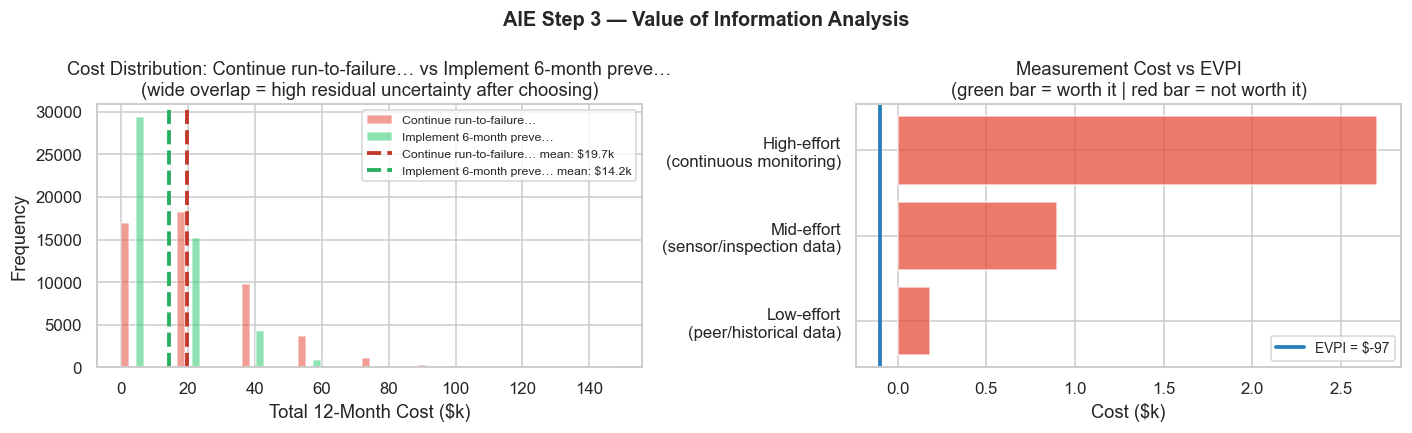

### How to Read This Section


| Quantity | Value | What it means |
|---|---|---|
| Best strategy (current data) | Implement 6-month preventive maintenance schedule | The lower expected-cost option given what we know now |
| E\[cost \| uncertainty\] | $14,191 | Expected cost if we commit to the best known strategy |
| E\[cost \| perfect info\] | $14,288 | Expected cost if we always knew the true λ and PM effectiveness |
| **EVPI** | **$-97** | **Maximum worth spending to reduce uncertainty in λ and PM effectiveness** |

**AIE Rule of Thumb**: only invest in more measurement if its cost < EVPI.  
Bars coloured green in the chart above are cost-justified; red bars are not.


In [27]:
Section5_Step3_Plot_VoI()


---
## Section 6 — Step 4: Calibrated Priors (Two Paths)

AIE requires **calibrated probability estimates** — not guesses, not overconfident point values.  
This section shows both paths for seeding priors:

### Path A — Expert Estimate → 90% Confidence Interval → Distribution
Engineer provides a 90% CI ("I'm 90% confident the MTBF is between 8 and 16 months").  
We fit a distribution to that interval.

### Path B — Sample Data → MLE Descriptive Fits + Conjugate Gamma Prior → Distribution
We have observed time-to-failure values. We fit Exponential/Weibull descriptively (MLE) for failure-mechanism insight, then derive a data-only Gamma prior on λ via the exponential-conjugate update from a flat prior (Gamma(n, Σt), prior mean = 1/mean(t)).

In [28]:
Section6_Step4_Expert_CI_Override()


In [29]:
Section6_Step4_Compute_Path_A()


PATH A — Expert Calibrated Prior:
  Source:               industry (no expert override applied)
  Expert MTBF 90% CI:   [9.0, 14.0] months
  Industry MTBF 90% CI: [9.0, 14.0] months
  Lambda 90% CI:        [0.0714, 0.1111] failures/month
  Fitted Gamma:         alpha=55.86, rate=618.29
  Prior mean lambda:    0.0904 → implied MTBF = 11.1 months


In [30]:
Section6_Step4_TTF_Data_Entry()


In [31]:
Section6_Step4_Compute_Path_B()


PATH B — Data-Fitted Prior:
  TTF source:           synthetic (10 draws from Exp(mean=11.5 mo), seed=42)
  Sample size:          10
  Sample mean TTF:      16.79 months

  -- Descriptive fits (failure-mechanism insight) --
  Exponential fit:  scale=16.79  | log-likelihood=-38.21
  Weibull fit:      shape k=1.12, scale=17.38 | log-likelihood=-38.13
  → Weibull provides better fit; Weibull shape k=1.12 → wear-out failures (increasing hazard — PM is beneficial)

  -- Data-derived Bayesian prior on lambda (for Section 7 inference) --
  Gamma(alpha=10.00, rate=167.95) via conjugate update from flat prior
  Prior mean lambda:    0.0595 → implied MTBF = 16.8 months


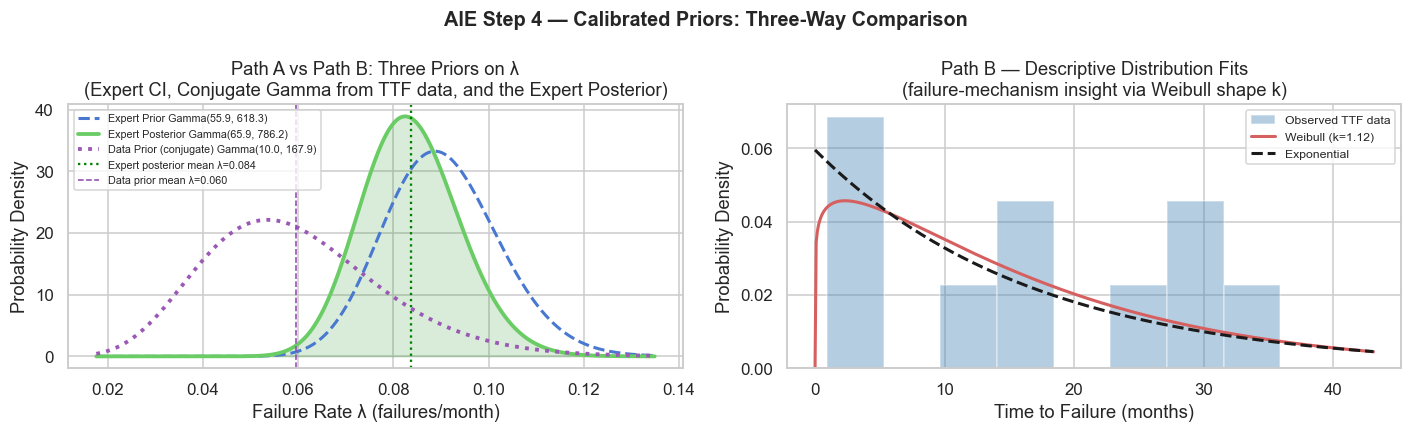

In [32]:
Section6_Step4_Plot_Prior_Comparison()


---
## Section 7 — Step 5: Bayesian Update (PyMC Model)

We now build the full probabilistic model in **PyMC**, which:
- Encodes the prior on failure rate
- Conditions on observed failure count (likelihood)
- Samples the posterior via MCMC (NUTS sampler)

This is equivalent to the analytical Gamma-Poisson conjugate result, but generalizable to any prior/likelihood combination.

$$\underbrace{P(\lambda \mid k, t)}_{\text{posterior}} \propto \underbrace{\text{Poisson}(k \mid \lambda t)}_{\text{likelihood}} \cdot \underbrace{\text{Gamma}(\lambda \mid \alpha, \beta)}_{\text{prior}}$$

In [33]:
Section7_Step5_Run_Hardcoded_Model()


── Hardcoded Model (Path A Prior) ───────────────────────────────────
  Prior       (Path A): Gamma(alpha=55.86, rate=618.29)
                        fitted to expert MTBF 90% CI [9.0, 14.0] months
                        prior mean λ = 0.0904 → implied MTBF = 11.1 mo
  New info    (likelihood): Path B TTF data (10 records, total exposure 167.9 mo)
                        Poisson(λ × 167.9 mo) conditioned on 10 observed failures
  Posterior:            updated Gamma on λ sampled via MCMC (NUTS)

Starting PyMC sampling...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lambda_rate]


Output()

[tuning] chain 1: 250/1000

[tuning] chain 1: 500/1000

...

[sampling] chain 1: 1000/2000

[sampling] chain 1: 1500/2000

[sampling] chain 1: 2000/2000

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 31 seconds.



Bayesian sampling complete — only lambda_rate sampled (NUTS, no CompoundStep).


### — Dynamic Model Builder & Four-Way Prior Sensitivity

This subsection demonstrates two key concepts running in parallel.

**1. Dynamic Model Builder**
Reads the validated JSON contract from the LLM parser and automatically constructs a PyMC Bayesian model — no hand-coding required.
This is the mechanism that makes the notebook reusable across different problem descriptions.

**2. Four-Way Prior Sensitivity Analysis (AIE Teaching Moment)**
The same observed data (3 failures in 24 months for the default scenario) is updated through **four** different prior beliefs:

| Model | Prior Source | What it encodes |
|---|---|---|
| Hardcoded (Section 7) | Expert 90% CI fitting | Engineer's calibrated belief from MTBF range |
| Dynamic (Increment B) | LLM-parsed JSON parameters | LLM's translated belief from the problem description (family + params) |
| Data-prior (Phase 2)  | Conjugate Gamma from TTFs (Path B) | What the observed time-to-failure data implies on its own |
| Elicited (Idea 1)     | LLM binned-quantile allocation over MTBF bins | SepState-style calibrated elicitation — LLM as synthetic calibrated expert reasoning about specific evidence in the problem text |

Comparing the four posteriors answers a core AIE question:

> **How sensitive is the decision recommendation to the choice of prior?**

- If the four posteriors are close → data dominates → the recommendation is robust regardless of prior.
- If they diverge substantially → the prior matters → stronger elicitation, reconciliation between SME and LLM, or more TTF data is warranted before deciding.

The Elicited path is the most information-rich prior: instead of the LLM picking a distribution family and repeating input parameters, it distributes probability mass across MTBF bins with per-bin justifications tied to specific evidence (wear-out signals, duty cycle, industry benchmarks, etc.). This tests whether the LLM adds real reasoning value beyond parroting the SME's stated MTBF range.

Sensitivity is reported as the **max-min spread of the four posterior means**, normalised by their average, so the panel scales sensibly across scenarios.


In [34]:
Section7_Step5_Run_Dynamic_Model()

Initializing NUTS using jitter+adapt_diag...


Dynamic builder inputs:
  source JSON:      bayesian_model_json
  prior node:       mtbf → Gamma(α=55.86, β=618.29) [from LLM Uniform MTBF(9,14) mo]
  likelihood data:  Path B TTF data (10 records, total exposure 167.9 mo)
  likelihood node:  failure_count → Poisson(mu=lambda_rate × 167.9)


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lambda_rate]


Output()

Sampling 4 chains for 800 tune and 1_500 draw iterations (3_200 + 6_000 draws total) took 28 seconds.


In [35]:
Section7_Step5_Run_Data_Prior_Model()

Initializing NUTS using jitter+adapt_diag...


Data-prior model inputs:
  source prior:     Path B (Gamma(alpha=10.00, beta=167.95) from TTFs)
  prior mean λ:     0.0595 → implied MTBF = 16.8 months
  likelihood data:  Path B TTF data (10 records, total exposure 167.9 mo)
  likelihood:       Poisson(mu=lambda_rate * 167.9)


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lambda_rate]


Output()

Sampling 4 chains for 800 tune and 1_500 draw iterations (3_200 + 6_000 draws total) took 28 seconds.


Data-prior Gamma-Poisson sampling complete.


In [36]:
Section7_Step5_Run_Elicited_Model()


Initializing NUTS using jitter+adapt_diag...


Elicited-prior model inputs:
  source prior:     LLM (gpt-4o-mini) via parse_problem_to_bins()
  bin edges (mo):   [3.00, 4.66, 7.23, 11.22, 17.43, 27.05, 42.00]
  bin probs:        [0.050, 0.100, 0.400, 0.300, 0.100, 0.050]
  fit Gamma:        Gamma(alpha=4.74, beta=46.69)
  prior mean λ:     0.1016 → implied MTBF = 9.8 months
  likelihood data:  Path B TTF data (10 records, total exposure 167.9 mo)
  likelihood:       Poisson(mu=lambda_rate * 167.9)


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lambda_rate]


Output()

Sampling 4 chains for 800 tune and 1_500 draw iterations (3_200 + 6_000 draws total) took 29 seconds.


Elicited-prior Gamma-Poisson sampling complete.


### Four-Way Prior Sensitivity Analysis Results

,Prior source,Posterior mean λ,Implied MTBF (mo),90% HDI low,90% HDI high
Model,,,,,
Hardcoded (Expert 90% CI),Path A - calibrated from MTBF CI,0.084,11.9,0.066,0.100
Dynamic (LLM family-JSON parse),"Gamma(α=55.86, β=618.29) [from LLM Uniform MTB...",0.084,11.9,0.067,0.100
Data-prior (Path B TTFs),"Path B - Gamma(10.0, 167.9) from TTFs",0.059,16.9,0.038,0.081
Elicited (LLM binned quantiles),LLM (gpt-4o-mini) via parse_problem_to_bins() ...,0.069,14.5,0.038,0.097


Posterior mean spread (max-min): 0.0250 failures/month (33.8%)
  Expert    prior implied MTBF:  11.9 months
  LLM fam.  prior implied MTBF:  11.9 months
  Data      prior implied MTBF:  16.9 months
  Elicited  prior implied MTBF:  14.5 months



**Prior Sensitivity: HIGH**

> The priors produce substantially different posteriors and likely different decision recommendations. Prior choice is the dominant driver of the result - the data alone is insufficient to resolve the uncertainty. AIE action: this is a high-VoI situation. Better elicitation, additional TTF observations, or a pilot study is strongly warranted before deciding.

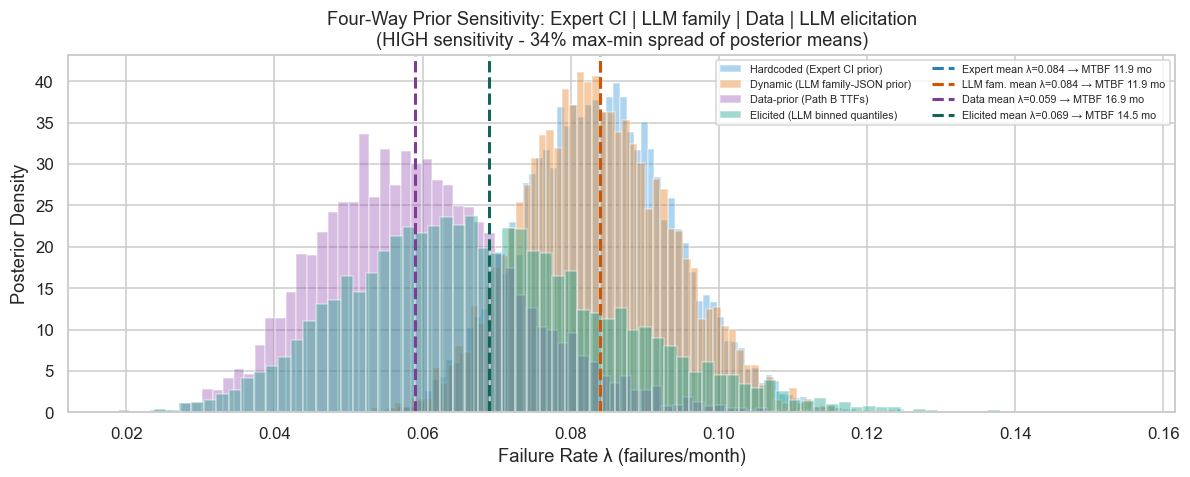

In [37]:
Section7_Step5_Compare_Four_Priors()


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
lambda_rate,0.084,0.0103,0.0652,0.1035,0.0002,0.0001,3214.6737,5115.4338,1.0005


  likelihood data:  Path B TTF data (10 records, total exposure 167.9 mo)

Analytical posterior mean λ: 0.0839 -> MTBF = 11.9 months
MCMC posterior mean λ:       0.0840 -> MTBF = 11.9 months
Difference:                  0.00018 (should be ~0 for conjugate model)


### How to Read The Hardcoded Posterior Table

- **mean** and **sd**: posterior center and spread for failure rate λ (failures/month).
- **hdi_3% / hdi_97%**: 94% highest-density interval; plausible range for λ after updating with observed failures.
- **ess_bulk / ess_tail**: effective sample size in center and tails; larger is better for stable estimates.
- **r_hat**: chain convergence diagnostic; values close to 1.00 indicate good mixing.
- **mcse_mean / mcse_sd**: Monte Carlo uncertainty from finite draws; should be small relative to sd.

Tutorial interpretation: this table validates the **Path A hardcoded Bayesian update** itself. Use the separate three-way prior-sensitivity cell to compare hardcoded, dynamic JSON, and data-prior posteriors for decision robustness.

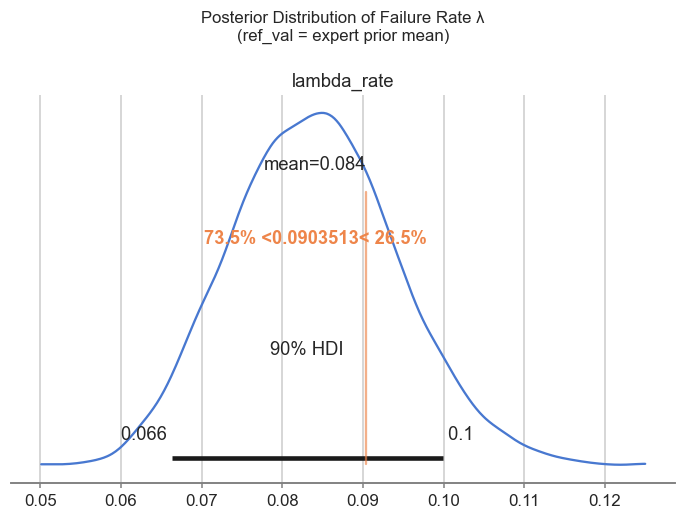

In [38]:
Section7_Step5_Posterior_Summary_Hardcoded()

Interpretation of NUTS/MCMC posterior summaries in this section follows Salvatier et al. (2016, DOI: [10.7717/peerj-cs.55](https://doi.org/10.7717/peerj-cs.55)); convergence interpretation for R-hat follows Vehtari et al. (2021, DOI: [10.1214/20-BA1221](https://doi.org/10.1214/20-BA1221)); metric definitions for `r_hat`, `ess_bulk`, `ess_tail`, and `mcse_*` follow ArviZ `summary` docs ([link](https://python.arviz.org/en/stable/api/generated/arviz.summary.html)).

---
## Section 8 — Step 5b: Chained Bayesian DAG Visualization

The JSON from Section 4 defines a **Directed Acyclic Graph (DAG)** — a chain of dependencies  
from raw measurements → derived quantities → cost outputs.

This visualization shows exactly **where each piece of information enters the model**.

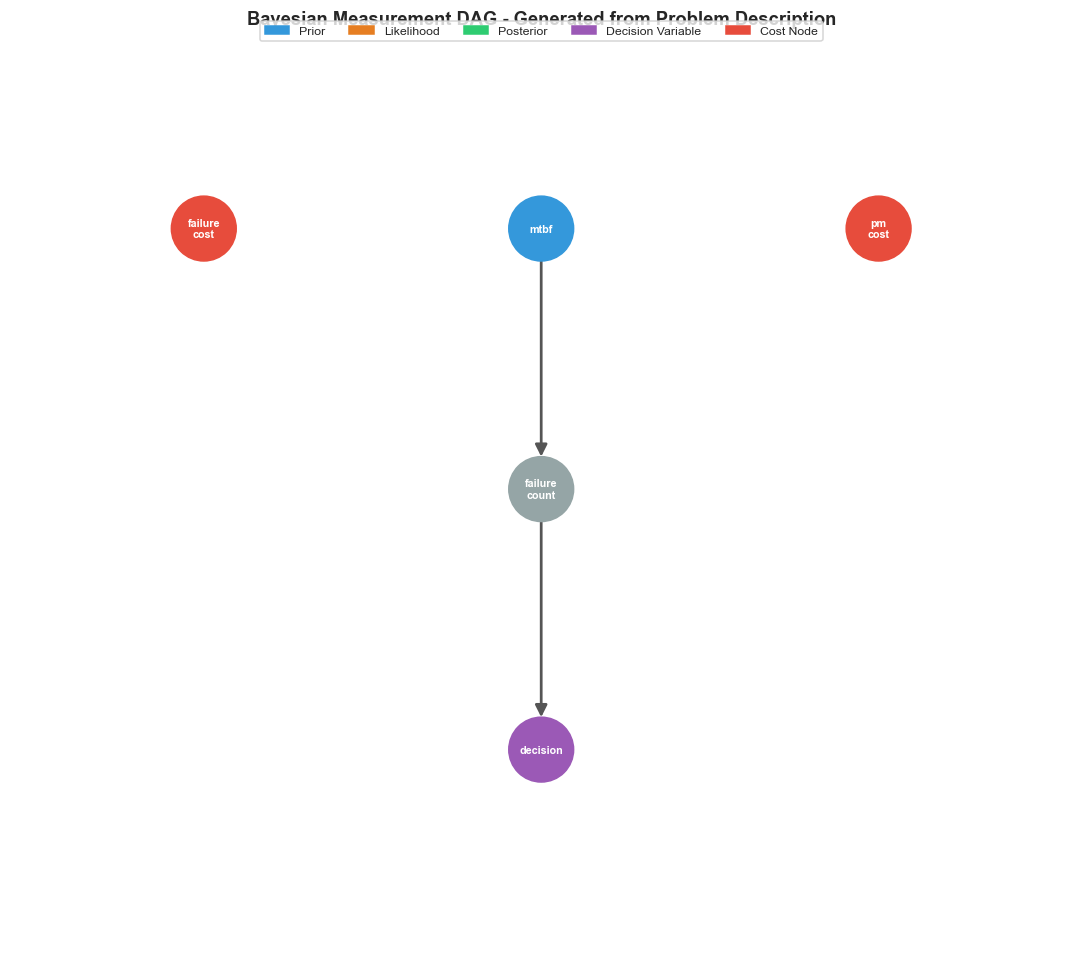

**Bayesian Update Chain:** `mtbf` -> `failure_count` -> `decision`

In [39]:
Section8_Step5b_Plot_Bayesian_DAG()

### Section 8 — Step 5c: Bayesian Update Subgraph

This compact plot isolates the strict Bayesian update path from the current model:
- prior + likelihood -> posterior

It complements Step 5b (measurement dependency DAG), which can include decision and cost flow beyond pure Bayesian updating.

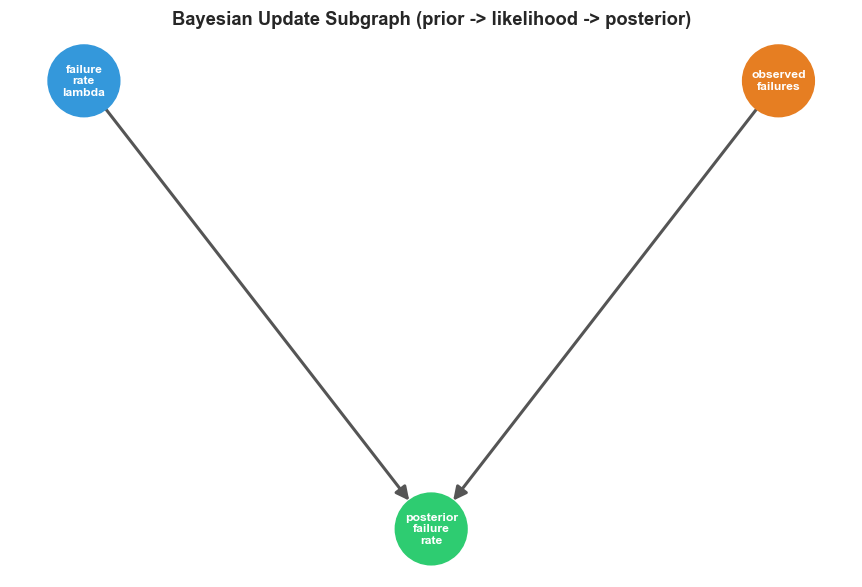

**Bayesian Update Path:** `failure_rate_lambda` + `observed_failures` -> `posterior_failure_rate`

> Warning: Parsed JSON did not provide a full Bayesian trio by role. Step 5c is showing the Section 7 fallback trio.

In [40]:
Section8_Step5c_Plot_Bayesian_Update_Subgraph()

---
## Section 9 — Step 7: Monte Carlo Simulation & Decision Recommendation

Propagate posterior uncertainty through the cost model to produce a **full cost distribution**  
for each strategy, and generate an **auditable decision recommendation**.

In [41]:
Section9_Step7_Compute_Monte_Carlo()

PM Effectiveness: mean η=50% | 90% CI [30%, 70%]


### Monte Carlo Cost Summary

,Mean Cost ($),Median ($),P10 ($),P90 ($),P(cheaper) %
Strategy,,,,,
Continue run-to-failure (reactive maintenance only),"$18,040","$18,000",$0,"$36,000",53.2%
Implement 6-month preventive maintenance schedule,"$13,339","$4,400","$4,400","$22,400",46.8%


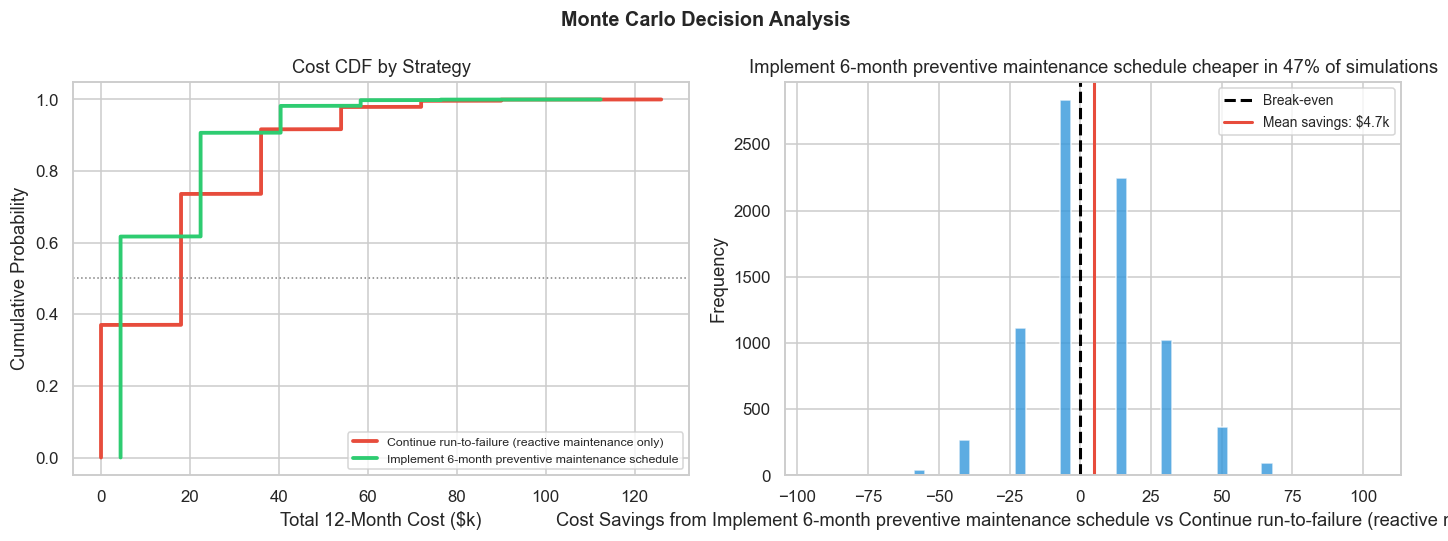

---
### Decision Recommendation

**Recommended Strategy**: **Implement 6-month preventive maintenance schedule**

- Implement 6-month preventive maintenance schedule is the lower-cost strategy in **47%** of simulated scenarios.
- Expected savings from Implement 6-month preventive maintenance schedule over 12 months: **$4,701**
- EVPI = **$-97** — additional investment in failure-rate or PM effectiveness characterization is not required.

*This recommendation is based on 8,000 posterior draws and 8,000 Monte Carlo simulations.*

In [42]:
Section9_Step7_Plot_Decision()

---
## Section 10 — Your Turn: Participant Exercise

Now it's your turn. **Write up your own reliability problem** in a short paragraph — asset type, failure history, costs, time horizon, and the decision options you're weighing — then drop it into the *Problem description* textarea in Section 3. Click **Extract Fields From Description (LLM)**, review the source tags, adjust any red-tagged fields (especially the PM effectiveness 90% CI), and click **Apply To SCENARIO_CONFIG**. Re-run the notebook from Section 3 onward to see your problem flow through the full Bayesian pipeline.

**Prompts to spark ideas:**
1. A conveyor belt system with 5 failures over 18 months — decide predictive vs. scheduled maintenance.
2. A safety valve with no failures in 36 months — is the current inspection interval adequate?
3. A fleet of 12 motors with mixed failure history — prioritize which unit to maintain first.

**[⤴ Jump to Section 3 — Configure Problem Inputs](#section-3-config)**


---
## How This Notebook Applies the Referenced Research

The table below maps each cited paper's key research feature to the specific place in this notebook where it drives either an **LLM prompt / parsing step** or a **Bayesian computation**. Section numbers refer to the tutorial sections in this notebook (§1–§10).

| # | Reference | Feature applied | Where in notebook |
|---|-----------|-----------------|-------------------|
| 1 | **Huang et al. (2025)** — LLM-BI, part (a): **NL → structured Bayesian model JSON** | LLM acts as an "expert statistical consultant" that maps a natural-language problem into a structured model spec (priors + likelihood family + node roles). | §3 `parse_description_to_scenario_fields` (extract scenario fields). §4 `parse_problem_to_json` (full model JSON). §7 `Section7_Step5_Run_Dynamic_Model` — the LLM JSON is turned into a live PyMC model via `DYNAMIC_PRIOR_MAP`, family-name normalization, and parameter aliasing. |
| 2 | **Huang et al. (2025)** — LLM-BI, part (b): **Schema-constrained output + validate/repair loop** | Schema constrains what the LLM may emit; a validator rejects invalid JSON and a **field-level repair** step patches near-miss fields instead of discarding otherwise-usable LLM output. | §1 `CANONICAL_MODEL_SCHEMA`, `validate_model_json`, `repair_model_json`. §4 `Section4_Step2_Validate_Parsed_Schema()`; offline fallback path when repair cannot save the JSON. |
| 3 | **Lorenz & Fritz (2026)** — Scalable Delphi | LLM as a **calibrated Delphi panelist**: structured elicitation, explicit reasoning per estimate, anti-anchoring / anti-family-echo prompting. | Reliability-engineer system prompts (`SYSTEM_PROMPT`, `SYSTEM_PROMPT_BINS`, `SYSTEM_PROMPT_SCENARIO_EXTRACT`) instruct the LLM to reason as a calibrated engineer and to justify each estimate. §4 `Section4_Diagnose_Bin_Elicitation()` uses the wear-out scenario to show the LLM *reasoning* about the problem rather than echoing a flat prior. |
| 4 | **Salvatier, Wiecki, Fonnesbeck (2016)** — PyMC | Probabilistic programming (`with pm.Model()`), distribution primitives, NUTS/HMC sampling, ArviZ `InferenceData` for posterior summaries and diagnostics. | §7 all four PyMC models — `reliability_model` (hardcoded expert CI), `reliability_model_data` (data-derived), `reliability_model_dynamic` (LLM-parsed), `reliability_model_elicited` (bin-elicited); `pm.Gamma`, `pm.Exponential`, `pm.Poisson`, `pm.sample`; ArviZ `az.plot_trace`, `az.summary`, R-hat / ESS. §9 posterior samples propagate to Monte Carlo cost distributions. |
| 5 | **Nafar et al.** — Extracting probabilistic knowledge from LLMs | Elicit calibrated probability judgments by asking the LLM to **allocate probability mass across ordered bins/intervals with justifications**, rather than emit distribution parameters directly — mitigates "family echo" hallucination. | §1 `SYSTEM_PROMPT_BINS`, `compute_default_mtbf_bin_edges`, `parse_problem_to_bins`, `fit_gamma_to_bin_probabilities` (KL-min Gamma fit). Schema: `elicitation_method: bin_probabilities` is a first-class node type. §4 diagnostic. §6/§7 bin-elicited prior is the **fourth branch** of the prior-sensitivity comparison. |
| 6 | **Zhang et al.** — LLM-based BN structure discovery | LLM discovers the Bayesian-network **structure** (nodes, roles, edges) from the problem description, not just parameter values. | §4 LLM-emitted `measurement_nodes[]` with role tags (`prior` / `likelihood` / `decision` / `cost`) and `bayesian_update_chain[]` describing edges. §8 DAG visualization renders the LLM-discovered structure with role coloring (`DAG_ROLE_COLORS`). |
| 7 | **O'Connor, Modarres & Mosleh (2016)** — Probability Distributions Used in Reliability Engineering | Bayes' law (§1.1.5), likelihood functions for reliability data (§1.1.6), Gamma–Exponential / Gamma–Poisson conjugacy (§1.4.6), Weibull for wear-out, reliability distribution catalog. | §2 Background: Bayes' rule and likelihood definitions in the O'Connor form. §6 Path A: `fit_gamma_from_mtbf_ci` — Gamma prior fit to the expert's 90% CI on MTBF (conjugate to Exponential/Poisson). §6 Path B: TTF observations → Gamma(n, T) posterior via exponential conjugacy. §7 Exponential likelihood on TTFs, Poisson likelihood on counts; Weibull-vs-Exponential likelihood comparison. §4 offline fallback `build_default_offline_json` (Gamma-Poisson skeleton). |

### Cross-cutting notes

- **Huang and Nafar together drive the LLM half of the notebook.** Huang gives the *"LLM emits schema-valid model JSON"* backbone (§§3, 4, 7 dynamic path). Nafar gives the *alternative elicitation path* where the LLM allocates probability mass across MTBF bins — enabling the four-way prior-sensitivity comparison in §7.
- **Salvatier and O'Connor together drive the Bayesian half.** Salvatier is the *how* (PyMC mechanics); O'Connor is the *why* (which distribution / conjugate pair for reliability data and how to write the likelihood).
- **Zhang and Lorenz & Fritz are prompt-design references.** Zhang motivates asking the LLM for *structure* (nodes + edges) alongside parameters. Lorenz & Fritz motivates the *calibrated-panelist* style prompting with explicit reasoning and anti-anchoring cues.

---


---

## Summary and Conclusion (Presentation Draft)

### Summary Slide Bullets

- Applied Hubbard's AIE to a reliability decision to reduce uncertainty in a structured, measurable way.
- Used an LLM to decompose a plain-language problem into measurement nodes and a Bayesian update chain.
- Identified missing measures of interest and generated plausible value ranges for key variables.
- Suggested candidate probability distribution families for reliability measures and likelihoods.
- Built a framework to estimate Value of Information (VoI) for deciding whether additional study is worth the cost.
- Updated expert beliefs with observed time-to-failure (TTF) data to produce posterior beliefs for decision revision.
- Compared four posterior paths (including elicited and data-informed priors) and visualized their differences.
- Used posterior comparisons to revise expert MTBF beliefs (Path A) toward the closest evidence-aligned range.
- Visualized the decision DAG/Bayesian chain to inspect model structure and practical interpretability.
- Ran Monte Carlo simulation on integrated measurement inputs to support the final decision recommendation.
- Result in this case: >50% probability of cost savings, with about $5,000 expected savings by running to failure instead of performing preventive maintenance.

### Conclusion Slide Bullets

- LLM-assisted Bayesian/AIE workflows can accelerate model setup while preserving decision rigor.
- Expert judgment is still central: the workflow improves it by making assumptions explicit and testable.
- New data should update beliefs; posterior comparison is the bridge from opinion to evidence-based action.
- VoI framing helps avoid over-collecting data when uncertainty reduction does not justify study cost.
- Final recommendations are probabilistic and economically grounded, not deterministic or anecdotal.
- This notebook is reusable: return to Section 3, enter a new problem description, and generate a fresh decision model.

## Next Steps and Future Work

- Significant improvement in DAG plotting and interactive graph exploration could enable better modeling of the problem space, nodes, and measures, and is a strong candidate for a future methods paper.
- Building on Lorenz and Fritz (2026), LLMs could generate their own refined, calibrated expert estimates for high-impact measures and then benchmark those estimates against human expert priors.
- With AI assistance, the workbook can be adapted to entirely new measurement problems in reliability and adjacent domains, stress-testing how well the workflow repurposes across contexts.
- Future versions can explore deeper problem decomposition into longer Bayesian chains with nested dependencies and context-aware selection of additional distribution families.
- The front half of the notebook could be modularized by moving reusable functions, workflow code, and data structures into reference libraries, making the notebook cleaner as both a tutorial and engineering tool.
- Add an explicit model validation track: posterior predictive checks, calibration plots, and out-of-sample scoring to compare competing models beyond visual posterior overlap.
- Add decision sensitivity and threshold analysis to identify which assumptions flip the recommended action and where additional measurement has the highest marginal value.
- Build a semi-automated uncertainty governance layer (assumption registry, provenance logging, and change tracking) so model updates remain auditable for engineering reviews and publication artifacts.

---
## References

1. **Hubbard, D.** (2014). *How to Measure Anything: Finding the Value of Intangibles in Business* (3rd ed.). Wiley. ISBN 978-1-118-53927-9.
2. **Hubbard, D.** (2025). *How to Measure Anything in AI: Quantitative Techniques for Decision-Making*. LinkedIn Learning.
3. **Huang, Y.** (2025). *LLM-BI: Towards Fully Automated Bayesian Inference with Large Language Models*. arXiv:2508.08300. DOI: [10.48550/arXiv.2508.08300](https://doi.org/10.48550/arXiv.2508.08300)
4. **Lorenz, T., & Fritz, M.** (2026). *Scalable Delphi: Large Language Models for Structured Risk Estimation*. arXiv:2602.08889. DOI: [10.48550/arXiv.2602.08889](https://doi.org/10.48550/arXiv.2602.08889)
5. **Salvatier, J., Wiecki, T. V., & Fonnesbeck, C.** (2016). Probabilistic programming in Python using PyMC3. *PeerJ Computer Science*, 2:e55. DOI: [10.7717/peerj-cs.55](https://doi.org/10.7717/peerj-cs.55)
6. **Nafar, A., Venable, K. B., Cui, Z., & Kordjamshidi, P.** (2025). *Extracting Probabilistic Knowledge from Large Language Models for Bayesian Network Parameterization*. arXiv:2505.15918. DOI: [10.48550/arXiv.2505.15918](https://doi.org/10.48550/arXiv.2505.15918)
7. **Zhang, Y., Zhang, Y., Kordjamshidi, P., & Cui, Z.** (2025). *Bayesian Network Structure Discovery Using Large Language Models*. arXiv:2511.00574 (accepted to TMLR). DOI: [10.48550/arXiv.2511.00574](https://doi.org/10.48550/arXiv.2511.00574)
8. **O'Connor, A. N., Modarres, M., & Mosleh, A.** (2016). *Probability Distributions Used in Reliability Engineering*. Center for Risk and Reliability, University of Maryland, College Park, MD. ISBN 978-0-9966468-1-9. [PDF on GitHub](https://github.com/KirtisChristensen/AIE---Bayesian-Template-Tutorial/blob/main/References/Free%20Ebook%20Probability%20Distributions%20Used%20in%20Reliability%20Engineering.pdf) (no DOI — self-published)
9. **Tutorial companion — Probability Distributions Reference Extract** (curated from O'Connor et al., 2016). Notebook-oriented walkthrough of Bayes' law, likelihood functions, conjugate priors (Gamma-Poisson, Beta-Binomial, Normal-Normal, Dirichlet-Multinomial), plus a full 22-distribution catalog with PyMC snippets, a distribution decision guide, and reusable notebook blueprints (HPP failure counting, pass/fail demonstration, wear-out TTF, log-normal fatigue, multi-mode attribution, on-demand safety systems). [Reference markdown on GitHub](https://github.com/KirtisChristensen/AIE---Bayesian-Template-Tutorial/blob/main/References/prob_distributions_reliability_reference.md) (no DOI — companion asset)
10. **Vehtari, A., et al.** (2021). Rank-normalization, folding, and localization: An improved R-hat for assessing convergence of MCMC. *Bayesian Analysis*. DOI: [10.1214/20-BA1221](https://doi.org/10.1214/20-BA1221)
11. **ArviZ documentation**. Summary metric definitions (`arviz.summary`). [API reference](https://python.arviz.org/en/stable/api/generated/arviz.summary.html)

> DOI links (entries 3–7 and 10) resolve at doi.org and are canonical, publisher-stable references. Entries 1–2 and 8–9 have no assigned DOI (books, course, or self-published companion); GitHub links are provided where a hosted copy exists.

---
*Notebook version 1.0 — RAMS 2027 Tutorial Submission*  
*Author: Kirtis Christensen | Bayesian Mentor: Grok (xAI)*  
*Generated: April 30, 2026*
